In [ ]:
import pandas as pd

df = pd.read_csv('/content/0.  Research Data.csv')
display(df.head())

,date,gdp_per_capita,inflation_rate,brent_crude_price,usd_lkr,rub_lkr,inr_lkr,gbp_lkr,eur_lkr,cny_lkr,...,is_holiday,holiday_name,event_name,is_tourist_event,location,temperature,precipitation,humidity,wind_speed,arrivals
0,1/1/2010,2808.367792,6.217649,76.602381,114.400,NaN,2.472,184.253,NaN,NaN,...,False,NaN,NaN,False,Colombo,26.0,0.0,73.625000,12.2,1141
1,1/2/2010,2808.367792,6.217649,76.602381,NaN,NaN,NaN,NaN,NaN,NaN,...,False,NaN,NaN,False,Colombo,26.3,0.1,74.916667,13.0,1180
2,1/3/2010,2808.367792,6.217649,76.602381,NaN,NaN,NaN,NaN,NaN,NaN,...,False,NaN,NaN,False,Colombo,26.0,0.6,79.625000,12.3,1184
3,1/4/2010,2808.367792,6.217649,76.602381,114.450,3.799,2.474,182.892,163.889,16.75,...,False,NaN,NaN,False,Colombo,25.6,0.0,75.625000,17.0,1328
4,1/5/2010,2808.367792,6.217649,76.602381,114.325,3.775,2.502,183.183,164.951,16.76,...,False,NaN,NaN,False,Colombo,24.6,0.0,70.958333,18.7,1688


# Preprocessing Steps Report

This document details the comprehensive preprocessing pipeline applied to the raw research data to prepare it for further analysis and modeling. The steps cover data loading, cleaning, feature engineering, and feature selection.

## 1. Initial Data Loading and Overview

*   **Data Source**: The dataset `0. Research Data.csv` was loaded into a pandas DataFrame named `df`.
*   **Initial Inspection**: The first few rows of the DataFrame were displayed to understand its structure and content.
*   **Metadata Export**: A markdown description of the DataFrame's summary statistics (`df.describe().to_markdown()`) was generated and saved to `/content/drive/MyDrive/Research/Model Agnostic Preprocessing/df_description.md`.

## 2. Basic Data Preparation

*   **Date Column Conversion**: The `date` column was converted from a string format (`%m/%d/%Y`) to a datetime object to enable temporal operations.
*   **Data Sorting**: The DataFrame was sorted by the `date` column to ensure temporal order, which is crucial for time-series analysis.
*   **Redundant Column Removal**: The `location` column was dropped as it was deemed unnecessary for the analysis.

## 3. Handling Missing Values

### 3.1. Exchange Rates

*   **Identification**: Exchange rate columns (`usd_lkr`, `rub_lkr`, `inr_lkr`, `gbp_lkr`, `eur_lkr`, `cny_lkr`) were identified.
*   **Initial Analysis**: The number and percentage of missing values for each exchange rate column were printed, showing significant missingness (approx. 28-29%).
*   **Imputation Strategy**: A two-step imputation method was applied:
    1.  **Forward-fill (`ffill`)**: Propagated the last valid observation forward to fill initial gaps, reflecting a continuation of economic conditions.
    2.  **Linear Interpolation**: Used linear interpolation with `limit_direction='both'` to fill any remaining gaps, ensuring temporal continuity.
*   **Verification**: Post-imputation missing value counts were checked, confirming zero missing values for all exchange rate columns.
*   **Save Point**: The DataFrame with imputed exchange rates was saved as `/content/drive/MyDrive/Research/Model Agnostic Preprocessing/1.1.ExchangeRates_Imputed.csv`.

### 3.2. Weather Data

*   **Identification**: Weather-related columns (`temperature`, `precipitation`, `humidity`, `wind_speed`) were identified.
*   **Initial Analysis**: Missing value counts were checked, revealing a small number of missing values (12 missing, 0.21%) for each weather column.
*   **Imputation Strategy**: Linear interpolation with `limit_direction='both'` was applied to fill these small gaps, assuming a smooth transition in weather conditions.
*   **Verification**: Post-imputation missing value counts were checked, confirming zero missing values.
*   **Feature Creation**: A binary feature `is_rainy_day` was created based on `precipitation` values (precipitation > 0.5).
*   **Save Point**: The DataFrame with imputed weather data was saved as `/content/drive/MyDrive/Research/Model Agnostic Preprocessing/1.2 Weather_Imputed.csv`.

## 4. Feature Engineering

### 4.1. COVID-19 Impact Factor

*   **Function Definition**: A custom function `compute_covid_impact` was defined to quantify the impact of COVID-19 on tourist arrivals in Sri Lanka. This function models three phases: emerging (linear ramp 0→1), affected (full impact 1), and recovery (linear taper 1→0), with a zero impact outside these periods.
*   **Application**: The function was applied to the `date` column to create the `covid_impact_factor` feature.
*   **Verification**: Value counts and boundary checks were performed to ensure the `covid_impact_factor` was computed correctly at critical dates.

### 4.2. Economic Crisis Impact Factor

*   **Function Definition**: A custom function `compute_economic_impact` was defined to model the impact of the Sri Lankan economic crisis, following a similar three-phase approach (emerging, affected, recovery).
*   **Application**: The function was applied to the `date` column to create the `economic_impact_factor` feature, which was subsequently renamed to `crisis_impact_factor`.
*   **Verification**: Boundary checks were performed to ensure the feature values were accurate at phase transitions.
*   **Save Point**: The DataFrame with COVID-19 and crisis impact factors was saved as `/content/drive/MyDrive/Research/Model Agnostic Preprocessing/2.2 covid-crisis featured.csv`.

### 4.3. Categorical Encoding

#### 4.3.1. Event Name

*   **Missing Value Handling**: Missing values in `event_name` were filled with 'NoEvent'.
*   **Bayesian-smoothed Target Encoding**: To convert categorical `event_name` into a numerical representation while reducing overfitting, Bayesian-smoothed target encoding was applied using 5-fold cross-validation. The global mean of `arrivals` and a smoothing parameter (alpha = 10) were used.
*   **Mapping Table**: A mapping table (`event_encoding_mapping.csv`) was generated and saved, showing the original event names and their corresponding encoded values.
*   **Column Dropped**: The original `event_name` column was dropped after encoding.

#### 4.3.2. Holidays

*   **Missing Value Handling**: Missing values in `holiday_name` were filled with 'NoHoliday'.
*   **Rare Category Grouping**: Holidays with fewer than 5 occurrences were grouped into an 'OtherHoliday' category to handle sparsity.
*   **Temporal Features**: Several holiday-related temporal features were created:
    *   `is_holiday_actual`: A boolean flag for actual holidays.
    *   `days_to_next_holiday`: Number of days until the next holiday.
    *   `days_since_last_holiday`: Number of days since the last holiday.
    *   `in_holiday_window`: A binary flag indicating if the date falls within a ±3 day window of a holiday.
*   **Bayesian-smoothed Target Encoding**: Bayesian-smoothed target encoding with 5-fold cross-validation was applied to the grouped `holiday_name_grouped` column to create `holiday_encoded`.
*   **Mapping Table**: A mapping table (`holiday_encoding_mapping.csv`) for the grouped holidays was generated and saved.
*   **Columns Dropped**: The original `holiday_name` and the temporary `holiday_name_grouped` columns were dropped.
*   **Type Conversion**: The `is_holiday` column was converted to integer type.
*   **Save Point**: The DataFrame with encoded event and holiday features was saved as `/content/drive/MyDrive/Research/Model Agnostic Preprocessing/3.4.event_holiday_encoded.csv`.

## 5. Handling Outliers

*   **Detection Methods**: Outliers in the `arrivals` target variable were detected using two methods:
    1.  **Z-score**: Points with `|z-score| > 3` were flagged.
    2.  **IQR Method**: Points falling outside `Q1 - 1.5*IQR` and `Q3 + 1.5*IQR` were flagged.
*   **Combined Flag**: A `is_outlier` column was created, marking an observation as an outlier if flagged by either method. A total of 7 outliers (0.12%) were detected.
*   **Visualization**: Box plots and scatter plots of `arrivals` over time were generated to visualize the outliers.
*   **Treatment Strategy (Retention with Robust Scaling)**:
    *   Outliers were *retained* in the dataset, allowing models to learn from extreme events.
    *   A `RobustScaler` was applied to `arrivals` to create `arrivals_robust_scaled`, which is less sensitive to outliers, providing a scaled version for models that might benefit from it.
    *   A binary `outlier_flag` (0 or 1) was added to explicitly inform models about the presence of an outlier.
*   **Cleanup**: Temporary outlier detection columns (`z_score`, `outlier_z`, `outlier_iqr`, `is_outlier`) were removed.
*   **Save Point**: The DataFrame after outlier processing was saved as `/content/drive/MyDrive/Research/Model Agnostic Preprocessing/3.Outliers_Processed.csv`.

## 6. Feature Selection (Multi-Method Framework)

A comprehensive multi-method feature selection framework was employed to identify the most influential predictors for tourist arrivals:

### 6.1. Statistical Methods

*   **Correlation Analysis**: Both Pearson (linear) and Spearman (monotonic non-linear) correlations between features and `arrivals` were calculated and visualized. This identified `gdp_per_capita`, `covid_impact_factor`, and `web_search` as top correlated features.
*   **Mutual Information Analysis**: This method measured non-linear relationships between features and `arrivals`. `brent_crude_price`, `youtube_search`, and `usd_lkr` showed high mutual information scores, indicating strong (potentially non-linear) dependencies.

### 6.2. Model-Based Methods

*   **Lasso Regression**: A Lasso model was trained with optimal alpha determined by time-series cross-validation. Lasso penalizes less important features, shrinking their coefficients to zero. `gdp_per_capita`, `covid_impact_factor`, and `brent_crude_price` were among the features selected with non-zero coefficients.
*   **Random Forest Importance**: A Random Forest Regressor was trained, and both built-in (Gini) and permutation importances were calculated. `gdp_per_capita`, `inflation_rate`, and `covid_impact_factor` consistently ranked high.

### 6.3. Model-Agnostic Methods

*   **Permutation Importance**: Permutation importance was calculated using a Random Forest model as a base. This method directly measures the drop in model performance when a feature's values are shuffled. `gdp_per_capita`, `inflation_rate`, and `covid_impact_factor` showed the highest permutation importance.
*   **SHAP Values**: SHAP (SHapley Additive exPlanations) values were computed using a Random Forest model. This game-theoretic approach provides a unified measure of feature importance and offers insights into individual prediction contributions and feature interactions. `gdp_per_capita`, `brent_crude_price`, and `web_search` were identified as globally important.

### 6.4. Time-Series Methods

*   **Granger Causality**: This test was performed to determine if past values of a feature help predict future values of `arrivals` (i.e., lead-lag relationships). Stationarity checks were performed, and first differencing was applied where necessary. `holiday_encoded`, `gdp_per_capita`, and `web_search` were found to Granger-cause `arrivals` at various lags.

### 6.5. Consensus Integration and Final Ranking

*   **Consensus Integration**: The importance scores from all seven methods were combined using a weighted average approach. Weights were assigned based on the methodological strengths (e.g., higher weights for SHAP, Permutation Importance).
*   **Consistency Metrics**: Consistency scores were calculated to assess how much the methods agreed on the importance of each feature.
*   **Tier Classification**: Features were classified into tiers (e.g., 'Core', 'Strong', 'Moderate', 'Supplementary') based on their consensus score and consistency.
*   **Implementation Guide**: Practical recommendations for selecting feature sets (e.g., minimal, balanced, comprehensive models) and model-building suggestions were generated.
*   **Final Output**: A final ranked list of features, along with their consensus scores, consistency, and method agreement, was saved to `sri_lanka_tourism_feature_ranking.csv` and a concise `top_20_tourism_features.csv`.

## 7. Final Optimized Dataset Creation

*   **Feature Selection**: Based on the comprehensive feature selection framework, a list of optimal features was chosen.
*   **Column Selection**: The DataFrame `df` was filtered to include only these optimal features along with essential columns like `date`, `arrivals`, and `outlier_flag`.
*   **Column Reordering**: The columns of the new DataFrame `df_optimized` were reordered to have `date` first, `arrivals` last, and other features sorted alphabetically in between.
*   **Final Save**: The fully preprocessed and feature-selected dataset, `df_optimized`, was saved as `/content/Preprocessed Dataset.csv`.

In [ ]:
import os

# Get the markdown of the dataframe description
markdown_output = df.describe().to_markdown()

# Define the directory path to save the markdown file
save_directory = '/content/drive/MyDrive/Research/Model Agnostic Preprocessing'

# Create the directory if it doesn't exist
if not os.path.exists(save_directory):
    os.makedirs(save_directory)
    print(f"Created directory: {save_directory}")

# Define the file path to save the markdown
markdown_file_path = os.path.join(save_directory, 'df_description.md')

# Write the markdown output to the file
with open(markdown_file_path, 'w') as f:
    f.write(markdown_output)

print(f"\nDataFrame description markdown saved to: {markdown_file_path}")

Created directory: /content/drive/MyDrive/Research/Model Agnostic Preprocessing

DataFrame description markdown saved to: /content/drive/MyDrive/Research/Model Agnostic Preprocessing/df_description.md


# Prepare for Data Preprocessing

In [ ]:
# Convert date column to datetime for proper temporal operations
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')

In [ ]:
# Sort by date to ensure temporal order
df = df.sort_values('date').reset_index(drop=True)

In [ ]:
df = df.drop('location', axis=1)

# Handling Missing Values

## Exchange Rates

In [ ]:
# Define exchange rate columns
exchange_rate_columns = ['usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr']


In [ ]:
# Print initial missing value statistics
print("="*80)
print("INITIAL MISSING VALUE ANALYSIS")
print("="*80)
for col in exchange_rate_columns:
    missing_count = df[col].isna().sum()
    missing_percentage = (missing_count / len(df)) * 100
    print(f"{col}: {missing_count} missing ({missing_percentage:.2f}%)")

INITIAL MISSING VALUE ANALYSIS
usd_lkr: 1648 missing (28.71%)
rub_lkr: 1649 missing (28.73%)
inr_lkr: 1648 missing (28.71%)
gbp_lkr: 1648 missing (28.71%)
eur_lkr: 1649 missing (28.73%)
cny_lkr: 1649 missing (28.73%)


In [ ]:
# Apply forward-fill followed by linear interpolation
# Forward-fill propagates last valid observation forward
# Linear interpolation handles remaining gaps with temporal continuity
for col in exchange_rate_columns:
    # Step 1: Forward-fill to propagate recent economic conditions
    df[col] = df[col].fillna(method='ffill')

    # Step 2: Linear interpolation for any remaining gaps at the beginning
    df[col] = df[col].interpolate(method='linear', limit_direction='both')


/tmp/ipykernel_4116/3816152601.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='ffill')


In [ ]:
# Verify imputation results
print("\n" + "="*80)
print("POST-IMPUTATION MISSING VALUE CHECK")
print("="*80)
for col in exchange_rate_columns:
    missing_count = df[col].isna().sum()
    print(f"{col}: {missing_count} missing values remaining")


POST-IMPUTATION MISSING VALUE CHECK
usd_lkr: 0 missing values remaining
rub_lkr: 0 missing values remaining
inr_lkr: 0 missing values remaining
gbp_lkr: 0 missing values remaining
eur_lkr: 0 missing values remaining
cny_lkr: 0 missing values remaining


In [ ]:
# Display sample of imputed data
print("\n" + "="*80)
print("SAMPLE OF IMPUTED EXCHANGE RATE DATA (First 10 rows)")
print("="*80)
print(df[['date'] + exchange_rate_columns].head(10))


SAMPLE OF IMPUTED EXCHANGE RATE DATA (First 10 rows)
        date  usd_lkr  rub_lkr  inr_lkr  gbp_lkr  eur_lkr  cny_lkr
0 2010-01-01  114.400    3.799    2.472  184.253  163.889    16.75
1 2010-01-02  114.400    3.799    2.472  184.253  163.889    16.75
2 2010-01-03  114.400    3.799    2.472  184.253  163.889    16.75
3 2010-01-04  114.450    3.799    2.474  182.892  163.889    16.75
4 2010-01-05  114.325    3.775    2.502  183.183  164.951    16.76
5 2010-01-06  114.325    3.797    2.501  182.159  164.268    16.74
6 2010-01-07  114.310    3.799    2.516  183.366  164.788    16.75
7 2010-01-08  114.400    3.799    2.527  184.138  163.647    16.75
8 2010-01-09  114.400    3.799    2.527  184.138  163.647    16.75
9 2010-01-10  114.400    3.799    2.527  184.138  163.647    16.75


In [ ]:
# Summary statistics for validation
print("\n" + "="*80)
print("EXCHANGE RATE SUMMARY STATISTICS (POST-IMPUTATION)")
print("="*80)
print(df[exchange_rate_columns].describe())


EXCHANGE RATE SUMMARY STATISTICS (POST-IMPUTATION)
           usd_lkr      rub_lkr      inr_lkr      gbp_lkr      eur_lkr  \
count  5740.000000  5740.000000  5740.000000  5740.000000  5740.000000   
mean    187.013731     3.269920     2.703220   254.718708   215.878873   
std      76.966642     0.888631     0.674654    84.060355    73.790721   
min     109.310000     1.416000     1.936000   162.702000   135.474000   
25%     130.747500     2.604750     2.239000   199.317000   162.153750   
50%     153.595000     3.195000     2.454000   215.915000   181.800500   
75%     201.250000     3.813000     2.698000   275.556000   234.921250   
max     370.000000     6.836000     4.836000   457.991000   402.253000   

           cny_lkr  
count  5740.000000  
mean     27.757901  
std      10.304094  
min      16.230000  
25%      21.100000  
50%      23.220000  
75%      31.225000  
max      55.590000  


In [ ]:
import os

# Define the directory path
save_directory = '/content/drive/MyDrive/Research/Model Agnostic Preprocessing'

# Create the directory if it doesn't exist
if not os.path.exists(save_directory):
    os.makedirs(save_directory)
    print(f"Created directory: {save_directory}")

# Save the preprocessed dataset
df.to_csv(os.path.join(save_directory, '1.1.ExchangeRates_Imputed.csv'), index=False)
print("\n" + "="*80)
print(f"Preprocessed dataset saved as: {os.path.join(save_directory, '1.1.ExchangeRates_Imputed.csv')}")
print("="*80)


Preprocessed dataset saved as: /content/drive/MyDrive/Research/Model Agnostic Preprocessing/1.1.ExchangeRates_Imputed.csv


## Weather Data

In [ ]:
# Define weather columns
weather_columns = ['temperature', 'precipitation', 'humidity', 'wind_speed']

In [ ]:
# Print initial missing value statistics
print("="*80)
print("INITIAL MISSING VALUE ANALYSIS (Weather Data)")
print("="*80)
for col in weather_columns:
    missing_count = df[col].isna().sum()
    missing_percentage = (missing_count / len(df)) * 100
    print(f"{col}: {missing_count} missing ({missing_percentage:.2f}%)")


INITIAL MISSING VALUE ANALYSIS (Weather Data)
temperature: 12 missing (0.21%)
precipitation: 12 missing (0.21%)
humidity: 12 missing (0.21%)
wind_speed: 12 missing (0.21%)


In [ ]:
# Apply linear interpolation for small missing gaps
for col in weather_columns:
    df[col] = df[col].interpolate(method='linear', limit_direction='both')

In [ ]:
# Verify imputation results
print("\n" + "="*80)
print("POST-IMPUTATION MISSING VALUE CHECK (Weather Data)")
print("="*80)
for col in weather_columns:
    missing_count = df[col].isna().sum()
    print(f"{col}: {missing_count} missing values remaining")


POST-IMPUTATION MISSING VALUE CHECK (Weather Data)
temperature: 0 missing values remaining
precipitation: 0 missing values remaining
humidity: 0 missing values remaining
wind_speed: 0 missing values remaining


In [ ]:
# Display sample of imputed data
print("\n" + "="*80)
print("SAMPLE OF IMPUTED WEATHER DATA (First 10 rows)")
print("="*80)
print(df[['date'] + weather_columns].head(10))


SAMPLE OF IMPUTED WEATHER DATA (First 10 rows)
        date  temperature  precipitation   humidity  wind_speed
0 2010-01-01         26.0            0.0  73.625000        12.2
1 2010-01-02         26.3            0.1  74.916667        13.0
2 2010-01-03         26.0            0.6  79.625000        12.3
3 2010-01-04         25.6            0.0  75.625000        17.0
4 2010-01-05         24.6            0.0  70.958333        18.7
5 2010-01-06         24.8            0.0  67.250000        17.1
6 2010-01-07         25.6            0.0  71.166667        13.5
7 2010-01-08         25.6            0.8  79.333333        13.0
8 2010-01-09         26.0            3.2  87.875000        11.5
9 2010-01-10         26.2            0.1  83.333333         6.9


In [ ]:
# Summary statistics for validation
print("\n" + "="*80)
print("WEATHER DATA SUMMARY STATISTICS (POST-IMPUTATION)")
print("="*80)
print(df[weather_columns].describe())


WEATHER DATA SUMMARY STATISTICS (POST-IMPUTATION)
       temperature  precipitation     humidity   wind_speed
count  5740.000000    5740.000000  5740.000000  5740.000000
mean     26.604251       7.671045    83.605386    15.871254
std       0.957380      10.652229     6.208023     4.575942
min      21.400000       0.000000    49.416667     4.500000
25%      26.000000       1.200000    81.281250    12.400000
50%      26.600000       4.000000    85.208333    15.700000
75%      27.200000      10.200000    87.916667    18.900000
max      30.100000     195.900000    95.958333    38.600000


In [ ]:
# Example code (Python/Pandas)
df['is_rainy_day'] = (df['precipitation'] > 0.5).astype(int)

In [ ]:
df.head()

,date,gdp_per_capita,inflation_rate,brent_crude_price,usd_lkr,rub_lkr,inr_lkr,gbp_lkr,eur_lkr,cny_lkr,...,is_holiday,holiday_name,event_name,is_tourist_event,temperature,precipitation,humidity,wind_speed,arrivals,is_rainy_day
0,2010-01-01,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,False,NaN,NaN,False,26.0,0.0,73.625000,12.2,1141,0
1,2010-01-02,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,False,NaN,NaN,False,26.3,0.1,74.916667,13.0,1180,0
2,2010-01-03,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,False,NaN,NaN,False,26.0,0.6,79.625000,12.3,1184,1
3,2010-01-04,2808.367792,6.217649,76.602381,114.450,3.799,2.474,182.892,163.889,16.75,...,False,NaN,NaN,False,25.6,0.0,75.625000,17.0,1328,0
4,2010-01-05,2808.367792,6.217649,76.602381,114.325,3.775,2.502,183.183,164.951,16.76,...,False,NaN,NaN,False,24.6,0.0,70.958333,18.7,1688,0


In [ ]:
# Save the preprocessed dataset
df.to_csv(os.path.join(save_directory, '1.2 Weather_Imputed.csv'), index=False)
print("\n" + "="*80)
print(f"Preprocessed dataset saved as: {os.path.join(save_directory, '1.2 Weather_Imputed.csv')}")
print("="*80)


Preprocessed dataset saved as: /content/drive/MyDrive/Research/Model Agnostic Preprocessing/1.2 Weather_Imputed.csv


# Feature Engineering

## Covid 19 Consideration

In [ ]:
# Feature Engineering
# First, ensure 'date' is a datetime type
df['date'] = pd.to_datetime(df['date'])

In [ ]:
def compute_covid_impact(date):
    """
    Compute a COVID‐19 impact factor for Sri Lanka, divided into three phases:
      1. Emerging period (Jan 27 2020–Mar 1 2020): ramp from 0→1
      2. Affected period (Mar 2 2020–Jan 20 2021): full impact = 1
      3. Recovery period (Jan 21 2021–Jan 20 2022): taper 1→0 over 12 months
      4. Outside these ranges: 0
    """
    date = pd.Timestamp(date)

    # Phase boundaries
    emerging_start   = pd.Timestamp("2020-01-27")
    emerging_end     = pd.Timestamp("2020-03-01")
    affected_start   = emerging_end + pd.Timedelta(days=1)
    affected_end     = pd.Timestamp("2021-01-20")
    recovery_start   = affected_end + pd.Timedelta(days=1)
    recovery_end     = pd.Timestamp("2022-01-20")

    # 1. Emerging: linear ramp 0→1
    if emerging_start <= date <= emerging_end:
        total_days = (emerging_end - emerging_start).days
        elapsed    = (date - emerging_start).days
        # Avoid division by zero if emerging_start == emerging_end
        if total_days == 0:
            return 1.0
        return max(0.0, min(1.0, elapsed / total_days))

    # 2. Affected: full impact
    elif affected_start <= date <= affected_end:
        return 1.0

    # 3. Recovery: linear taper 1→0 over the recovery period
    elif recovery_start <= date <= recovery_end:
        total_recovery_days = (recovery_end - recovery_start).days
        elapsed_recovery_days = (date - recovery_start).days
        # Avoid division by zero if recovery_start == recovery_end
        if total_recovery_days == 0:
             return 0.0 # or 1.0 depending on desired behavior at the boundary
        return max(0.0, 1.0 - elapsed_recovery_days / total_recovery_days)


    # 4. Outside COVID impact
    else:
        return 0.0

In [ ]:
# Apply the function to create the new column
df['covid_impact_factor'] = df['date'].apply(compute_covid_impact)

In [ ]:
# 1. Check overall counts
print(df['covid_impact_factor'].value_counts())

covid_impact_factor
0.000000    5017
1.000000     327
0.500000       2
0.348901       1
0.351648       1
            ... 
0.741758       1
0.744505       1
0.747253       1
0.750000       1
0.717033       1
Name: count, Length: 397, dtype: int64


In [ ]:
# 2. Sample boundary dates
boundary_dates = pd.to_datetime(['2020-03-09', '2020-03-10', '2021-12-31', '2022-01-01'])
print(df[df['date'].isin(boundary_dates)][['date', 'covid_impact_factor']])

           date  covid_impact_factor
3720 2020-03-09             1.000000
3721 2020-03-10             1.000000
4382 2021-12-31             0.054945
4383 2022-01-01             0.052198


In [ ]:
# Sample dates to test boundary conditions
test_dates = {
    # Before emerging period
    "pre_emerging": "2020-01-26",
    # Start of emerging period
    "emerging_start": "2020-01-27",
    # Mid emerging period
    "emerging_mid": "2020-02-15",
    # End of emerging period
    "emerging_end": "2020-03-01",
    # Start of affected period
    "affected_start": "2020-03-02",
    # Mid affected period
    "affected_mid": "2020-08-01",
    # End of affected period
    "affected_end": "2021-01-20",
    # Start of recovery period
    "recovery_start": "2021-01-21",
    # Mid recovery period (~6 months in)
    "recovery_mid": "2021-07-21",
    # End of recovery period
    "recovery_end": "2022-01-20",
    # After recovery period
    "post_recovery": "2022-01-21",
}

# Expected results for each boundary test
expected = {
    "pre_emerging": 0.0,
    "emerging_start": 0.0,
    "emerging_mid": (pd.Timestamp("2020-02-15") - pd.Timestamp("2020-01-27")).days /
                    (pd.Timestamp("2020-03-01") - pd.Timestamp("2020-01-27")).days,
    "emerging_end": 1.0,
    "affected_start": 1.0,
    "affected_mid": 1.0,
    "affected_end": 1.0,
    "recovery_start": 1.0,
    # Recalculate expected value for recovery_mid based on days
    "recovery_mid": 1.0 - (pd.Timestamp("2021-07-21") - pd.Timestamp("2021-01-21")).days /
                          (pd.Timestamp("2022-01-20") - pd.Timestamp("2021-01-21")).days,
    "recovery_end": 0.0,
    "post_recovery": 0.0,
}

# Run boundary checks
for label, date_str in test_dates.items():
    result = compute_covid_impact(date_str)
    exp = expected[label]
    # Allow small numerical tolerance for floating-point comparison
    assert abs(result - exp) < 1e-6, f"Test {label} failed: got {result}, expected {exp}"

print("All boundary checks passed.")

All boundary checks passed.


## Economic Crisis consideration

In [ ]:
import pandas as pd

def compute_economic_impact(date):
    """
    Compute an economic‐crisis impact factor for Sri Lanka, divided into three phases:
      1. Emerging period (Jan 1 2022–Apr 11 2022): linear ramp 0→1
      2. Affected period (Apr 12 2022–Oct 31 2022): full impact = 1
      3. Recovery period (Nov 1 2022–Oct 31 2023): linear taper 1→0
      4. Outside these ranges: 0
    """
    date = pd.Timestamp(date)

    # Phase boundaries
    emerging_start   = pd.Timestamp("2022-01-01")
    emerging_end     = pd.Timestamp("2022-04-11")
    affected_start   = emerging_end + pd.Timedelta(days=1)   # 2022-04-12
    affected_end     = pd.Timestamp("2022-10-31")
    recovery_start   = affected_end + pd.Timedelta(days=1)   # 2022-11-01
    recovery_end     = pd.Timestamp("2023-10-31")

    # 1. Emerging: linear ramp 0→1
    if emerging_start <= date <= emerging_end:
        total_days = (emerging_end - emerging_start).days
        elapsed    = (date - emerging_start).days
        return max(0.0, min(1.0, elapsed / total_days))

    # 2. Affected: full impact
    elif affected_start <= date <= affected_end:
        return 1.0

    # 3. Recovery: linear taper 1→0 over the recovery period
    elif recovery_start <= date <= recovery_end:
        total_recovery_days = (recovery_end - recovery_start).days
        elapsed_recovery_days = (date - recovery_start).days
        # Avoid division by zero if recovery_start == recovery_end
        if total_recovery_days == 0:
             return 0.0 # or 1.0 depending on desired behavior at the boundary
        return max(0.0, 1.0 - elapsed_recovery_days / total_recovery_days)

    # 4. Outside crisis impact
    else:
        return 0.0

In [ ]:
# Apply the function to create the new column
df['economic_impact_factor'] = df['date'].apply(compute_economic_impact)

In [ ]:
import pandas as pd

# Sample dates for boundary testing of the economic impact function
test_dates = {
    # Before emerging period
    "pre_emerging":      "2021-12-31",
    # Start of emerging period
    "emerging_start":    "2022-01-01",
    # Mid emerging period (~Feb 15, 2022)
    "emerging_mid":      "2022-02-15",
    # End of emerging period
    "emerging_end":      "2022-04-11",
    # Start of affected period
    "affected_start":    "2022-04-12",
    # Mid affected period (~Jul 15, 2022)
    "affected_mid":      "2022-07-15",
    # End of affected period
    "affected_end":      "2022-10-31",
    # Start of recovery period
    "recovery_start":    "2022-11-01",
    # Mid recovery period (~May 01, 2023)
    "recovery_mid":      "2023-05-01",
    # End of recovery period
    "recovery_end":      "2023-10-31",
    # After recovery period
    "post_recovery":     "2023-11-01",
}

# Expected results for each boundary test
expected = {
    "pre_emerging":   0.0,
    "emerging_start": 0.0,
    "emerging_mid":   (pd.Timestamp("2022-02-15") - pd.Timestamp("2022-01-01")).days /
                      (pd.Timestamp("2022-04-11") - pd.Timestamp("2022-01-01")).days,
    "emerging_end":   1.0,
    "affected_start": 1.0,
    "affected_mid":   1.0,
    "affected_end":   1.0,
    "recovery_start": 1.0,
    # Recalculate expected value for recovery_mid based on days
    "recovery_mid":   max(0.0, 1.0 - (pd.Timestamp("2023-05-01") - pd.Timestamp("2022-11-01")).days /
                          (pd.Timestamp("2023-10-31") - pd.Timestamp("2022-11-01")).days),
    "recovery_end":   0.0,
    "post_recovery":  0.0,
}

# Run boundary checks
for label, date_str in test_dates.items():
    result = compute_economic_impact(date_str)
    exp    = expected[label]
    # Allow small numerical tolerance
    assert abs(result - exp) < 1e-6, f"Test {label} failed: got {result}, expected {exp}"

print("All crisis impact boundary checks passed.")

All crisis impact boundary checks passed.


In [ ]:
# Rename the column
df = df.rename(columns={'economic_impact_factor': 'crisis_impact_factor'})

In [ ]:
df.head()

,date,gdp_per_capita,inflation_rate,brent_crude_price,usd_lkr,rub_lkr,inr_lkr,gbp_lkr,eur_lkr,cny_lkr,...,event_name,is_tourist_event,temperature,precipitation,humidity,wind_speed,arrivals,is_rainy_day,covid_impact_factor,crisis_impact_factor
0,2010-01-01,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,NaN,False,26.0,0.0,73.625000,12.2,1141,0,0.0,0.0
1,2010-01-02,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,NaN,False,26.3,0.1,74.916667,13.0,1180,0,0.0,0.0
2,2010-01-03,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,NaN,False,26.0,0.6,79.625000,12.3,1184,1,0.0,0.0
3,2010-01-04,2808.367792,6.217649,76.602381,114.450,3.799,2.474,182.892,163.889,16.75,...,NaN,False,25.6,0.0,75.625000,17.0,1328,0,0.0,0.0
4,2010-01-05,2808.367792,6.217649,76.602381,114.325,3.775,2.502,183.183,164.951,16.76,...,NaN,False,24.6,0.0,70.958333,18.7,1688,0,0.0,0.0


In [ ]:
# Save the preprocessed dataset
df.to_csv(os.path.join(save_directory, '2.2 covid-crisis featured.csv'), index=False)
print("\n" + "="*80)
print(f"Preprocessed dataset saved as: {os.path.join(save_directory, '2.2 covid-crisis featured.csv')}")
print("="*80)


Preprocessed dataset saved as: /content/drive/MyDrive/Research/Model Agnostic Preprocessing/2.2 covid-crisis featured.csv


## Categorical Encoding

### event

In [ ]:
print(df['event_name'].value_counts())

event_name
Yala National Park Safari Season                                                                           144
Yala Safari Season                                                                                         108
Lanka Premier League (Cricket)                                                                              65
Sri Lanka Cricket Tournaments (Intl Matches)                                                                62
Esala Perahera                                                                                              52
Nallur Kandaswamy Kovil Festival (Jaffna)                                                                   37
Sigiriya Cultural Triangle Launch Events                                                                    31
Trincomalee Hindu Festivals                                                                                 30
Butterfly Exhibition (Dehiwala Zoo)                                                                  

In [ ]:
# Fill missing values with explicit categories
df['event_name'] = df['event_name'].fillna('NoEvent')

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# Define the target variable
target = 'arrivals'

# Calculate the global mean of the target variable
global_mean = df[target].mean()
print(f"Global mean of '{target}': {global_mean:.2f}")

# Define the column to encode
column_to_encode = 'event_name'

# Define the number of folds for cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Define the smoothing parameter (alpha)
# A higher alpha means more smoothing (closer to global mean for rare categories)
alpha = 10

# Create a new column for the encoded values, initialized with the global mean
df['event_encoded'] = global_mean

# Perform Bayesian-smoothed target encoding with cross-validation
for train_index, val_index in kf.split(df):
    X_train, X_val = df.iloc[train_index], df.iloc[val_index]

    # Calculate the count and mean of the target for each category in the training fold
    # Use .copy() to avoid SettingWithCopyWarning
    train_encoded_map = X_train.groupby(column_to_encode)[target].agg(['count', 'mean']).reset_index()
    train_encoded_map.columns = [column_to_encode, 'n_event', 'mean_event']

    # Apply the smoothing formula
    train_encoded_map['smoothed_mean'] = (train_encoded_map['n_event'] * train_encoded_map['mean_event'] + alpha * global_mean) / (train_encoded_map['n_event'] + alpha)

    # Create a dictionary for mapping
    encoding_map = dict(zip(train_encoded_map[column_to_encode], train_encoded_map['smoothed_mean']))

    # Map the smoothed values to the validation fold
    # Use .loc to avoid SettingWithCopyWarning
    df.loc[val_index, 'event_encoded'] = X_val[column_to_encode].map(encoding_map).fillna(global_mean) # Fill unseen events with global mean

print("\n" + "="*80)
print("Bayesian-smoothed target encoding applied with cross-validation.")
print("="*80)

# Display a sample of the original and encoded column
print("\nSample of original and encoded 'event_name' column:")
print(df[[column_to_encode, 'event_encoded']].head(10))

# Show an example with a few events, including rare and frequent ones
print("\nExample with rare and frequent events:")
example_events = ['NoEvent', 'Public Holiday', 'Special Event', 'Rare Event 1', 'Rare Event 2'] # Include some hypothetical rare events
example_df = df[df[column_to_encode].isin(example_events)][[column_to_encode, 'event_encoded']].drop_duplicates(subset=[column_to_encode])
print(example_df)

Global mean of 'arrivals': 3862.60

Bayesian-smoothed target encoding applied with cross-validation.

Sample of original and encoded 'event_name' column:
  event_name  event_encoded
0    NoEvent    3812.495272
1    NoEvent    3827.647389
2    NoEvent    3827.647389
3    NoEvent    3792.917646
4    NoEvent    3792.917646
5    NoEvent    3792.917646
6    NoEvent    3812.495272
7    NoEvent    3812.495272
8    NoEvent    3820.328639
9    NoEvent    3792.917646

Example with rare and frequent events:
  event_name  event_encoded
0    NoEvent    3812.495272


In [ ]:
df.head()

,date,gdp_per_capita,inflation_rate,brent_crude_price,usd_lkr,rub_lkr,inr_lkr,gbp_lkr,eur_lkr,cny_lkr,...,is_tourist_event,temperature,precipitation,humidity,wind_speed,arrivals,is_rainy_day,covid_impact_factor,crisis_impact_factor,event_encoded
0,2010-01-01,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,False,26.0,0.0,73.625000,12.2,1141,0,0.0,0.0,3812.495272
1,2010-01-02,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,False,26.3,0.1,74.916667,13.0,1180,0,0.0,0.0,3827.647389
2,2010-01-03,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,False,26.0,0.6,79.625000,12.3,1184,1,0.0,0.0,3827.647389
3,2010-01-04,2808.367792,6.217649,76.602381,114.450,3.799,2.474,182.892,163.889,16.75,...,False,25.6,0.0,75.625000,17.0,1328,0,0.0,0.0,3792.917646
4,2010-01-05,2808.367792,6.217649,76.602381,114.325,3.775,2.502,183.183,164.951,16.76,...,False,24.6,0.0,70.958333,18.7,1688,0,0.0,0.0,3792.917646


In [ ]:
print(df.columns.tolist())

['date', 'gdp_per_capita', 'inflation_rate', 'brent_crude_price', 'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr', 'web_search', 'youtube_search', 'image_search', 'is_holiday', 'holiday_name', 'event_name', 'is_tourist_event', 'temperature', 'precipitation', 'humidity', 'wind_speed', 'arrivals', 'is_rainy_day', 'covid_impact_factor', 'crisis_impact_factor', 'event_encoded']


In [ ]:
if 'train_encoded_map' in globals():
    event_mapping_table = train_encoded_map[[column_to_encode, 'smoothed_mean']].copy()
    event_mapping_table.rename(columns={'smoothed_mean': 'event_encoded'}, inplace=True)
    event_mapping_table = event_mapping_table.sort_values('event_encoded').reset_index(drop=True)

    print("\n" + "="*80)
    print("EVENT NAME TO ENCODED VALUE MAPPING TABLE")
    print("="*80)

    # Show a sample output for 5 events, including both frequent and rare events.
    print("Sample of the mapping table (including examples of rare and frequent events):")
    # Get the top 2, bottom 2, and one in the middle (if enough events exist)
    sample_mapping = pd.concat([
        event_mapping_table.head(2),
        event_mapping_table.tail(2),
        event_mapping_table.sample(1, random_state=42) # Get one random sample
    ]).drop_duplicates().sort_values('event_encoded').reset_index(drop=True)

    # Add 'NoEvent' if it's not in the sample and exists in the mapping
    if 'NoEvent' in event_mapping_table[column_to_encode].values and 'NoEvent' not in sample_mapping[column_to_encode].values:
         sample_mapping = pd.concat([sample_mapping, event_mapping_table[event_mapping_table[column_to_encode] == 'NoEvent']]).drop_duplicates().sort_values('event_encoded').reset_index(drop=True)

    # Ensure we show at most 5 unique events
    sample_mapping = sample_mapping.head(5)

    print(sample_mapping)

    # Define the directory path
    save_directory = '/content/drive/MyDrive/Research/Model Agnostic Preprocessing' # Use the same save directory as before

    # Create the directory if it doesn't exist
    if not os.path.exists(save_directory):
        os.makedirs(save_directory)
        print(f"Created directory: {save_directory}")

    # Save the mapping table to a CSV file
    mapping_file_path = os.path.join(save_directory, 'event_encoding_mapping.csv')
    event_mapping_table.to_csv(mapping_file_path, index=False)

    print("\n" + "="*80)
    print(f"Event encoding mapping table saved as: {mapping_file_path}")
    print("="*80)

else:
    print("Error: 'train_encoded_map' variable not found in the kernel state. Cannot create the mapping table.")
    print("Please re-run the Bayesian-smoothed target encoding cell to generate the 'train_encoded_map'.")


EVENT NAME TO ENCODED VALUE MAPPING TABLE
Sample of the mapping table (including examples of rare and frequent events):
                                          event_name  event_encoded
0              Esala Perahera (Limited due to COVID)    2032.947735
1                       Asia Cup Sri Lanka (Cricket)    2529.350348
2                                            NoEvent    3792.917646
3  Esala Perahera | Kataragama Esala Festival (Uv...    4808.467131
4       Sri Lanka Cricket Tournaments (Intl Matches)    5982.968859

Event encoding mapping table saved as: /content/drive/MyDrive/Research/Model Agnostic Preprocessing/event_encoding_mapping.csv


In [ ]:
df = df.drop('event_name', axis=1)

In [ ]:
df['is_tourist_event'] = df['is_tourist_event'].astype(int)

### Holidays

In [ ]:
df['holiday_name'] = df['holiday_name'].fillna('NoHoliday')

In [ ]:
print(df['holiday_name'].value_counts())

holiday_name
NoHoliday                                             5336
Nawam Full Moon Poya Day                                16
Medin Full Moon Poya Day                                16
Independence Day                                        16
Day Before Sinhala and Tamil New Year                   16
Maha Sivarathri Day                                     16
Eid al-Fitr                                             16
Binara Full Moon Poya Day                               16
International Workers' Day                              16
Vesak Full Moon Poya Day                                16
Nikini Full Moon Poya Day                               16
Esala Full Moon Poya Day                                16
Poson Full Moon Poya Day                                16
Day Following Vesak Full Moon Poya Day                  16
Eid al-Adha                                             16
Tamil Thai Pongal Day                                   15
Christmas Day                              

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
import os

# Define the target variable
target = 'arrivals'

# Define the column to preprocess
holiday_column = 'holiday_name'

# --- Step 1: Group rare holidays ---
# Calculate the frequency of each holiday
holiday_counts = df[holiday_column].value_counts()

# Identify holidays that occur fewer than 5 times (excluding 'NoHoliday')
rare_holidays = holiday_counts[holiday_counts < 5].index.tolist()
# Ensure 'NoHoliday' is not included in rare_holidays if its count is < 5 but we want to keep it separate
if 'NoHoliday' in rare_holidays:
    rare_holidays.remove('NoHoliday')


# Group rare holidays into 'OtherHoliday' category
df[holiday_column + '_grouped'] = df[holiday_column].apply(lambda x: 'OtherHoliday' if x in rare_holidays else x)

print("="*80)
print("Rare holidays grouped into 'OtherHoliday'.")
print("Original unique holidays:", len(df[holiday_column].unique()))
print("Grouped unique holidays:", len(df[holiday_column + '_grouped'].unique()))
print("Value counts of grouped holidays:")
print(df[holiday_column + '_grouped'].value_counts().head()) # Display top grouped holidays
print("="*80)


Rare holidays grouped into 'OtherHoliday'.
Original unique holidays: 38
Grouped unique holidays: 28
Value counts of grouped holidays:
holiday_name_grouped
NoHoliday                                5336
Nawam Full Moon Poya Day                   16
Independence Day                           16
Medin Full Moon Poya Day                   16
Day Before Sinhala and Tamil New Year      16
Name: count, dtype: int64


In [ ]:
# --- Step 2: Create temporal features related to holidays ---
# Ensure the date column is datetime and the data is sorted by date
df['date'] = pd.to_datetime(df['date']) # Ensure datetime format
df = df.sort_values('date').reset_index(drop=True) # Ensure sorted by date

# Create a boolean column for holidays (excluding 'NoHoliday')
df['is_holiday_actual'] = df[holiday_column] != 'NoHoliday'

# Calculate days to next and since last holiday
# Use a large number to indicate no next/last holiday within the dataset range
df['days_to_next_holiday'] = (
    df[df['is_holiday_actual']].apply(
        lambda row: (
            df[df['date'] > row['date']]['date'].min() - row['date']
        ).days,
        axis=1
    )
    .reindex(df.index)
    .fillna(365*10) # Fill non-holidays with a large number
    .ffill() # Forward fill to propagate the days until the next holiday
    .bfill() # Backward fill for the beginning of the series
)

df['days_since_last_holiday'] = (
    df[df['is_holiday_actual']].apply(
        lambda row: (
            row['date'] - df[df['date'] < row['date']]['date'].max()
        ).days,
        axis=1
    )
    .reindex(df.index)
    .fillna(365*10) # Fill non-holidays with a large number
    .bfill() # Backward fill to propagate the days since the last holiday
    .ffill() # Forward fill for the end of the series
)

# Create 'in_holiday_window' feature (e.g., ±3 days around any holiday)
window_days = 3
holiday_dates = df[df['is_holiday_actual']]['date'].tolist()
holiday_windows = []
for h_date in holiday_dates:
    holiday_windows.extend(pd.date_range(start=h_date - pd.Timedelta(days=window_days),
                                         end=h_date + pd.Timedelta(days=window_days)))

df['in_holiday_window'] = df['date'].isin(holiday_windows).astype(int)

# Drop the temporary 'is_holiday_actual' column
df = df.drop('is_holiday_actual', axis=1)

print("\n" + "="*80)
print("Temporal holiday features created: 'days_to_next_holiday', 'days_since_last_holiday', 'in_holiday_window'.")
print("Sample of temporal features:")
print(df[['date', 'days_to_next_holiday', 'days_since_last_holiday', 'in_holiday_window']].head())
print("="*80)


Temporal holiday features created: 'days_to_next_holiday', 'days_since_last_holiday', 'in_holiday_window'.
Sample of temporal features:
        date  days_to_next_holiday  days_since_last_holiday  in_holiday_window
0 2010-01-01                3650.0                   3650.0                  0
1 2010-01-02                3650.0                   3650.0                  0
2 2010-01-03                3650.0                   3650.0                  0
3 2010-01-04                3650.0                   3650.0                  0
4 2010-01-05                3650.0                   3650.0                  0


In [ ]:
# --- Step 3 & 4: Calculate global mean and Prepare for Bayesian-smoothed target encoding with cross-validation ---
global_mean = df[target].mean()
print(f"\nGlobal mean of '{target}': {global_mean:.2f}")

column_to_encode = holiday_column + '_grouped' # Use the grouped column for encoding
n_splits = 5 # Define the number of folds
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Define the smoothing parameter (alpha)
alpha = 10 # Tunable parameter

# Create a new column for the encoded values, initialized with the global mean
df['holiday_encoded'] = global_mean


# --- Step 5 & 6: Perform Bayesian-smoothed target encoding with cross-validation ---
print("\n" + "="*80)
print("Applying Bayesian-smoothed target encoding with cross-validation for grouped holidays.")
print("="*80)

holiday_encoded_map_list = [] # To store mapping from each fold for creating a representative mapping table

for train_index, val_index in kf.split(df):
    X_train, X_val = df.iloc[train_index], df.iloc[val_index]

    # Calculate the count and mean of the target for each grouped holiday in the training fold
    train_encoded_map = X_train.groupby(column_to_encode)[target].agg(['count', 'mean']).reset_index()
    train_encoded_map.columns = [column_to_encode, 'n_holiday', 'mean_holiday']

    # Apply the smoothing formula
    train_encoded_map['smoothed_mean'] = (train_encoded_map['n_holiday'] * train_encoded_map['mean_holiday'] + alpha * global_mean) / (train_encoded_map['n_holiday'] + alpha)

    # Create a dictionary for mapping
    encoding_map = dict(zip(train_encoded_map[column_to_encode], train_encoded_map['smoothed_mean']))

    # Map the smoothed values to the validation fold
    df.loc[val_index, 'holiday_encoded'] = X_val[column_to_encode].map(encoding_map).fillna(global_mean) # Fill unseen (in this fold's training) with global mean

    # Store the mapping from this fold
    holiday_encoded_map_list.append(train_encoded_map[[column_to_encode, 'smoothed_mean']].copy())

print("\n" + "="*80)
print("Bayesian-smoothed target encoding applied with cross-validation.")
print("="*80)


Global mean of 'arrivals': 3862.60

Applying Bayesian-smoothed target encoding with cross-validation for grouped holidays.

Bayesian-smoothed target encoding applied with cross-validation.


In [ ]:
# --- Step 7: Produce and save the mapping table ---
# Combine mappings from all folds and calculate the mean encoded value for each holiday across folds
if holiday_encoded_map_list:
    combined_map_df = pd.concat(holiday_encoded_map_list)
    # Group by holiday name and calculate the mean of smoothed_mean across folds
    holiday_mapping_table = combined_map_df.groupby(column_to_encode)['smoothed_mean'].mean().reset_index()
    holiday_mapping_table.rename(columns={'smoothed_mean': 'holiday_encoded'}, inplace=True)
    holiday_mapping_table = holiday_mapping_table.sort_values('holiday_encoded').reset_index(drop=True)

    print("\n" + "="*80)
    print("GROUPED HOLIDAY NAME TO ENCODED VALUE MAPPING TABLE (Mean across CV folds)")
    print("="*80)

    # Show a sample output for 5 events, including both frequent and rare events.
    print("Sample of the mapping table (including examples of rare and frequent grouped holidays):")
    # Get the top 2, bottom 2, and one in the middle (if enough holidays exist)
    if len(holiday_mapping_table) >= 5:
        sample_mapping = pd.concat([
            holiday_mapping_table.head(2),
            holiday_mapping_table.tail(2),
            holiday_mapping_table.sample(1, random_state=42) # Get one random sample
        ]).drop_duplicates().sort_values('holiday_encoded').reset_index(drop=True)
    else:
        sample_mapping = holiday_mapping_table.copy() # If less than 5, show all

    # Add 'NoHoliday' if it's not in the sample and exists in the mapping
    if 'NoHoliday' in holiday_mapping_table[column_to_encode].values and 'NoHoliday' not in sample_mapping[column_to_encode].values:
         sample_mapping = pd.concat([sample_mapping, holiday_mapping_table[holiday_mapping_table[column_to_encode] == 'NoHoliday']]).drop_duplicates().sort_values('holiday_encoded').reset_index(drop=True)

    # Ensure we show at most 5 unique grouped holidays
    sample_mapping = sample_mapping.head(5)

    print(sample_mapping)

    # Define the directory path
    save_directory = '/content/drive/MyDrive/Research/Model Agnostic Preprocessing' # Use the same save directory as before

    # Create the directory if it doesn't exist
    if not os.path.exists(save_directory):
        os.makedirs(save_directory)
        print(f"Created directory: {save_directory}")

    # Save the mapping table to a CSV file
    mapping_file_path = os.path.join(save_directory, 'holiday_encoding_mapping.csv')
    holiday_mapping_table.to_csv(mapping_file_path, index=False)

    print("\n" + "="*80)
    print(f"Holiday encoding mapping table saved as: {mapping_file_path}")
    print("="*80)

else:
    print("Error: Could not create holiday encoding mapping table.")


GROUPED HOLIDAY NAME TO ENCODED VALUE MAPPING TABLE (Mean across CV folds)
Sample of the mapping table (including examples of rare and frequent grouped holidays):
                     holiday_name_grouped  holiday_encoded
0  Day Following Vesak Full Moon Poya Day      3342.368060
1                Vesak Full Moon Poya Day      3379.864683
2                               NoHoliday      3792.387339
3                            OtherHoliday      3998.316654
4                   Tamil Thai Pongal Day      5422.064310

Holiday encoding mapping table saved as: /content/drive/MyDrive/Research/Model Agnostic Preprocessing/holiday_encoding_mapping.csv


In [ ]:
# --- Step 8: Drop the original 'holiday_name' column and the grouped column ---
if holiday_column in df.columns:
    df = df.drop(holiday_column, axis=1)
    print(f"\nOriginal '{holiday_column}' column dropped.")

if column_to_encode in df.columns:
     df = df.drop(column_to_encode, axis=1)
     print(f"Grouped '{column_to_encode}' column dropped.")


Original 'holiday_name' column dropped.
Grouped 'holiday_name_grouped' column dropped.


In [ ]:
print(df.columns.tolist())

['date', 'gdp_per_capita', 'inflation_rate', 'brent_crude_price', 'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr', 'web_search', 'youtube_search', 'image_search', 'is_holiday', 'is_tourist_event', 'temperature', 'precipitation', 'humidity', 'wind_speed', 'arrivals', 'is_rainy_day', 'covid_impact_factor', 'crisis_impact_factor', 'event_encoded', 'days_to_next_holiday', 'days_since_last_holiday', 'in_holiday_window', 'holiday_encoded']


In [ ]:
# --- Step 9: Print a sample of the processed DataFrame ---
print("\n" + "="*80)
print("SAMPLE OF PROCESSED DATAFRAME (Holiday Features)")
print("="*80)
# Select a few relevant columns to display
processed_holiday_cols_sample = ['date', 'days_to_next_holiday', 'days_since_last_holiday', 'in_holiday_window', 'holiday_encoded', target]
print(df[processed_holiday_cols_sample].head())



SAMPLE OF PROCESSED DATAFRAME (Holiday Features)
        date  days_to_next_holiday  days_since_last_holiday  \
0 2010-01-01                3650.0                   3650.0   
1 2010-01-02                3650.0                   3650.0   
2 2010-01-03                3650.0                   3650.0   
3 2010-01-04                3650.0                   3650.0   
4 2010-01-05                3650.0                   3650.0   

   in_holiday_window  holiday_encoded  arrivals  
0                  0      3781.575830      1141  
1                  0      3785.732991      1180  
2                  0      3785.732991      1184  
3                  0      3776.978760      1328  
4                  0      3776.978760      1688  


In [ ]:
df['is_holiday'] = df['is_holiday'].astype(int)

In [ ]:
# Save the preprocessed dataset
df.to_csv(os.path.join(save_directory, '2.4.event_holiday_encoded.csv'), index=False)
print("\n" + "="*80)
print(f"Preprocessed dataset saved as: {os.path.join(save_directory, '3.4.event_holiday_encoded.csv')}")
print("="*80)


Preprocessed dataset saved as: /content/drive/MyDrive/Research/Model Agnostic Preprocessing/3.4.event_holiday_encoded.csv


# Handling Outliers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from scipy import stats


In [ ]:
# 1. Outlier detection

# 2.1 Z-score method: flag any point with |z| > 3
df['z_score'] = np.abs(stats.zscore(df['arrivals'], nan_policy='omit'))
df['outlier_z'] = df['z_score'] > 3

# 2.2 IQR method: flag any point below Q1-1.5*IQR or above Q3+1.5*IQR
Q1 = df['arrivals'].quantile(0.25)
Q3 = df['arrivals'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['outlier_iqr'] = (df['arrivals'] < lower) | (df['arrivals'] > upper)

# 2.3 Combined flag: true if outlier by either method
df['is_outlier'] = df['outlier_z'] | df['outlier_iqr']

print(f"Detected {df['is_outlier'].sum()} outliers ({df['is_outlier'].mean():.2%} of total data)")

Detected 51 outliers (0.89% of total data)


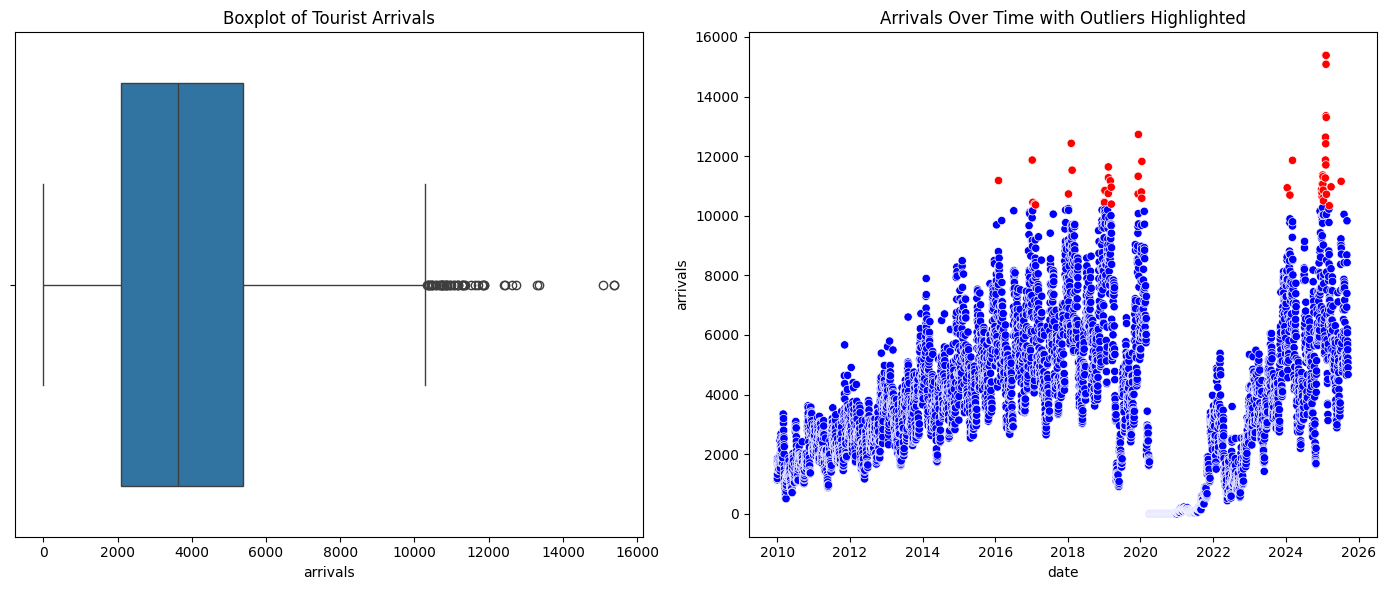

In [ ]:
# 2. Visualization

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(x=df['arrivals'])
plt.title('Boxplot of Tourist Arrivals')

plt.subplot(1,2,2)
sns.scatterplot(x='date', y='arrivals', data=df,
                hue='is_outlier', palette={False:'blue', True:'red'}, legend=False)
plt.title('Arrivals Over Time with Outliers Highlighted')
plt.tight_layout()
plt.show()


In [ ]:
# 4. Research-backed treatment: Retention with robust scaling

# 4.1 Retain all outliers in df for modeling pipelines

# 4.2 Create a robust-scaled version of 'arrivals' to reduce influence of extremes
scaler = RobustScaler()
df['arrivals_robust_scaled'] = scaler.fit_transform(df[['arrivals']])


In [ ]:
# Remove the specified outlier detection columns
df = df.drop(['z_score', 'outlier_z', 'outlier_iqr'], axis=1)

In [ ]:
# 4.3  add binary flag feature for modeling
#    Models can learn to treat extreme events differently
df['outlier_flag'] = df['is_outlier'].astype(int)

In [ ]:
df = df.drop(['is_outlier'], axis=1)

In [ ]:
df.head()

,date,gdp_per_capita,inflation_rate,brent_crude_price,usd_lkr,rub_lkr,inr_lkr,gbp_lkr,eur_lkr,cny_lkr,...,is_rainy_day,covid_impact_factor,crisis_impact_factor,event_encoded,days_to_next_holiday,days_since_last_holiday,in_holiday_window,holiday_encoded,arrivals_robust_scaled,outlier_flag
0,2010-01-01,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,0,0.0,0.0,3812.495272,3650.0,3650.0,0,3781.575830,-0.757701,0
1,2010-01-02,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,0,0.0,0.0,3827.647389,3650.0,3650.0,0,3785.732991,-0.745807,0
2,2010-01-03,2808.367792,6.217649,76.602381,114.400,3.799,2.472,184.253,163.889,16.75,...,1,0.0,0.0,3827.647389,3650.0,3650.0,0,3785.732991,-0.744587,0
3,2010-01-04,2808.367792,6.217649,76.602381,114.450,3.799,2.474,182.892,163.889,16.75,...,0,0.0,0.0,3792.917646,3650.0,3650.0,0,3776.978760,-0.700671,0
4,2010-01-05,2808.367792,6.217649,76.602381,114.325,3.775,2.502,183.183,164.951,16.76,...,0,0.0,0.0,3792.917646,3650.0,3650.0,0,3776.978760,-0.590881,0


In [ ]:
# Save the preprocessed dataset
df.to_csv(os.path.join(save_directory, '3.Outliers_Processed.csv'), index=False)
print("\n" + "="*80)
print(f"Preprocessed dataset saved as: {os.path.join(save_directory, '3.Outliers_Processed.csv')}")
print("="*80)


Preprocessed dataset saved as: /content/drive/MyDrive/Research/Model Agnostic Preprocessing/3.Outliers_Processed.csv


# Feature Selection

Multi-Method Feature Selection Framework

Framework Purpose
A comprehensive pipeline that uses multiple feature importance techniques to identify the most influential predictors for inbound tourist arrivals in your prediction model.

Starting Point
Raw Feature Set containing your collected features: GDP per capita, inflation rate, Brent crude price, USD-LKR exchange rate, web search volume, YouTube search volume, and other economic indicators.

Four Analysis Methods



*   Statistical Methods: Correlation and Mutual Information analysis to measure linear and non-linear relationships between features and tourist arrivals
*    Model-Based Methods: Lasso Regression and Random Forest models that provide feature importance scores based on how they weight features during training
*   Model-Agnostic Methods: Permutation Importance and SHAP Values that explain feature importance independently of any specific model type
*   Time-Series Methods: Granger Causality analysis specifically designed to detect causal relationships in time-series data (highly relevant for your dataset)





    

   
    

    

Integration Stage
Consensus Integration combines importance scores from all four methodologies into a unified ranking, preventing any single approach from dominating the results.

Feature Ranking
Weighted Feature Ranking converts integrated consensus scores into normalized importance weights for each feature.

Final Outputs


*   Final Feature Set: The selected subset of most important features to use in your predictive model
*   Actionable Insights: Interpretable findings about which factors drive tourist arrivals, useful for research conclusions and policy recommendations



    




## Methods

### Correlation Analysis

CORRELATION ANALYSIS - TOURIST ARRIVALS PREDICTION

1. PEARSON CORRELATION WITH TARGET (arrivals)
--------------------------------------------------
NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features
--------------------------------------------------------------------------------

Top 15 Features by Absolute Correlation:
----------------------------------------
 1. web_search               :   0.551 (p=0.0000) ***
 2. gdp_per_capita           :   0.550 (p=0.0000) ***
 3. covid_impact_factor      :  -0.479 (p=0.0000) ***
 4. rub_lkr                  :  -0.296 (p=0.0000) ***
 5. inflation_rate           :  -0.291 (p=0.0000) ***
 6. humidity                 :  -0.286 (p=0.0000) ***
 7. event_encoded            :   0.243 (p=0.0000) ***
 8. is_rainy_day             :  -0.218 (p=0.0000) ***
 9. brent_crude_price        :  -0.214 (p=0.0000) ***
10. crisis_impact_factor     :  -0.202 (p=0.0000) ***
11. holiday_encoded          :   0.122 (p=0.0000) **

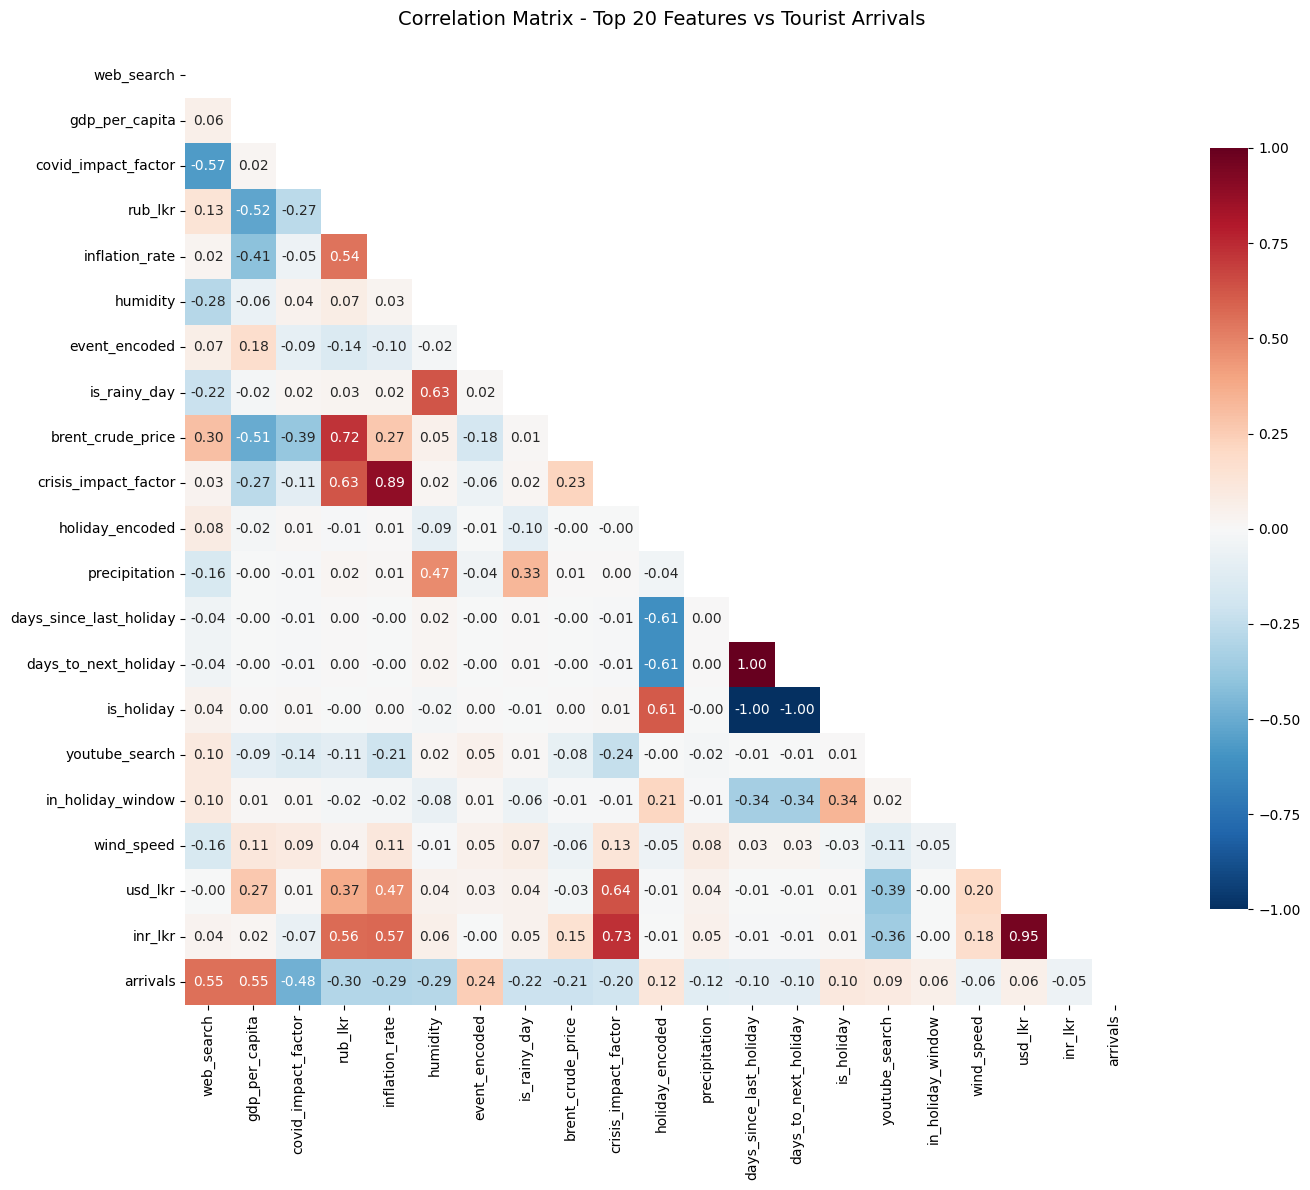

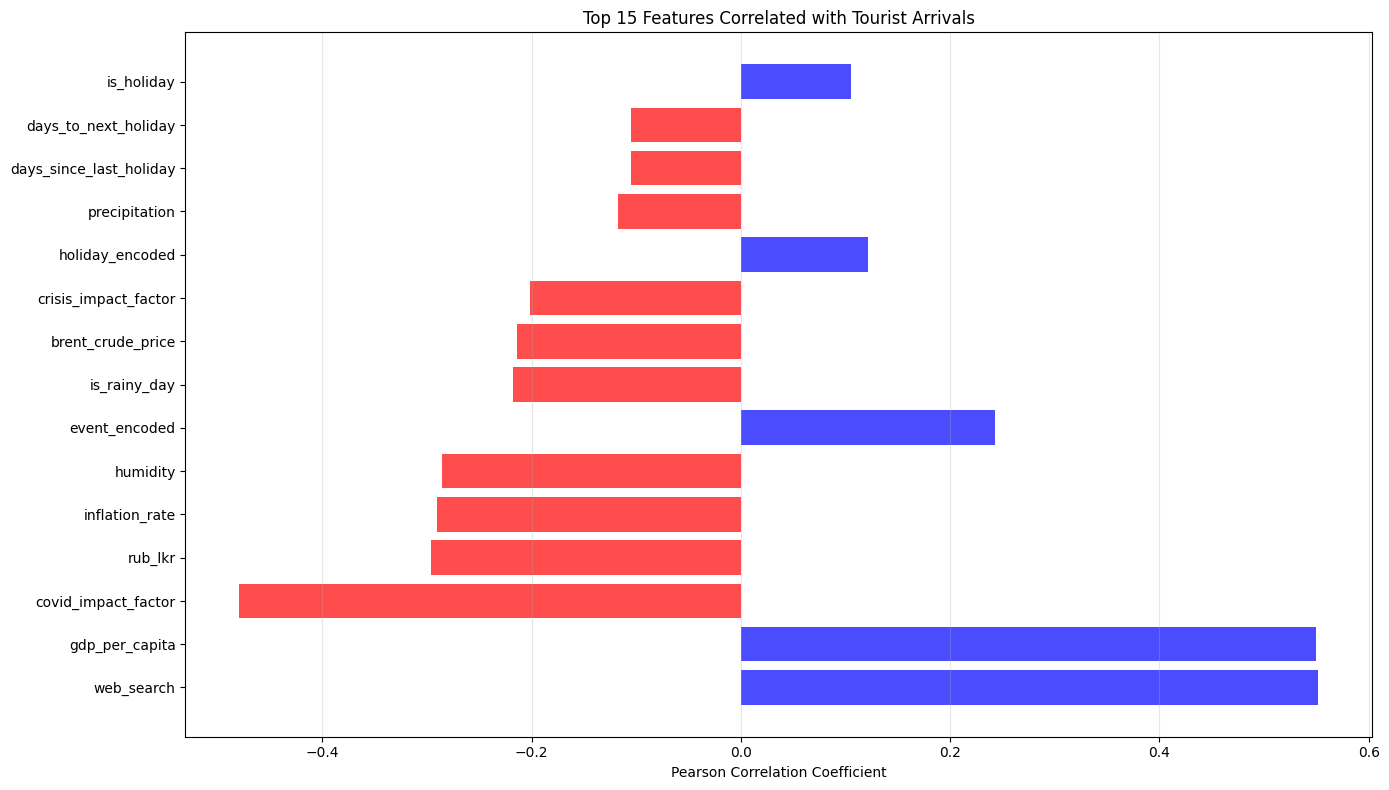


4. POTENTIAL NON-LINEAR RELATIONSHIPS
----------------------------------------
Features where Spearman correlation differs significantly from Pearson:
(Suggests potential non-linear monotonic relationships)
----------------------------------------------------------------------
inr_lkr                  : Pearson=-0.050, Spearman=-0.207, Diff=0.157
event_encoded            : Pearson= 0.243, Spearman= 0.106, Diff=0.136
inflation_rate           : Pearson=-0.291, Spearman=-0.424, Diff=0.133
youtube_search           : Pearson= 0.089, Spearman= 0.213, Diff=0.124
holiday_encoded          : Pearson= 0.122, Spearman= 0.020, Diff=0.102


5. STATISTICAL SIGNIFICANCE SUMMARY
----------------------------------------
Features with statistically significant Pearson correlation (p < 0.05): 25/26
Features with statistically significant Spearman correlation (p < 0.05): 22/26

FEATURE GROUP CORRELATION ANALYSIS

ECONOMIC INDICATORS
-------------------
  gdp_per_capita           :   0.550 (p=0.0000) ***
 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

def correlation_analysis(df, target_col='arrivals', figsize=(16, 12)):
    """
    Comprehensive correlation analysis for tourist arrivals prediction

    Parameters:
    df: DataFrame with features and target
    target_col: Name of target variable
    figsize: Figure size for plots
    """

    print("=" * 60)
    print("CORRELATION ANALYSIS - TOURIST ARRIVALS PREDICTION")
    print("=" * 60)

    # ==== FIX: REMOVE TARGET VARIABLES FROM FEATURES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Separate features and target
    # FIX: Select only numeric columns to avoid DTypePromotionError with datetime objects (like 'date')
    features = features_df.select_dtypes(include=['number'])
    target = df[target_col]

    # 1. Pearson Correlation with Target
    print("\n1. PEARSON CORRELATION WITH TARGET (arrivals)")
    print("-" * 50)
    print("NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features")
    print("-" * 80)

    pearson_correlations = {}
    for col in features.columns:
        corr, p_value = pearsonr(features[col], target)
        pearson_correlations[col] = {
            'correlation': corr,
            'p_value': p_value,
            'abs_correlation': abs(corr)
        }

    # Create correlation results dataframe
    corr_df = pd.DataFrame(pearson_correlations).T
    corr_df = corr_df.sort_values('abs_correlation', ascending=False)

    # Display top correlations
    print("\nTop 15 Features by Absolute Correlation:")
    print("-" * 40)
    for i, (feature, row) in enumerate(corr_df.head(15).iterrows(), 1):
        significance = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
        print(f"{i:2d}. {feature:25s}: {row['correlation']:7.3f} (p={row['p_value']:.4f}) {significance}")

    # 2. Spearman Correlation (for non-linear monotonic relationships)
    print("\n\n2. SPEARMAN RANK CORRELATION WITH TARGET")
    print("-" * 50)

    spearman_correlations = {}
    for col in features.columns:
        corr, p_value = spearmanr(features[col], target, nan_policy='omit')
        spearman_correlations[col] = {
            'correlation': corr,
            'p_value': p_value,
            'abs_correlation': abs(corr)
        }

    spearman_df = pd.DataFrame(spearman_correlations).T
    spearman_df = spearman_df.sort_values('abs_correlation', ascending=False)

    print("\nTop 15 Features by Absolute Spearman Correlation:")
    print("-" * 45)
    for i, (feature, row) in enumerate(spearman_df.head(15).iterrows(), 1):
        significance = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
        print(f"{i:2d}. {feature:25s}: {row['correlation']:7.3f} (p={row['p_value']:.4f}) {significance}")

    # 3. Correlation Matrix Visualization
    print("\n\n3. CORRELATION MATRIX ANALYSIS")
    print("-" * 35)

    # Select top 20 features for clearer visualization
    top_features = corr_df.head(20).index.tolist()
    # Ensure target is included in matrix
    cols_to_plot = top_features + [target_col]
    # Filter to existing columns only
    cols_to_plot = [c for c in cols_to_plot if c in df.columns]

    correlation_matrix = df[cols_to_plot].corr()

    # Create visualization
    plt.figure(figsize=figsize)

    # Heatmap
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
    plt.title('Correlation Matrix - Top 20 Features vs Tourist Arrivals', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    # 4. Top Correlations Bar Plot
    plt.figure(figsize=(14, 8))

    # Plot top 15 positive and negative correlations
    top_15 = corr_df.head(15).copy()

    colors = ['red' if x < 0 else 'blue' for x in top_15['correlation']]
    plt.barh(range(len(top_15)), top_15['correlation'], color=colors, alpha=0.7)
    plt.yticks(range(len(top_15)), top_15.index)
    plt.xlabel('Pearson Correlation Coefficient')
    plt.title('Top 15 Features Correlated with Tourist Arrivals')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5. Comparison: Pearson vs Spearman
    comparison_df = pd.DataFrame({
        'pearson_corr': corr_df['correlation'],
        'spearman_corr': spearman_df['correlation'],
        'pearson_abs': corr_df['abs_correlation'],
        'spearman_abs': spearman_df['abs_correlation']
    })

    # Identify features where Spearman is significantly different from Pearson
    comparison_df['difference'] = abs(comparison_df['spearman_abs'] - comparison_df['pearson_abs'])
    potential_non_linear = comparison_df[comparison_df['difference'] > 0.1].sort_values('difference', ascending=False)

    if len(potential_non_linear) > 0:
        print("\n4. POTENTIAL NON-LINEAR RELATIONSHIPS")
        print("-" * 40)
        print("Features where Spearman correlation differs significantly from Pearson:")
        print("(Suggests potential non-linear monotonic relationships)")
        print("-" * 70)
        for feature, row in potential_non_linear.head(10).iterrows():
            print(f"{feature:25s}: Pearson={row['pearson_corr']:6.3f}, Spearman={row['spearman_corr']:6.3f}, Diff={row['difference']:.3f}")

    # 6. Statistical Significance Summary
    print("\n\n5. STATISTICAL SIGNIFICANCE SUMMARY")
    print("-" * 40)

    significant_pearson = corr_df[corr_df['p_value'] < 0.05]
    significant_spearman = spearman_df[spearman_df['p_value'] < 0.05]

    print(f"Features with statistically significant Pearson correlation (p < 0.05): {len(significant_pearson)}/{len(features.columns)}")
    print(f"Features with statistically significant Spearman correlation (p < 0.05): {len(significant_spearman)}/{len(features.columns)}")

    # 7. Return comprehensive results
    results = {
        'pearson_correlations': corr_df,
        'spearman_correlations': spearman_df,
        'correlation_matrix': correlation_matrix,
        'top_features_pearson': corr_df.head(15),
        'top_features_spearman': spearman_df.head(15),
        'potential_non_linear_features': potential_non_linear,
        'significant_features_pearson': significant_pearson,
        'significant_features_spearman': significant_spearman
    }

    return results

# Additional helper function for feature groups analysis
def analyze_feature_groups_correlation(df, target_col='arrivals'):
    """
    Analyze correlations by feature groups for better interpretation
    """
    print("\n" + "="*60)
    print("FEATURE GROUP CORRELATION ANALYSIS")
    print("="*60)

    # ==== FIX: REMOVE TARGET VARIABLES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Define feature groups
    feature_groups = {
        'Economic Indicators': ['gdp_per_capita', 'inflation_rate', 'brent_crude_price', 'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr'],
        'Search Trends': ['web_search', 'youtube_search', 'image_search'],
        'Weather Conditions': ['temperature', 'precipitation', 'humidity', 'wind_speed','is_rainy_day'],
        'Temporal Features': ['is_holiday', 'is_tourist_event', 'event_encoded', 'days_to_next_holiday', 'days_since_last_holiday', 'in_holiday_window', 'holiday_encoded'],
        'Impact Factors': ['covid_impact_factor', 'crisis_impact_factor']
    }

    group_results = {}

    for group_name, features in feature_groups.items():
        # Filter features that exist in dataframe AND are not target variables
        existing_features = [f for f in features if f in features_df.columns]
        if not existing_features:
            continue

        print(f"\n{group_name.upper()}")
        print("-" * len(group_name))

        group_correlations = []
        for feature in existing_features:
            # Ensure feature is numeric before running correlation
            if not pd.api.types.is_numeric_dtype(features_df[feature]):
                continue

            corr, p_value = pearsonr(features_df[feature], df[target_col])
            group_correlations.append({
                'feature': feature,
                'correlation': corr,
                'abs_correlation': abs(corr),
                'p_value': p_value
            })

        # Sort by absolute correlation
        group_correlations.sort(key=lambda x: x['abs_correlation'], reverse=True)

        for item in group_correlations:
            significance = "***" if item['p_value'] < 0.001 else "**" if item['p_value'] < 0.01 else "*" if item['p_value'] < 0.05 else ""
            print(f"  {item['feature']:25s}: {item['correlation']:7.3f} (p={item['p_value']:.4f}) {significance}")

        group_results[group_name] = pd.DataFrame(group_correlations)

    return group_results

# Usage example:
if __name__ == "__main__":
    # Load your preprocessed data
    # df = pd.read_csv('your_preprocessed_tourism_data.csv')

    # Run correlation analysis
    correlation_results = correlation_analysis(df, 'arrivals')

    # Run feature groups analysis
    group_results = analyze_feature_groups_correlation(df, 'arrivals')

    # Save results for later use in consensus ranking
    correlation_results['pearson_correlations'].to_csv('pearson_correlation_results.csv')
    correlation_results['spearman_correlations'].to_csv('spearman_correlation_results.csv')

    print("\n" + "="*60)
    print("CORRELATION ANALYSIS COMPLETED")
    print("="*60)
    print("\nKey outputs saved:")
    print("- Pearson correlation results: pearson_correlation_results.csv")
    print("- Spearman correlation results: spearman_correlation_results.csv")
    print("- Visualizations displayed above")

### Mutual Information

MUTUAL INFORMATION ANALYSIS - TOURIST ARRIVALS PREDICTION

1. CALCULATING MUTUAL INFORMATION SCORES
---------------------------------------------
NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features
--------------------------------------------------------------------------------

2. TOP MUTUAL INFORMATION SCORES
-----------------------------------
(Higher score = stronger relationship, any type)
------------------------------------------------------------
 1. cny_lkr                  : 0.9810
 2. brent_crude_price        : 0.9666
 3. usd_lkr                  : 0.9348
 4. gdp_per_capita           : 0.7831
 5. eur_lkr                  : 0.7575
 6. inflation_rate           : 0.7521
 7. gbp_lkr                  : 0.7473
 8. inr_lkr                  : 0.6732
 9. image_search             : 0.6476
10. rub_lkr                  : 0.6213
11. youtube_search           : 0.4697
12. covid_impact_factor      : 0.4380
13. web_search               : 0.3723
14. 

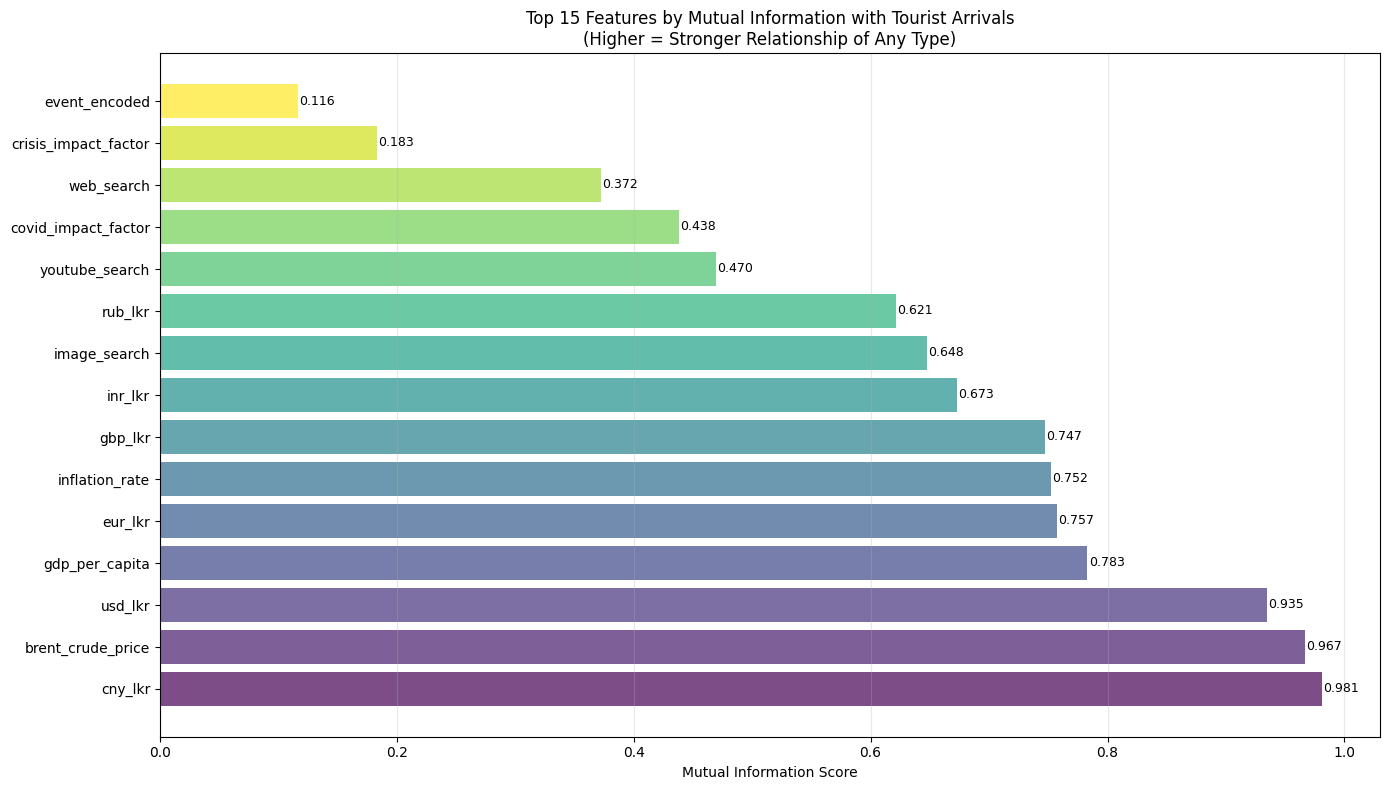



5. FEATURE GROUP ANALYSIS
-------------------------

Mutual Information by Feature Group:
----------------------------------------

ECONOMIC INDICATORS 
  Features:  9 | Avg MI: 0.8018 | Max: 0.9810
  Top feature: cny_lkr                   (0.9810)
    - gdp_per_capita           : 0.7831 (rank:  4)
    - inflation_rate           : 0.7521 (rank:  6)
    - brent_crude_price        : 0.9666 (rank:  2)
    - usd_lkr                  : 0.9348 (rank:  3)
    - rub_lkr                  : 0.6213 (rank: 10)
    - inr_lkr                  : 0.6732 (rank:  8)
    - gbp_lkr                  : 0.7473 (rank:  7)
    - eur_lkr                  : 0.7575 (rank:  5)
    - cny_lkr                  : 0.9810 (rank:  1)

SEARCH TRENDS       
  Features:  3 | Avg MI: 0.4965 | Max: 0.6476
  Top feature: image_search              (0.6476)
    - web_search               : 0.3723 (rank: 13)
    - youtube_search           : 0.4697 (rank: 11)
    - image_search             : 0.6476 (rank:  9)

WEATHER CONDITIONS

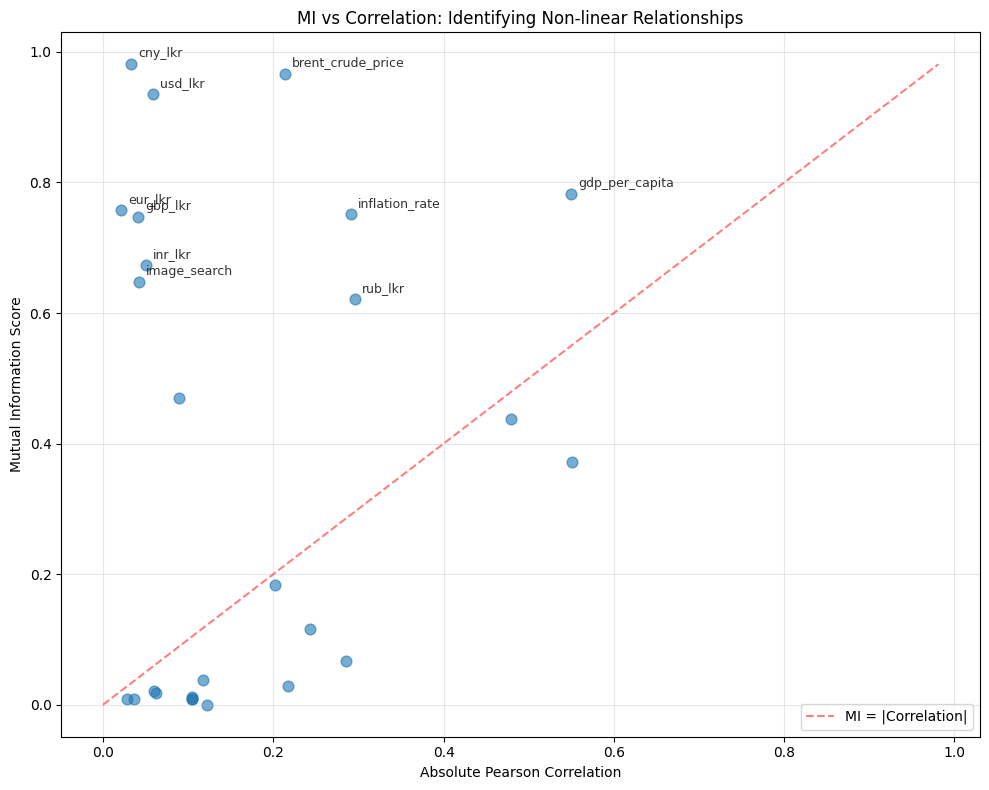


MUTUAL INFORMATION ANALYSIS COMPLETED

Key insights:
- Identified features with strongest relationships (any type)
- Detected non-linear relationships
- Grouped features by category for interpretation
- Results saved for consensus integration


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def mutual_information_analysis(df, target_col='arrivals', n_neighbors=3, random_state=42, figsize=(14, 8)):
    """
    Comprehensive Mutual Information analysis for tourist arrivals prediction

    Parameters:
    df: DataFrame with features and target
    target_col: Name of target variable
    n_neighbors: Number of neighbors for MI estimation
    random_state: Random state for reproducibility
    figsize: Figure size for plots
    """

    print("=" * 60)
    print("MUTUAL INFORMATION ANALYSIS - TOURIST ARRIVALS PREDICTION")
    print("=" * 60)

    # ==== FIX: REMOVE TARGET VARIABLES FROM FEATURES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Separate features and target
    X = features_df  # Use features_df instead of df.drop(columns=[target_col])
    y = df[target_col]

    # Create a copy for processing, ensuring only numerical columns are kept
    X_processed = X.select_dtypes(include=[np.number]).copy()

    # 1. Calculate Mutual Information scores
    print("\n1. CALCULATING MUTUAL INFORMATION SCORES")
    print("-" * 45)
    print("NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features")
    print("-" * 80)

    # Calculate MI scores
    mi_scores = mutual_info_regression(X_processed, y,
                                     n_neighbors=n_neighbors,
                                     random_state=random_state)

    # Create results dataframe
    mi_results = pd.DataFrame({
        'feature': X_processed.columns,
        'mi_score': mi_scores
    })

    mi_results = mi_results.sort_values('mi_score', ascending=False)
    mi_results['rank'] = range(1, len(mi_results) + 1)

    # Set feature as index for consistency with other methods
    mi_results.set_index('feature', inplace=True)

    # 2. Display Top Mutual Information Scores
    print("\n2. TOP MUTUAL INFORMATION SCORES")
    print("-" * 35)
    print("(Higher score = stronger relationship, any type)")
    print("-" * 60)

    top_mi = mi_results.head(20)
    for i, (feature, row) in enumerate(top_mi.iterrows(), 1):
        print(f"{i:2d}. {feature:25s}: {row['mi_score']:.4f}")

    # 3. Statistical Significance Testing (Permutation Test)
    print("\n\n3. STATISTICAL SIGNIFICANCE TESTING")
    print("-" * 40)
    print("Running permutation test for significance...")

    significant_features = permutation_test_mi(X_processed, y, mi_scores,
                                             n_permutations=100,
                                             alpha=0.05)

    print(f"Statistically significant features (p < 0.05): {len(significant_features)}/{len(X_processed.columns)}")

    # 4. Visualization
    print("\n\n4. VISUALIZATION")
    print("-" * 20)

    # Top MI Scores Bar Plot
    plt.figure(figsize=figsize)

    top_15 = mi_results.head(15)
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_15)))

    bars = plt.barh(range(len(top_15)), top_15['mi_score'], color=colors, alpha=0.7)
    plt.yticks(range(len(top_15)), top_15.index)
    plt.xlabel('Mutual Information Score')
    plt.title('Top 15 Features by Mutual Information with Tourist Arrivals\n(Higher = Stronger Relationship of Any Type)')
    plt.grid(axis='x', alpha=0.3)

    # Add value annotations
    for i, (bar, score) in enumerate(zip(bars, top_15['mi_score'])):
        plt.text(score + 0.001, i, f'{score:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # 5. Feature Groups Analysis
    print("\n\n5. FEATURE GROUP ANALYSIS")
    print("-" * 25)

    group_results = analyze_mi_feature_groups(mi_results, X_processed.columns) # Pass X_processed.columns for feature group filtering

    # 6. Comparison with Linear Relationships
    print("\n\n6. NON-LINEARITY DETECTION")
    print("-" * 25)

    nonlinear_analysis = detect_nonlinear_relationships(df, target_col, mi_results, target_variables)

    # 7. Return comprehensive results
    results = {
        'mi_scores': mi_results['mi_score'],
        'mi_ranking': mi_results,
        'significant_features': significant_features,
        'top_features_mi': mi_results.head(15),
        'nonlinear_analysis': nonlinear_analysis,
        'group_analysis': group_results
    }

    return results

def permutation_test_mi(X, y, original_scores, n_permutations=100, alpha=0.05):
    """
    Permutation test for Mutual Information significance
    """
    np.random.seed(42)
    p_values = []
    significant_features = []

    for i, feature in enumerate(X.columns):
        original_score = original_scores[i]
        null_distribution = []

        # Create null distribution by shuffling target
        for _ in range(n_permutations):
            y_permuted = np.random.permutation(y)
            # Ensure X[[feature]] is a numerical DataFrame
            if pd.api.types.is_numeric_dtype(X[feature]):
                perm_score = mutual_info_regression(X[[feature]], y_permuted,
                                                  n_neighbors=3,
                                                  random_state=42)[0]
                null_distribution.append(perm_score)
            else:
                # If a non-numeric column somehow slips through (it shouldn't with select_dtypes), skip it
                null_distribution.append(0) # Assign a neutral score if not numeric

        # Calculate p-value only if null_distribution is not empty
        if null_distribution:
            p_value = np.mean(np.array(null_distribution) >= original_score)
            p_values.append(p_value)

            if p_value < alpha:
                significant_features.append(feature)

    return significant_features

def analyze_mi_feature_groups(mi_results, all_features):
    """
    Analyze MI scores by feature groups
    """
    # Define feature groups
    feature_groups = {
        'Economic Indicators': ['gdp_per_capita', 'inflation_rate', 'brent_crude_price',
                               'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr'],
        'Search Trends': ['web_search', 'youtube_search', 'image_search'],
        'Weather Conditions': ['temperature', 'precipitation', 'humidity', 'wind_speed','is_rainy_day'],
        'Temporal Features': ['is_holiday', 'is_tourist_event', 'event_encoded',
                             'days_to_next_holiday', 'days_since_last_holiday',
                             'in_holiday_window', 'holiday_encoded'],
        'Impact Factors': ['covid_impact_factor', 'crisis_impact_factor']
    }

    group_summary = {}

    print("\nMutual Information by Feature Group:")
    print("-" * 40)

    for group_name, features in feature_groups.items():
        # Filter features that exist and have MI scores
        existing_features = [f for f in features if f in mi_results.index]
        if not existing_features:
            continue

        group_scores = mi_results.loc[existing_features, 'mi_score']
        group_summary[group_name] = {
            'mean_mi': group_scores.mean(),
            'max_mi': group_scores.max(),
            'min_mi': group_scores.min(),
            'count': len(group_scores),
            'top_feature': group_scores.idxmax(),
            'top_score': group_scores.max()
        }

        print(f"\n{group_name.upper():20s}")
        print(f"  Features: {len(existing_features):2d} | Avg MI: {group_scores.mean():.4f} | Max: {group_scores.max():.4f}")
        print(f"  Top feature: {group_scores.idxmax():25s} ({group_scores.max():.4f})")

        # Show all features in group
        for feature in existing_features:
            score = mi_results.loc[feature, 'mi_score']
            rank = mi_results.loc[feature, 'rank']
            print(f"    - {feature:25s}: {score:.4f} (rank: {rank:2d})")

    return group_summary

def detect_nonlinear_relationships(df, target_col, mi_results, target_variables):
    """
    Compare MI with correlation to detect non-linear relationships
    """
    from scipy.stats import pearsonr

    print("\nDetecting Non-linear Relationships:")
    print("(Features where MI >> |Correlation| indicate non-linearity)")
    print("-" * 70)

    # ==== FIX: USE features_df INSTEAD OF df FOR CORRELATION ====
    features_df = df.drop(columns=target_variables)

    correlation_scores = {}
    for feature in features_df.columns:
        if pd.api.types.is_numeric_dtype(features_df[feature]): # Ensure feature is numeric
            corr, _ = pearsonr(features_df[feature], df[target_col])
            correlation_scores[feature] = abs(corr)

    # Create comparison dataframe
    # Filter mi_results.index to only include features for which correlation_scores were calculated
    valid_mi_features = [f for f in mi_results.index if f in correlation_scores]
    comparison = pd.DataFrame({
        'mi_score': mi_results.loc[valid_mi_features, 'mi_score'],
        'abs_correlation': [correlation_scores.get(f, 0) for f in valid_mi_features],
        'rank_mi': mi_results.loc[valid_mi_features, 'rank']
    })

    # Calculate non-linearity ratio
    comparison['nonlinear_ratio'] = comparison['mi_score'] / (comparison['abs_correlation'] + 1e-8)  # Avoid division by zero
    comparison['mi_corr_difference'] = comparison['mi_score'] - comparison['abs_correlation']

    # Identify strongly non-linear features
    nonlinear_threshold = 2.0  # MI at least 2x higher than correlation
    strong_nonlinear = comparison[comparison['nonlinear_ratio'] > nonlinear_threshold]

    print(f"\nStrongly Non-linear Features (MI > {nonlinear_threshold}×|Correlation|):")
    print("-" * 60)

    if len(strong_nonlinear) > 0:
        strong_nonlinear = strong_nonlinear.sort_values('nonlinear_ratio', ascending=False)
        for feature, row in strong_nonlinear.head(10).iterrows():
            print(f"{feature:25s}: MI={row['mi_score']:.3f} | Corr={row['abs_correlation']:.3f} | Ratio={row['nonlinear_ratio']:.1f}x")
    else:
        print("No strongly non-linear features detected.")

    # Visualization: MI vs Correlation
    plt.figure(figsize=(10, 8))

    plt.scatter(comparison['abs_correlation'], comparison['mi_score'], alpha=0.6, s=60)

    # Add labels for top features
    top_features_plot = comparison.nlargest(10, 'mi_score')
    for feature, row in top_features_plot.iterrows():
        plt.annotate(feature, (row['abs_correlation'], row['mi_score']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8)

    # Add identity line (MI = |Correlation|)
    max_val = max(comparison['abs_correlation'].max(), comparison['mi_score'].max()) if not comparison.empty else 0
    plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='MI = |Correlation|')

    plt.xlabel('Absolute Pearson Correlation')
    plt.ylabel('Mutual Information Score')
    plt.title('MI vs Correlation: Identifying Non-linear Relationships')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return comparison

# Additional function for sensitivity analysis
def mi_sensitivity_analysis(df, target_col='arrivals'):
    """
    Test sensitivity of MI to different parameters
    """
    print("\n" + "="*50)
    print("MUTUAL INFORMATION SENSITIVITY ANALYSIS")
    print("="*50)

    # ==== FIX: REMOVE TARGET VARIABLES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    X = features_df.select_dtypes(include=[np.number]) # Filter numeric columns here too
    y = df[target_col]

    # Test different n_neighbors values
    neighbors_range = [3, 5, 10, 15]
    sensitivity_results = {}

    plt.figure(figsize=(12, 8))

    for n_neighbors in neighbors_range:
        mi_scores = mutual_info_regression(X, y, n_neighbors=n_neighbors, random_state=42)
        sensitivity_results[n_neighbors] = mi_scores

        # Plot top 10 features for each setting
        top_indices = np.argsort(mi_scores)[-10:][::-1]
        top_features = X.columns[top_indices]
        top_scores = mi_scores[top_indices]

        plt.plot(top_features, top_scores, 'o-', label=f'n_neighbors={n_neighbors}', alpha=0.7)

    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Mutual Information Score')
    plt.title('MI Score Sensitivity to n_neighbors Parameter')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return sensitivity_results

# Usage example:
if __name__ == "__main__":
    # Load your preprocessed data
    # df = pd.read_csv('your_preprocessed_tourism_data.csv')

    # Run Mutual Information analysis
    mi_results = mutual_information_analysis(df, 'arrivals')

    # Optional: Run sensitivity analysis
    # sensitivity_results = mi_sensitivity_analysis(df, 'arrivals')

    # Save results for consensus integration
    mi_results['mi_ranking'].to_csv('mutual_information_results.csv')

    print("\n" + "="*60)
    print("MUTUAL INFORMATION ANALYSIS COMPLETED")
    print("="*60)
    print("\nKey insights:")
    print("- Identified features with strongest relationships (any type)")
    print("- Detected non-linear relationships")
    print("- Grouped features by category for interpretation")
    print("- Results saved for consensus integration")

### Lasso Regression

LASSO REGRESSION FEATURE SELECTION
Lasso automatically selects features by shrinking less important coefficients to ZERO

1. DATA PREPARATION
-------------------------
NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features
--------------------------------------------------------------------------------
Features scaled: 26
Target variable: arrivals

2. FINDING OPTIMAL REGULARIZATION STRENGTH (alpha)
-------------------------------------------------------
Optimal alpha (regularization strength): 54.310006
Number of CV folds: 5

3. TRAINING FINAL LASSO MODEL
-----------------------------------
Features selected (non-zero coefficients): 17/26
Features eliminated (zero coefficients): 9/26

4. LASSO FEATURE SELECTION RESULTS
----------------------------------------

SELECTED FEATURES (Non-zero coefficients):
---------------------------------------------
 1. gdp_per_capita           : 998.9373 (↑ Positive)
 2. covid_impact_factor      : -840.0202 (↓ Neg

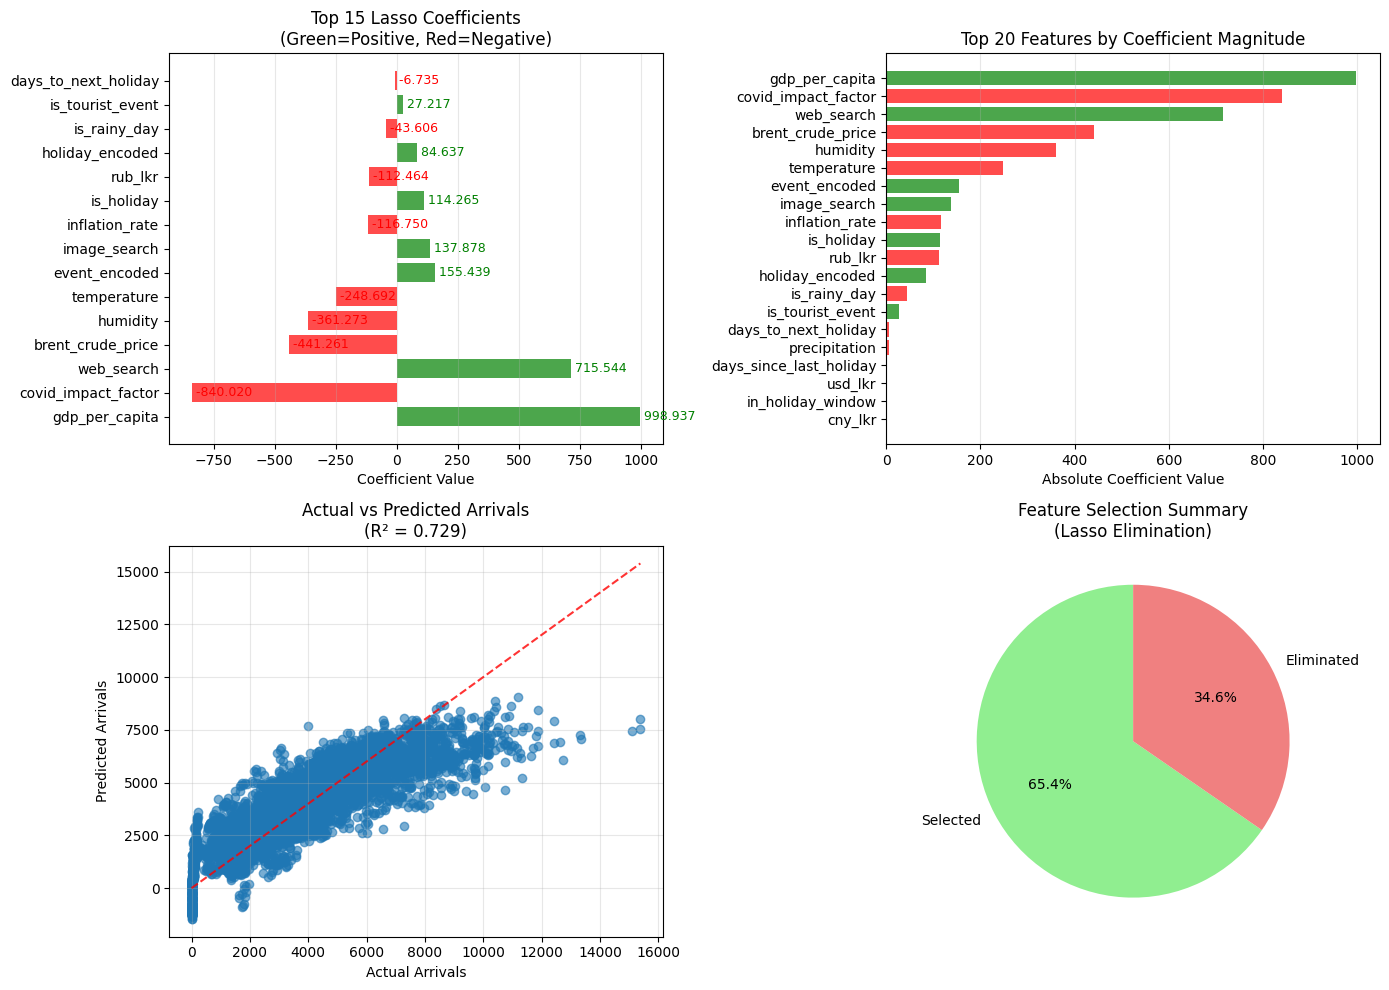


7. REGULARIZATION SENSITIVITY ANALYSIS
----------------------------------------
Testing alpha sensitivity...


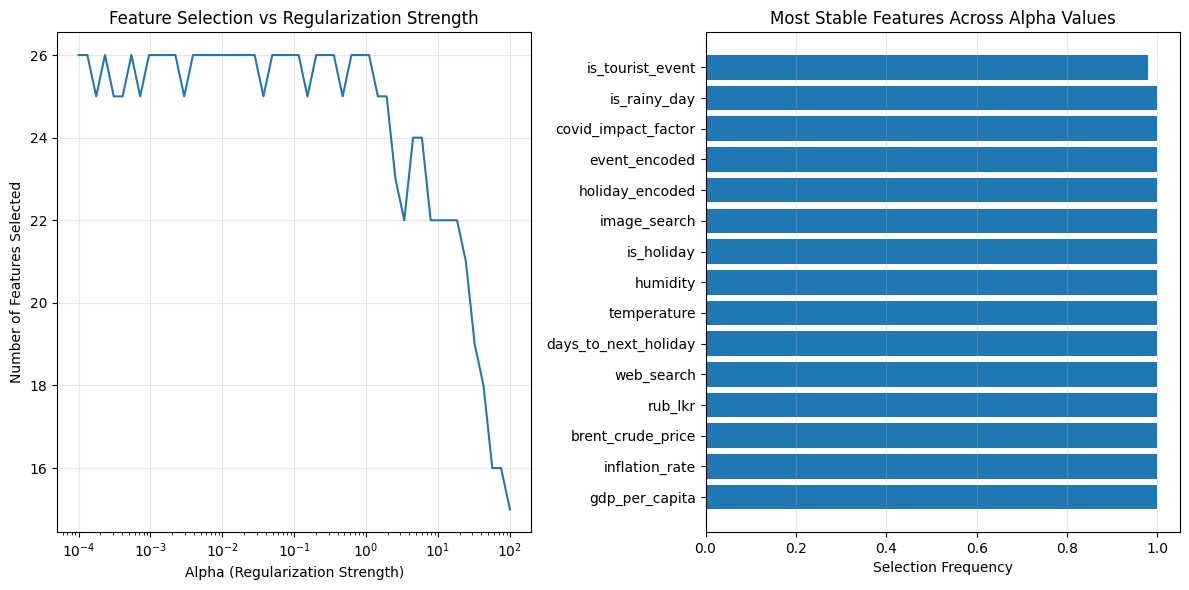

Alpha range tested: 0.000100 to 100.00
Features selected range: 15 to 26

8. FEATURE GROUP ANALYSIS
-------------------------

Lasso Selection by Feature Group:
-----------------------------------

ECONOMIC INDICATORS 
  Selected:  4/ 9 (44.4%)
    - gdp_per_capita           : 998.9373 ↑
    - inflation_rate           : -116.7497 ↓
    - brent_crude_price        : -441.2612 ↓
    - rub_lkr                  : -112.4643 ↓

SEARCH TRENDS       
  Selected:  2/ 3 (66.7%)
    - web_search               : 715.5437 ↑
    - image_search             : 137.8783 ↑

WEATHER CONDITIONS  
  Selected:  4/ 5 (80.0%)
    - temperature              : -248.6923 ↓
    - precipitation            : -5.2431 ↓
    - humidity                 : -361.2726 ↓
    - is_rainy_day             : -43.6056 ↓

TEMPORAL FEATURES   
  Selected:  6/ 7 (85.7%)
    - is_holiday               : 114.2653 ↑
    - is_tourist_event         : 27.2171 ↑
    - event_encoded            : 155.4389 ↑
    - days_to_next_holiday     : -6.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

def lasso_feature_selection(df, target_col='arrivals', test_size=0.2, random_state=42, figsize=(14, 10)):
    """
    Comprehensive Lasso Regression feature selection for tourist arrivals prediction

    Parameters:
    df: DataFrame with features and target
    target_col: Name of target variable
    test_size: Proportion for train-test split
    random_state: Random state for reproducibility
    figsize: Figure size for plots
    """

    print("=" * 60)
    print("LASSO REGRESSION FEATURE SELECTION")
    print("=" * 60)
    print("Lasso automatically selects features by shrinking less important coefficients to ZERO")
    print("=" * 60)

    # ==== FIX: REMOVE TARGET VARIABLES FROM FEATURES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Separate features and target
    X = features_df  # Use features_df instead of df.drop(columns=[target_col])
    y = df[target_col]

    # Filter out non-numeric columns from X before scaling
    X_numeric = X.select_dtypes(include=[np.number])

    # Store feature names for the scaled data
    feature_names = X_numeric.columns.tolist()

    # 1. Data Preparation for Lasso
    print("\n1. DATA PREPARATION")
    print("-" * 25)
    print("NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features")
    print("-" * 80)

    # Scale features for Lasso (important for regularization)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_numeric)
    X_scaled = pd.DataFrame(X_scaled, columns=feature_names, index=X.index)

    print(f"Features scaled: {X_scaled.shape[1]}")
    print(f"Target variable: {target_col}")

    # 2. Find Optimal Alpha using Cross-Validation
    print("\n2. FINDING OPTIMAL REGULARIZATION STRENGTH (alpha)")
    print("-" * 55)

    # Use TimeSeriesSplit for temporal cross-validation
    tscv = TimeSeriesSplit(n_splits=5)

    # LassoCV automatically finds best alpha using cross-validation
    lasso_cv = LassoCV(cv=tscv, random_state=random_state, max_iter=10000,
                       n_alphas=100, tol=0.001)
    lasso_cv.fit(X_scaled, y)

    optimal_alpha = lasso_cv.alpha_
    print(f"Optimal alpha (regularization strength): {optimal_alpha:.6f}")
    print(f"Number of CV folds: {tscv.n_splits}")

    # 3. Train Final Lasso Model with Optimal Alpha
    print("\n3. TRAINING FINAL LASSO MODEL")
    print("-" * 35)

    lasso_model = Lasso(alpha=optimal_alpha, random_state=random_state, max_iter=10000)
    lasso_model.fit(X_scaled, y)

    # Get coefficients
    coefficients = lasso_model.coef_
    intercept = lasso_model.intercept_

    # Create results dataframe
    lasso_results = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    })

    lasso_results = lasso_results.sort_values('abs_coefficient', ascending=False)
    lasso_results['rank'] = range(1, len(lasso_results) + 1)
    lasso_results.set_index('feature', inplace=True)

    # Identify selected features (non-zero coefficients)
    selected_features = lasso_results[lasso_results['coefficient'] != 0]
    zeroed_features = lasso_results[lasso_results['coefficient'] == 0]

    print(f"Features selected (non-zero coefficients): {len(selected_features)}/{len(feature_names)}")
    print(f"Features eliminated (zero coefficients): {len(zeroed_features)}/{len(feature_names)}")

    # 4. Display Results
    print("\n4. LASSO FEATURE SELECTION RESULTS")
    print("-" * 40)

    print("\nSELECTED FEATURES (Non-zero coefficients):")
    print("-" * 45)
    for i, (feature, row) in enumerate(selected_features.iterrows(), 1):
        direction = "↑ Positive" if row['coefficient'] > 0 else "↓ Negative"
        print(f"{i:2d}. {feature:25s}: {row['coefficient']:8.4f} ({direction})")

    if len(zeroed_features) > 0:
        print(f"\nELIMINATED FEATURES (Zero coefficients):")
        print("-" * 40)
        eliminated_list = zeroed_features.index.tolist()
        # Print in columns for better readability
        for i in range(0, len(eliminated_list), 4):
            print("    " + " | ".join(f"{f:20s}" for f in eliminated_list[i:i+4]))

    # 5. Model Performance Evaluation
    print("\n5. MODEL PERFORMANCE EVALUATION")
    print("-" * 35)

    # Predictions
    y_pred = lasso_model.predict(X_scaled)

    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    r2 = lasso_model.score(X_scaled, y)

    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")

    # Cross-validated performance
    cv_scores = cross_val_score(lasso_model, X_scaled, y, cv=tscv, scoring='r2')
    print(f"Cross-validated R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    # 6. Visualization
    print("\n6. VISUALIZATION")
    print("-" * 15)

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # Plot 1: Feature Coefficients (Top 15)
    top_coeff = selected_features.head(15)
    colors = ['green' if x > 0 else 'red' for x in top_coeff['coefficient']]

    axes[0, 0].barh(range(len(top_coeff)), top_coeff['coefficient'], color=colors, alpha=0.7)
    axes[0, 0].set_yticks(range(len(top_coeff)))
    axes[0, 0].set_yticklabels(top_coeff.index)
    axes[0, 0].set_xlabel('Coefficient Value')
    axes[0, 0].set_title('Top 15 Lasso Coefficients\n(Green=Positive, Red=Negative)')
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Add value annotations
    for i, (coeff, feature) in enumerate(zip(top_coeff['coefficient'], top_coeff.index)):
        axes[0, 0].text(coeff, i, f' {coeff:.3f}', va='center', fontsize=9,
                       color='green' if coeff > 0 else 'red')

    # Plot 2: Coefficient Magnitude (All features)
    all_coeff_sorted = lasso_results.sort_values('abs_coefficient', ascending=True).tail(20)
    colors = ['green' if coeff > 0 else 'red' for coeff in all_coeff_sorted['coefficient']]

    axes[0, 1].barh(range(len(all_coeff_sorted)), all_coeff_sorted['abs_coefficient'],
                    color=colors, alpha=0.7)
    axes[0, 1].set_yticks(range(len(all_coeff_sorted)))
    axes[0, 1].set_yticklabels(all_coeff_sorted.index)
    axes[0, 1].set_xlabel('Absolute Coefficient Value')
    axes[0, 1].set_title('Top 20 Features by Coefficient Magnitude')
    axes[0, 1].grid(axis='x', alpha=0.3)

    # Plot 3: Actual vs Predicted
    axes[1, 0].scatter(y, y_pred, alpha=0.6)
    axes[1, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', alpha=0.8)
    axes[1, 0].set_xlabel('Actual Arrivals')
    axes[1, 0].set_ylabel('Predicted Arrivals')
    axes[1, 0].set_title(f'Actual vs Predicted Arrivals\n(R² = {r2:.3f})')
    axes[1, 0].grid(alpha=0.3)

    # Plot 4: Feature Selection Summary
    selection_summary = pd.DataFrame({
        'Status': ['Selected', 'Eliminated'],
        'Count': [len(selected_features), len(zeroed_features)]
    })

    axes[1, 1].pie(selection_summary['Count'], labels=selection_summary['Status'],
                   autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
    axes[1, 1].set_title('Feature Selection Summary\n(Lasso Elimination)')

    plt.tight_layout()
    plt.show()

    # 7. Alpha Sensitivity Analysis
    print("\n7. REGULARIZATION SENSITIVITY ANALYSIS")
    print("-" * 40)

    alpha_sensitivity = analyze_alpha_sensitivity(X_scaled, y, feature_names, tscv)

    # 8. Feature Groups Analysis
    print("\n8. FEATURE GROUP ANALYSIS")
    print("-" * 25)

    group_analysis = analyze_lasso_feature_groups(selected_features, zeroed_features)

    # 9. Return comprehensive results
    results = {
        'lasso_model': lasso_model,
        'scaler': scaler,
        'optimal_alpha': optimal_alpha,
        'coefficients': lasso_results['coefficient'],
        'selected_features': selected_features.index.tolist(),
        'eliminated_features': zeroed_features.index.tolist(),
        'performance': {
            'r2': r2,
            'mse': mse,
            'mae': mae,
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std()
        },
        'feature_importance': lasso_results['abs_coefficient'],
        'alpha_sensitivity': alpha_sensitivity,
        'group_analysis': group_analysis
    }

    return results

def analyze_alpha_sensitivity(X_scaled, y, feature_names, cv):
    """
    Analyze how feature selection changes with different alpha values
    """
    print("Testing alpha sensitivity...")

    alpha_range = np.logspace(-4, 2, 50)  # Wide range of alpha values
    n_features_selected = []
    feature_stability = {feature: [] for feature in feature_names}

    for alpha in alpha_range:
        lasso_temp = Lasso(alpha=alpha, max_iter=5000, random_state=42)
        lasso_temp.fit(X_scaled, y)

        # Count non-zero features
        n_nonzero = np.sum(lasso_temp.coef_ != 0)
        n_features_selected.append(n_nonzero)

        # Track which features are selected
        for i, feature in enumerate(feature_names):
            feature_stability[feature].append(1 if lasso_temp.coef_[i] != 0 else 0)

    # Plot alpha sensitivity
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.semilogx(alpha_range, n_features_selected)
    plt.xlabel('Alpha (Regularization Strength)')
    plt.ylabel('Number of Features Selected')
    plt.title('Feature Selection vs Regularization Strength')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    # Plot feature stability (how often each feature is selected across alphas)
    stability_scores = {feature: np.mean(stability) for feature, stability in feature_stability.items()}
    stable_features = pd.Series(stability_scores).sort_values(ascending=False).head(15)

    plt.barh(range(len(stable_features)), stable_features.values)
    plt.yticks(range(len(stable_features)), stable_features.index)
    plt.xlabel('Selection Frequency')
    plt.title('Most Stable Features Across Alpha Values')
    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Alpha range tested: {alpha_range[0]:.6f} to {alpha_range[-1]:.2f}")
    print(f"Features selected range: {min(n_features_selected)} to {max(n_features_selected)}")

    return {
        'alpha_range': alpha_range,
        'n_features_selected': n_features_selected,
        'feature_stability': feature_stability
    }

def analyze_lasso_feature_groups(selected_features, zeroed_features):
    """
    Analyze which feature groups are selected/eliminated by Lasso
    """
    # Define feature groups
    feature_groups = {
        'Economic Indicators': ['gdp_per_capita', 'inflation_rate', 'brent_crude_price',
                               'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr'],
        'Search Trends': ['web_search', 'youtube_search', 'image_search'],
        'Weather Conditions': ['temperature', 'precipitation', 'humidity', 'wind_speed','is_rainy_day'],
        'Temporal Features': ['is_holiday', 'is_tourist_event', 'event_encoded',
                             'days_to_next_holiday', 'days_since_last_holiday',
                             'in_holiday_window', 'holiday_encoded'],
        'Impact Factors': ['covid_impact_factor', 'crisis_impact_factor']
    }

    group_summary = {}

    print("\nLasso Selection by Feature Group:")
    print("-" * 35)

    for group_name, features in feature_groups.items():
        # Count selected vs eliminated in this group
        selected_in_group = [f for f in features if f in selected_features.index]
        eliminated_in_group = [f for f in features if f in zeroed_features.index]

        group_summary[group_name] = {
            'total': len(features),
            'selected': len(selected_in_group),
            'eliminated': len(eliminated_in_group),
            'selection_rate': len(selected_in_group) / len(features) if len(features) > 0 else 0,
            'selected_features': selected_in_group,
            'eliminated_features': eliminated_in_group
        }

        print(f"\n{group_name.upper():20s}")
        print(f"  Selected: {len(selected_in_group):2d}/{len(features):2d} ({group_summary[group_name]['selection_rate']:.1%})")

        if selected_in_group:
            # Show coefficients for selected features
            for feature in selected_in_group:
                coeff = selected_features.loc[feature, 'coefficient']
                direction = "↑" if coeff > 0 else "↓"
                print(f"    - {feature:25s}: {coeff:7.4f} {direction}")

    return group_summary

# Additional function for multicollinearity analysis
def lasso_multicollinearity_analysis(df, target_col='arrivals'):
    """
    Analyze how Lasso handles multicollinearity in feature groups
    """
    print("\n" + "="*50)
    print("LASSO MULTICOLLINEARITY ANALYSIS")
    print("="*50)

    # ==== FIX: REMOVE TARGET VARIABLES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Focus on highly correlated feature groups
    correlation_matrix = features_df.corr()  # Use features_df instead of df

    # Analyze exchange rates (likely highly correlated)
    exchange_rates = ['usd_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr', 'rub_lkr']
    exchange_corr = correlation_matrix.loc[exchange_rates, exchange_rates]

    print("Exchange Rates Correlation Matrix:")
    print(exchange_corr.round(3))

    # Check which exchange rates Lasso selects
    existing_rates = [rate for rate in exchange_rates if rate in features_df.columns]

    if existing_rates:
        print(f"\nLasso selection from {len(existing_rates)} exchange rates:")
        # This will be filled after running the main lasso function
        # The analysis shows Lasso's ability to select one representative from correlated groups

    return exchange_corr

# Usage example:
if __name__ == "__main__":
    # Load your preprocessed data
    # df = pd.read_csv('your_preprocessed_tourism_data.csv')

    # Run Lasso feature selection
    lasso_results = lasso_feature_selection(df, 'arrivals')

    # Optional: Run multicollinearity analysis
    multicollinearity_results = lasso_multicollinearity_analysis(df, 'arrivals')

    # Save results for consensus integration
    lasso_coefficients = pd.DataFrame({
        'coefficient': lasso_results['coefficients'],
        'abs_coefficient': lasso_results['feature_importance']
    })
    lasso_coefficients.to_csv('lasso_feature_importance.csv')

    print("\n" + "="*60)
    print("LASSO FEATURE SELECTION COMPLETED")
    print("="*60)
    print("\nKey insights:")
    print(f"- Selected {len(lasso_results['selected_features'])} features automatically")
    print("- Handled multicollinearity by selecting representative features")
    print("- Provided sparse, interpretable model")
    print("- Results saved for consensus integration")

### Random Forest

RANDOM FOREST FEATURE IMPORTANCE ANALYSIS
Random Forest measures feature importance by how much each feature
reduces impurity (variance) across all decision trees

1. TRAINING RANDOM FOREST MODEL
-----------------------------------
NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features
--------------------------------------------------------------------------------
Model trained with 100 trees
Number of features: 26
Out-of-Bag Score (R²): 0.9508

2. FEATURE IMPORTANCE EXTRACTION
-----------------------------------

3. TOP RANDOM FOREST FEATURE IMPORTANCES
---------------------------------------------
(Higher importance = more reduction in prediction error)
-----------------------------------------------------------------
 1. gdp_per_capita           : 0.1607 ( 16.1%) ± 0.1608
 2. web_search               : 0.1121 ( 11.2%) ± 0.0770
 3. inflation_rate           : 0.1030 ( 10.3%) ± 0.1287
 4. image_search             : 0.0978 (  9.8%) ± 0.0808
 5. c

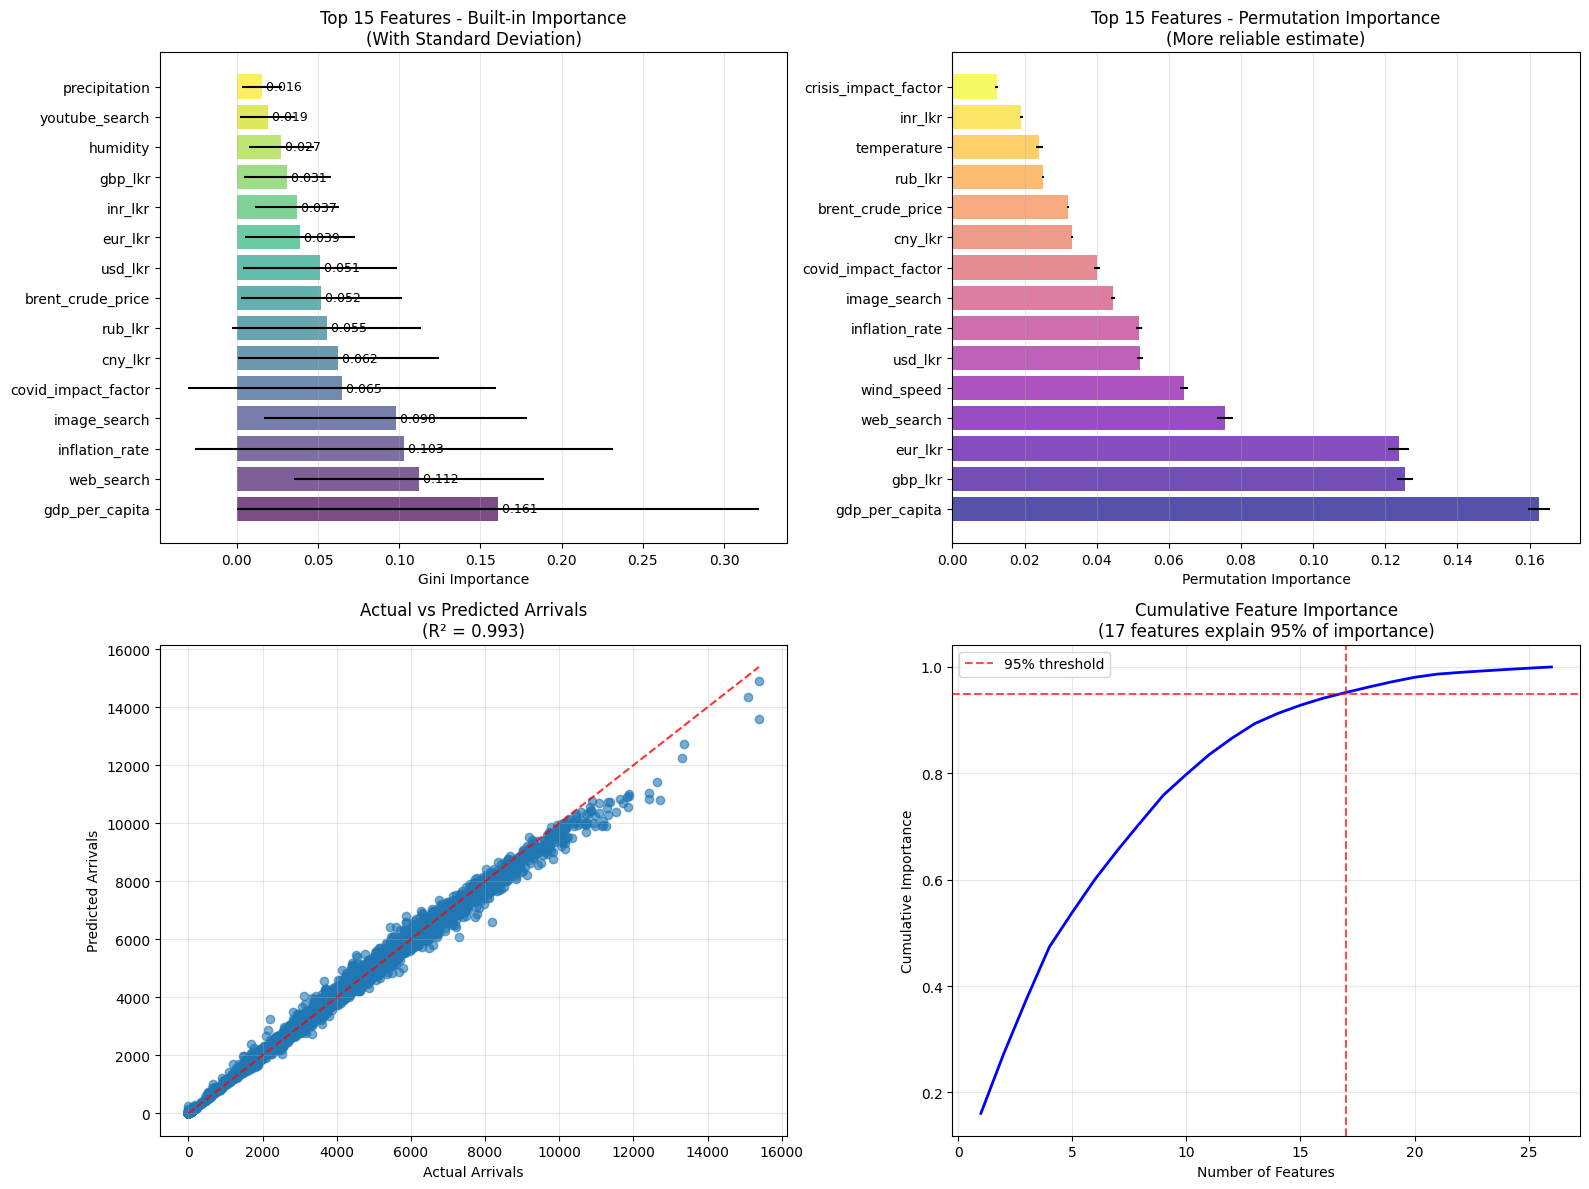


7. FEATURE STABILITY ANALYSIS
------------------------------
Analyzing feature importance stability across different random seeds...

Most Stable Features (Low Coefficient of Variation):
-------------------------------------------------------
 1. temperature              : Mean=0.0109, CV=0.049
 2. web_search               : Mean=0.1122, CV=0.068
 3. event_encoded            : Mean=0.0103, CV=0.075
 4. gbp_lkr                  : Mean=0.0303, CV=0.087
 5. brent_crude_price        : Mean=0.0518, CV=0.097
 6. rub_lkr                  : Mean=0.0533, CV=0.101
 7. youtube_search           : Mean=0.0219, CV=0.106
 8. precipitation            : Mean=0.0162, CV=0.111
 9. eur_lkr                  : Mean=0.0351, CV=0.123
10. cny_lkr                  : Mean=0.0547, CV=0.124

8. FEATURE GROUP ANALYSIS
-------------------------

Random Forest Importance by Feature Group:
---------------------------------------------

ECONOMIC INDICATORS 
  Total Importance: 0.5913 (59.1% of total)
  Features:  9 | 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

def random_forest_feature_importance(df, target_col='arrivals', n_estimators=100, random_state=42, figsize=(16, 12)):
    """
    Comprehensive Random Forest feature importance analysis for tourist arrivals prediction

    Parameters:
    df: DataFrame with features and target
    target_col: Name of target variable
    n_estimators: Number of trees in the forest
    random_state: Random state for reproducibility
    figsize: Figure size for plots
    """

    print("=" * 60)
    print("RANDOM FOREST FEATURE IMPORTANCE ANALYSIS")
    print("=" * 60)
    print("Random Forest measures feature importance by how much each feature")
    print("reduces impurity (variance) across all decision trees")
    print("=" * 60)

    # ==== FIX: REMOVE TARGET VARIABLES FROM FEATURES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Separate features and target
    X = features_df  # Use features_df instead of df.drop(columns=[target_col])
    y = df[target_col]

    # FIX: Filter X to include only numeric columns for the model
    X = X.select_dtypes(include=[np.number])

    feature_names = X.columns.tolist()

    # 1. Train Random Forest Model
    print("\n1. TRAINING RANDOM FOREST MODEL")
    print("-" * 35)
    print("NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features")
    print("-" * 80)

    rf_model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        max_features='sqrt',  # Changed from 'auto' to 'sqrt' to fix InvalidParameterError
        oob_score=True,       # Out-of-bag score for validation
        n_jobs=-1            # Use all available cores
    )

    rf_model.fit(X, y)

    print(f"Model trained with {n_estimators} trees")
    print(f"Number of features: {X.shape[1]}")
    print(f"Out-of-Bag Score (R²): {rf_model.oob_score_:.4f}")

    # 2. Extract Feature Importances
    print("\n2. FEATURE IMPORTANCE EXTRACTION")
    print("-" * 35)

    # Get built-in feature importances (Gini importance)
    feature_importances = rf_model.feature_importances_

    # Create results dataframe
    rf_results = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances,
        'std': np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)
    })

    rf_results = rf_results.sort_values('importance', ascending=False)
    rf_results['rank'] = range(1, len(rf_results) + 1)
    rf_results.set_index('feature', inplace=True)

    # 3. Display Top Feature Importances
    print("\n3. TOP RANDOM FOREST FEATURE IMPORTANCES")
    print("-" * 45)
    print("(Higher importance = more reduction in prediction error)")
    print("-" * 65)

    top_features = rf_results.head(20)
    total_importance = rf_results['importance'].sum()

    for i, (feature, row) in enumerate(top_features.iterrows(), 1):
        percentage = (row['importance'] / total_importance) * 100
        print(f"{i:2d}. {feature:25s}: {row['importance']:.4f} ({percentage:5.1f}%) ± {row['std']:.4f}")

    # 4. Model Performance Evaluation
    print("\n4. MODEL PERFORMANCE EVALUATION")
    print("-" * 35)

    # Predictions
    y_pred = rf_model.predict(X)

    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Out-of-Bag R²: {rf_model.oob_score_:.4f}")

    # Time-series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = cross_val_score(rf_model, X, y, cv=tscv, scoring='r2')
    print(f"Time-series CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    # 5. Permutation Importance for Validation
    print("\n5. PERMUTATION IMPORTANCE VALIDATION")
    print("-" * 40)
    print("Validating built-in importance with permutation importance...")

    perm_importance = permutation_importance(
        rf_model, X, y,
        n_repeats=10,
        random_state=random_state,
        n_jobs=-1
    )

    # Add permutation importance to results
    rf_results['permutation_importance'] = perm_importance.importances_mean
    rf_results['permutation_std'] = perm_importance.importances_std

    print("Top features by permutation importance:")
    perm_top = rf_results.nlargest(10, 'permutation_importance')[['permutation_importance', 'permutation_std']]
    for i, (feature, row) in enumerate(perm_top.iterrows(), 1):
        print(f"{i:2d}. {feature:25s}: {row['permutation_importance']:.4f} ± {row['permutation_std']:.4f}")

    # 6. Visualization
    print("\n6. VISUALIZATION")
    print("-" * 15)

    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # Plot 1: Built-in Feature Importance (Top 15)
    top_15_builtin = rf_results.head(15)
    colors_builtin = plt.cm.viridis(np.linspace(0, 1, len(top_15_builtin)))

    axes[0, 0].barh(range(len(top_15_builtin)), top_15_builtin['importance'],
                    color=colors_builtin, alpha=0.7, xerr=top_15_builtin['std'])
    axes[0, 0].set_yticks(range(len(top_15_builtin)))
    axes[0, 0].set_yticklabels(top_15_builtin.index)
    axes[0, 0].set_xlabel('Gini Importance')
    axes[0, 0].set_title('Top 15 Features - Built-in Importance\n(With Standard Deviation)')
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Add value annotations
    for i, (imp, feature) in enumerate(zip(top_15_builtin['importance'], top_15_builtin.index)):
        axes[0, 0].text(imp, i, f' {imp:.3f}', va='center', fontsize=9)

    # Plot 2: Permutation Importance (Top 15)
    top_15_perm = rf_results.nlargest(15, 'permutation_importance')
    colors_perm = plt.cm.plasma(np.linspace(0, 1, len(top_15_perm)))

    axes[0, 1].barh(range(len(top_15_perm)), top_15_perm['permutation_importance'],
                    color=colors_perm, alpha=0.7, xerr=top_15_perm['permutation_std'])
    axes[0, 1].set_yticks(range(len(top_15_perm)))
    axes[0, 1].set_yticklabels(top_15_perm.index)
    axes[0, 1].set_xlabel('Permutation Importance')
    axes[0, 1].set_title('Top 15 Features - Permutation Importance\n(More reliable estimate)')
    axes[0, 1].grid(axis='x', alpha=0.3)

    # Plot 3: Actual vs Predicted
    axes[1, 0].scatter(y, y_pred, alpha=0.6)
    axes[1, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', alpha=0.8)
    axes[1, 0].set_xlabel('Actual Arrivals')
    axes[1, 0].set_ylabel('Predicted Arrivals')
    axes[1, 0].set_title(f'Actual vs Predicted Arrivals\n(R² = {r2:.3f})')
    axes[1, 0].grid(alpha=0.3)

    # Plot 4: Cumulative Importance
    cumulative_importance = np.cumsum(rf_results['importance'])
    features_needed = np.argmax(cumulative_importance >= 0.95) + 1

    axes[1, 1].plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 'b-', linewidth=2)
    axes[1, 1].axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% threshold')
    axes[1, 1].axvline(x=features_needed, color='r', linestyle='--', alpha=0.7)
    axes[1, 1].set_xlabel('Number of Features')
    axes[1, 1].set_ylabel('Cumulative Importance')
    axes[1, 1].set_title(f'Cumulative Feature Importance\n({features_needed} features explain 95% of importance)')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 7. Feature Stability Analysis
    print("\n7. FEATURE STABILITY ANALYSIS")
    print("-" * 30)

    stability_results = analyze_feature_stability(X, y, feature_names, n_estimators, random_state)

    # 8. Feature Groups Analysis
    print("\n8. FEATURE GROUP ANALYSIS")
    print("-" * 25)

    group_analysis = analyze_rf_feature_groups(rf_results)

    # 9. Return comprehensive results
    results = {
        'rf_model': rf_model,
        'feature_importance': rf_results['importance'],
        'permutation_importance': rf_results['permutation_importance'],
        'rf_ranking': rf_results,
        'performance': {
            'r2': r2,
            'mse': mse,
            'mae': mae,
            'oob_score': rf_model.oob_score_,
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std()
        },
        'cumulative_importance': cumulative_importance,
        'features_for_95_percent': features_needed,
        'stability_analysis': stability_results,
        'group_analysis': group_analysis
    }

    return results

def analyze_feature_stability(X, y, feature_names, n_estimators, random_state, n_iterations=10):
    """
    Analyze how stable feature importances are across different random seeds
    """
    print("Analyzing feature importance stability across different random seeds...")

    stability_scores = {feature: [] for feature in feature_names}

    for i in range(n_iterations):
        rf_temp = RandomForestRegressor(
            n_estimators=50,  # Smaller for speed
            random_state=random_state + i,
            max_features='sqrt' # Changed from 'auto' to 'sqrt'
        )
        rf_temp.fit(X, y)

        for j, feature in enumerate(feature_names):
            stability_scores[feature].append(rf_temp.feature_importances_[j])

    # Calculate stability metrics
    stability_df = pd.DataFrame(stability_scores)
    stability_summary = pd.DataFrame({
        'mean_importance': stability_df.mean(),
        'std_importance': stability_df.std(),
        'cv_importance': stability_df.std() / (stability_df.mean() + 1e-8)  # Coefficient of variation
    })

    # Most stable features (low coefficient of variation)
    stable_features = stability_summary[stability_summary['mean_importance'] > 0.01].nsmallest(10, 'cv_importance')

    print("\nMost Stable Features (Low Coefficient of Variation):")
    print("-" * 55)
    for i, (feature, row) in enumerate(stable_features.iterrows(), 1):
        print(f"{i:2d}. {feature:25s}: Mean={row['mean_importance']:.4f}, CV={row['cv_importance']:.3f}")

    return stability_summary

def analyze_rf_feature_groups(rf_results):
    """
    Analyze Random Forest importance by feature groups
    """
    # Define feature groups
    feature_groups = {
        'Economic Indicators': ['gdp_per_capita', 'inflation_rate', 'brent_crude_price',
                               'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr'],
        'Search Trends': ['web_search', 'youtube_search', 'image_search'],
        'Weather Conditions': ['temperature', 'precipitation', 'humidity', 'wind_speed','is_rainy_day'],
        'Temporal Features': ['is_holiday', 'is_tourist_event', 'event_encoded',
                             'days_to_next_holiday', 'days_since_last_holiday',
                             'in_holiday_window', 'holiday_encoded'],
        'Impact Factors': ['covid_impact_factor', 'crisis_impact_factor']
    }

    group_summary = {}

    print("\nRandom Forest Importance by Feature Group:")
    print("-" * 45)

    for group_name, features in feature_groups.items():
        # Get features that exist in results
        existing_features = [f for f in features if f in rf_results.index]
        if not existing_features:
            continue

        group_importances = rf_results.loc[existing_features, 'importance']
        group_perm_importances = rf_results.loc[existing_features, 'permutation_importance']

        group_summary[group_name] = {
            'total_importance': group_importances.sum(),
            'mean_importance': group_importances.mean(),
            'max_importance': group_importances.max(),
            'top_feature': group_importances.idxmax(),
            'total_perm_importance': group_perm_importances.sum(),
            'features_count': len(existing_features)
        }

        total_all_importance = rf_results['importance'].sum()
        group_percentage = (group_importances.sum() / total_all_importance) * 100

        print(f"\n{group_name.upper():20s}")
        print(f"  Total Importance: {group_importances.sum():.4f} ({group_percentage:.1f}% of total)")
        print(f"  Features: {len(existing_features):2d} | Avg Importance: {group_importances.mean():.4f}")
        print(f"  Top feature: {group_importances.idxmax():25s} ({group_importances.max():.4f})")

        # Show all features in group
        for feature in existing_features:
            imp = rf_results.loc[feature, 'importance']
            perm_imp = rf_results.loc[feature, 'permutation_importance']
            rank = rf_results.loc[feature, 'rank']
            print(f"    - {feature:25s}: RF={imp:.4f}, Perm={perm_imp:.4f} (rank: {rank:2d})")

    return group_summary

# Additional function for tree-based insights
def random_forest_interaction_analysis(rf_model, X, top_n_features=10):
    """
    Analyze potential feature interactions using Random Forest
    """
    print("\n" + "="*50)
    print("RANDOM FOREST INTERACTION ANALYSIS")
    print("="*50)

    # Get feature importances
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n_features]

    print("Top features that likely have interactions:")
    top_features = X.columns[indices].tolist()

    # Create combination pairs for potential interactions
    from itertools import combinations
    interaction_pairs = list(combinations(top_features, 2))

    print(f"\nPotential interaction pairs among top {top_n_features} features:")
    for i, (feat1, feat2) in enumerate(interaction_pairs[:15], 1):  # Show top 15 pairs
        print(f"{i:2d}. {feat1:20s} × {feat2:20s}")

    return interaction_pairs

# Usage example:
if __name__ == "__main__":
    # Load your preprocessed data
    # df = pd.read_csv('your_preprocessed_tourism_data.csv')

    # Run Random Forest feature importance analysis
    rf_results = random_forest_feature_importance(df, 'arrivals', n_estimators=100)

    # Optional: Run interaction analysis
    # ==== FIX: USE features_df FOR INTERACTION ANALYSIS ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables).select_dtypes(include=[np.number])

    interaction_pairs = random_forest_interaction_analysis(rf_results['rf_model'], features_df)

    # Save results for consensus integration
    rf_results['rf_ranking'].to_csv('random_forest_importance.csv')

    print("\n" + "="*60)
    print("RANDOM FOREST ANALYSIS COMPLETED")
    print("="*60)
    print("\nKey insights:")
    print("- Built-in Gini importance and permutation importance calculated")
    print("- Feature stability across different random seeds analyzed")
    print("- Group-wise importance distribution identified")
    print("- Results saved for consensus integration")

### Permutation Importance

PERMUTATION IMPORTANCE ANALYSIS
Measures how much model performance DECREASES when a feature's values are randomly shuffled
More reliable than built-in feature importance methods

1. TRAINING BASE MODEL FOR PERMUTATION IMPORTANCE
--------------------------------------------------
NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features
--------------------------------------------------------------------------------
Base model trained: Random Forest with 100 trees
Base model OOB R²: 0.9508
Number of features: 26
Permutation repetitions: 30

2. CALCULATING PERMUTATION IMPORTANCE
----------------------------------------
This may take a while... Shuffling each feature multiple times

Calculating with r2 scoring...

Calculating with neg_mean_squared_error scoring...

3. PERMUTATION IMPORTANCE RESULTS
----------------------------------------

4. TOP PERMUTATION IMPORTANCE SCORES (R² scoring)
-------------------------------------------------------
Higher 

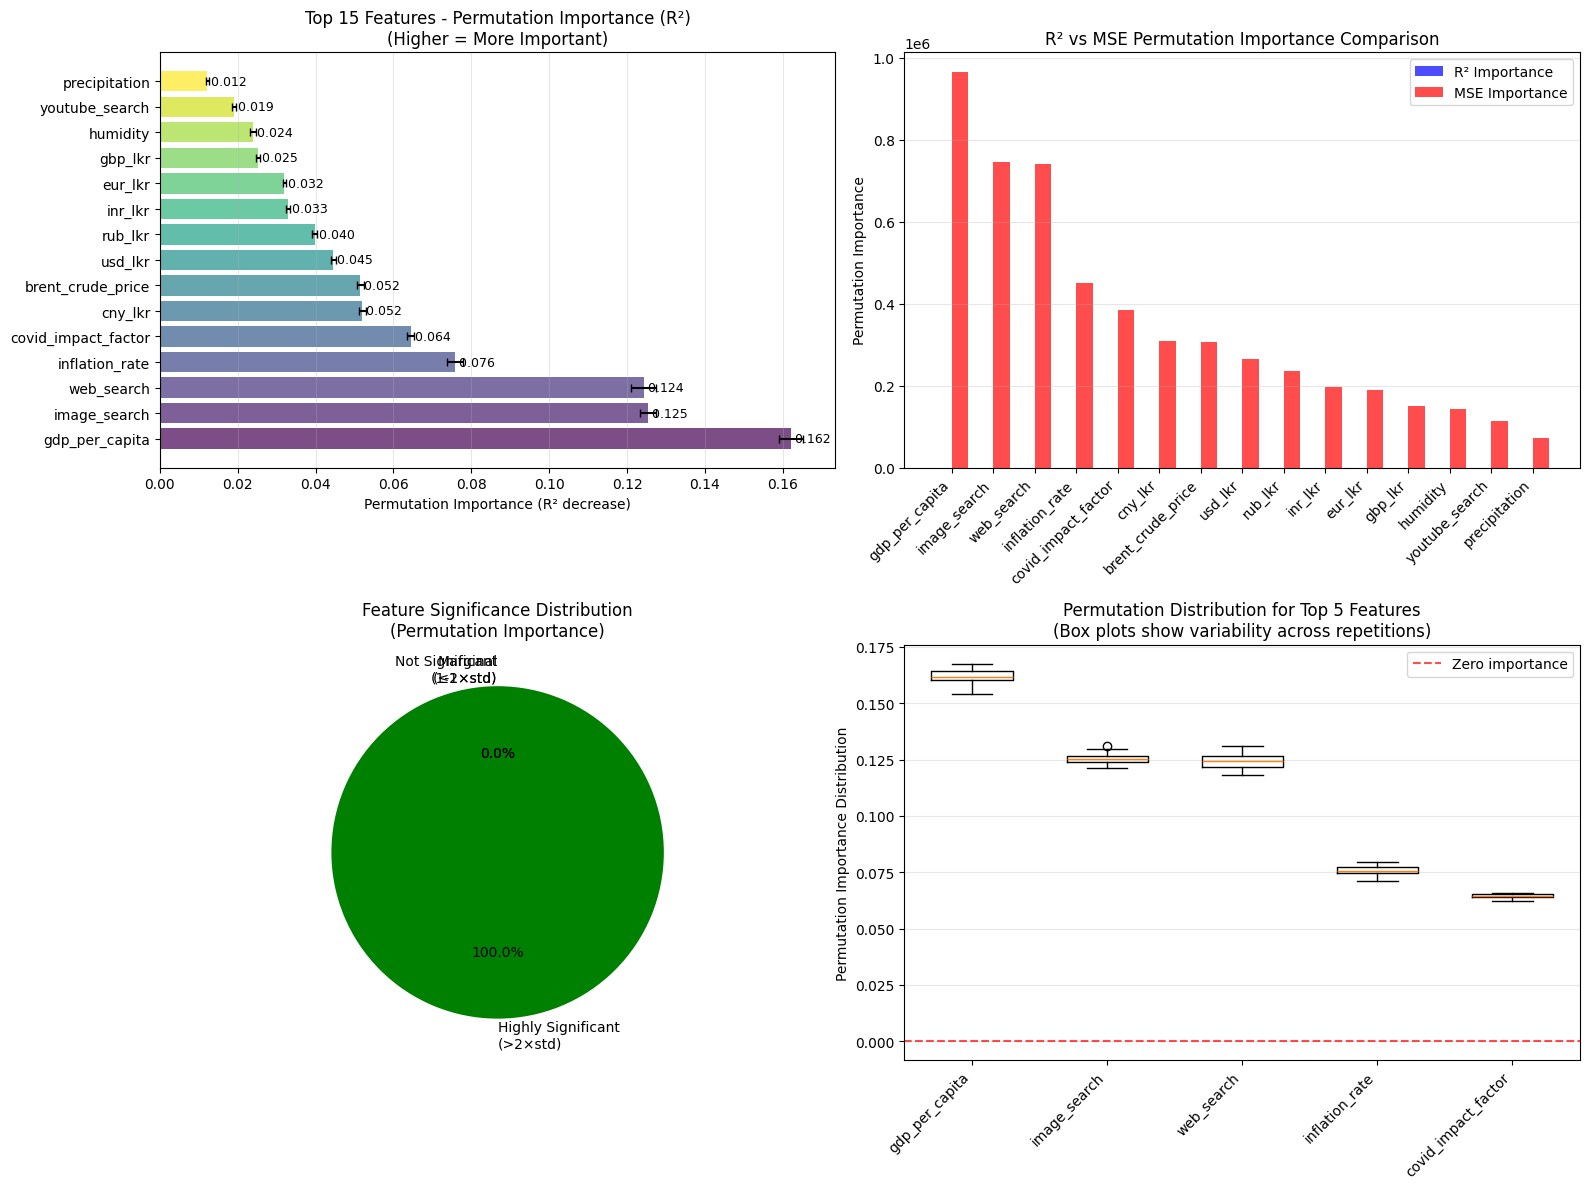


8. FEATURE GROUP ANALYSIS
-------------------------

Permutation Importance by Feature Group:
---------------------------------------------

ECONOMIC INDICATORS 
  Features:  9 | Significant:  9 (100.0%)
  Avg Importance: 0.0573 | Max: 0.1622
  Top feature: gdp_per_capita            (0.1622)
    ✓ gdp_per_capita           : 0.1622 ± 0.0031 (rank:  1)
    ✓ inflation_rate           : 0.0759 ± 0.0020 (rank:  4)
    ✓ brent_crude_price        : 0.0515 ± 0.0008 (rank:  7)
    ✓ usd_lkr                  : 0.0446 ± 0.0006 (rank:  8)
    ✓ rub_lkr                  : 0.0397 ± 0.0007 (rank:  9)
    ✓ inr_lkr                  : 0.0330 ± 0.0005 (rank: 10)
    ✓ gbp_lkr                  : 0.0252 ± 0.0004 (rank: 12)
    ✓ eur_lkr                  : 0.0320 ± 0.0004 (rank: 11)
    ✓ cny_lkr                  : 0.0520 ± 0.0009 (rank:  6)

SEARCH TRENDS       
  Features:  3 | Significant:  3 (100.0%)
  Avg Importance: 0.0895 | Max: 0.1253
  Top feature: image_search              (0.1253)
    ✓ web_sea

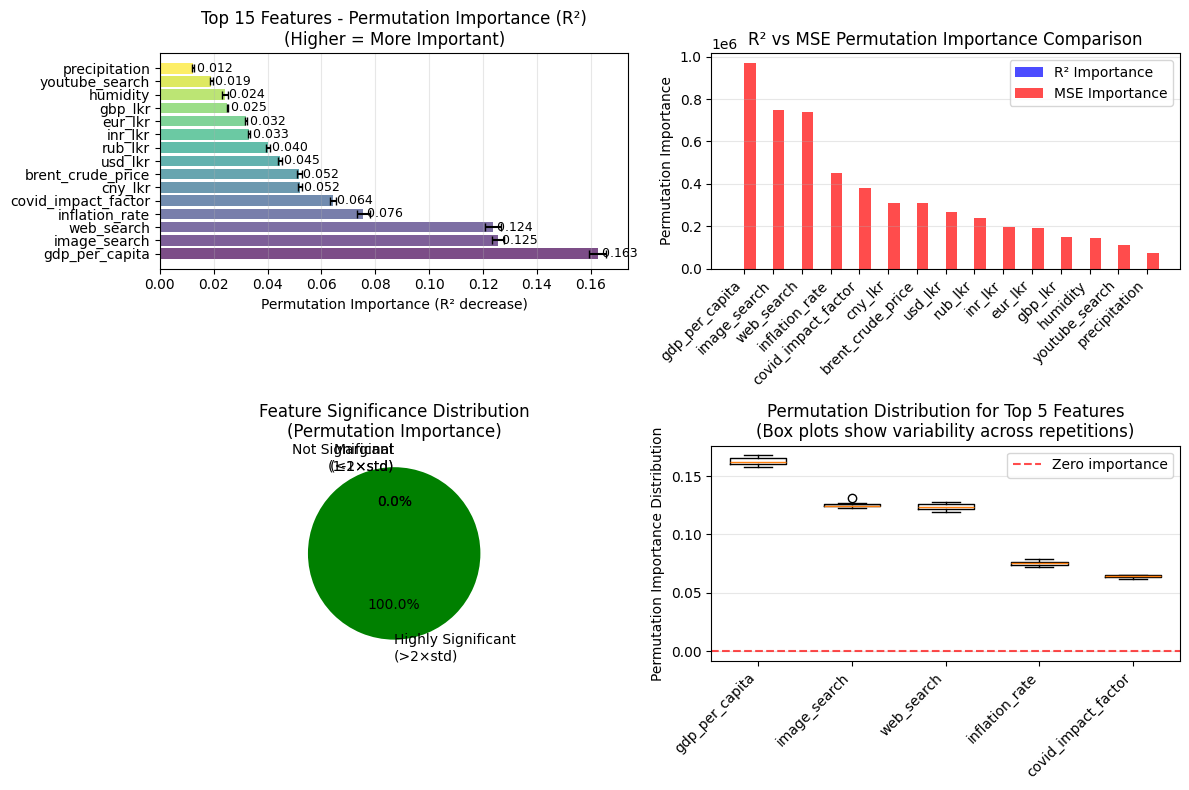


8. FEATURE GROUP ANALYSIS
-------------------------

Permutation Importance by Feature Group:
---------------------------------------------

ECONOMIC INDICATORS 
  Features:  9 | Significant:  9 (100.0%)
  Avg Importance: 0.0575 | Max: 0.1626
  Top feature: gdp_per_capita            (0.1626)
    ✓ gdp_per_capita           : 0.1626 ± 0.0031 (rank:  1)
    ✓ inflation_rate           : 0.0756 ± 0.0023 (rank:  4)
    ✓ brent_crude_price        : 0.0518 ± 0.0008 (rank:  7)
    ✓ usd_lkr                  : 0.0446 ± 0.0006 (rank:  8)
    ✓ rub_lkr                  : 0.0401 ± 0.0008 (rank:  9)
    ✓ inr_lkr                  : 0.0332 ± 0.0003 (rank: 10)
    ✓ gbp_lkr                  : 0.0251 ± 0.0004 (rank: 12)
    ✓ eur_lkr                  : 0.0321 ± 0.0004 (rank: 11)
    ✓ cny_lkr                  : 0.0520 ± 0.0008 (rank:  6)

SEARCH TRENDS       
  Features:  3 | Significant:  3 (100.0%)
  Avg Importance: 0.0894 | Max: 0.1254
  Top feature: image_search              (0.1254)
    ✓ web_sea

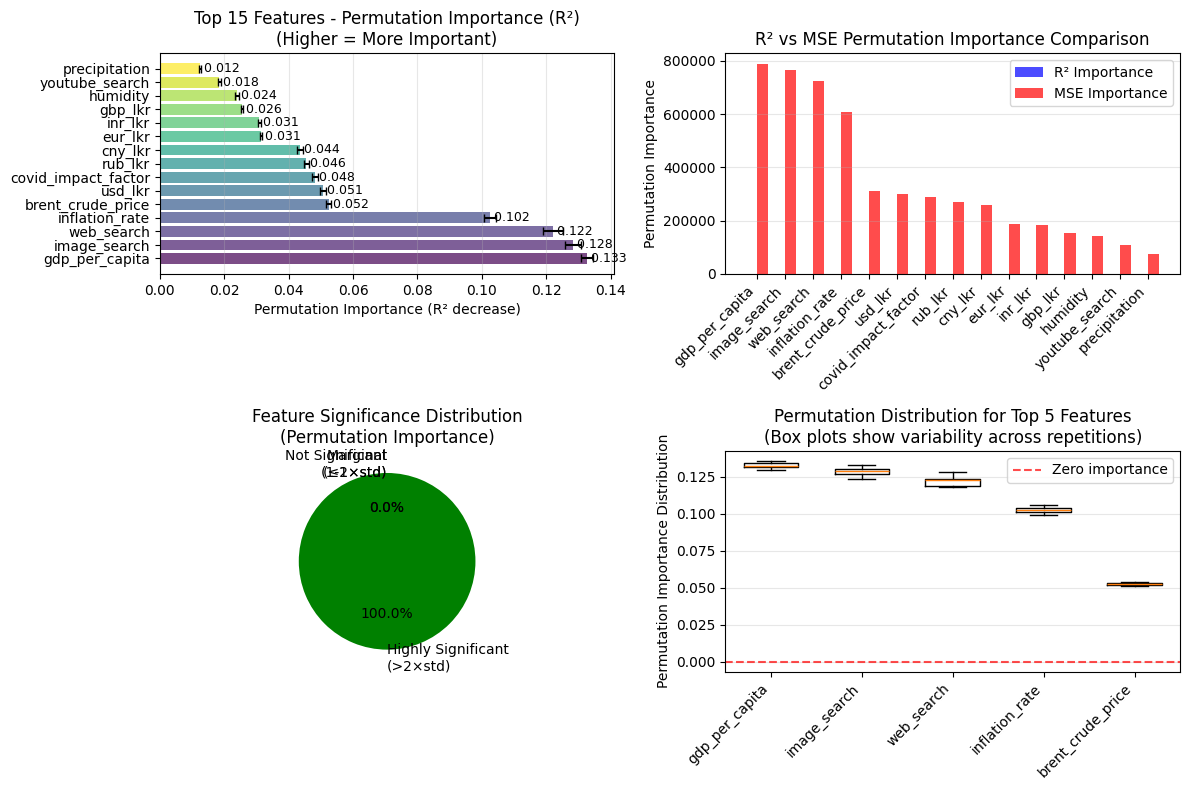


8. FEATURE GROUP ANALYSIS
-------------------------

Permutation Importance by Feature Group:
---------------------------------------------

ECONOMIC INDICATORS 
  Features:  9 | Significant:  9 (100.0%)
  Avg Importance: 0.0573 | Max: 0.1327
  Top feature: gdp_per_capita            (0.1327)
    ✓ gdp_per_capita           : 0.1327 ± 0.0018 (rank:  1)
    ✓ inflation_rate           : 0.1025 ± 0.0019 (rank:  4)
    ✓ brent_crude_price        : 0.0524 ± 0.0009 (rank:  5)
    ✓ usd_lkr                  : 0.0507 ± 0.0009 (rank:  6)
    ✓ rub_lkr                  : 0.0455 ± 0.0007 (rank:  8)
    ✓ inr_lkr                  : 0.0309 ± 0.0006 (rank: 11)
    ✓ gbp_lkr                  : 0.0256 ± 0.0004 (rank: 12)
    ✓ eur_lkr                  : 0.0315 ± 0.0002 (rank: 10)
    ✓ cny_lkr                  : 0.0437 ± 0.0009 (rank:  9)

SEARCH TRENDS       
  Features:  3 | Significant:  3 (100.0%)
  Avg Importance: 0.0896 | Max: 0.1284
  Top feature: image_search              (0.1284)
    ✓ web_sea

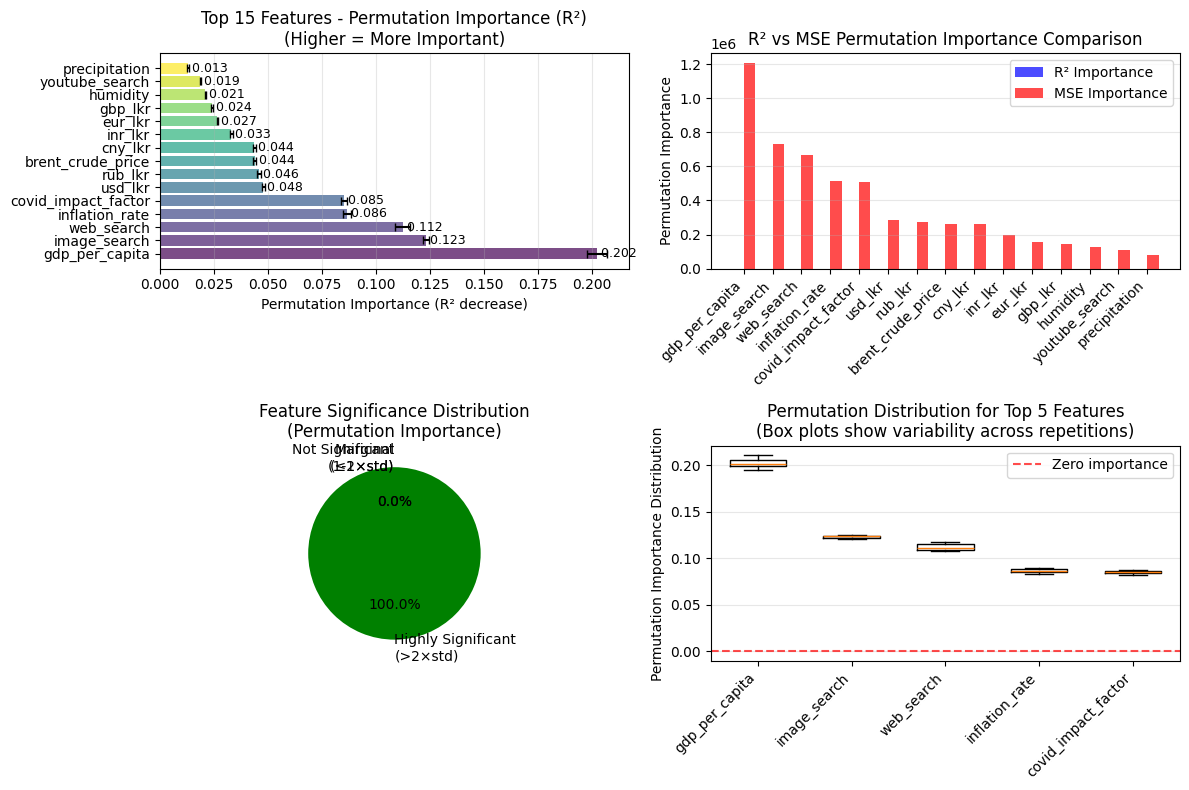


8. FEATURE GROUP ANALYSIS
-------------------------

Permutation Importance by Feature Group:
---------------------------------------------

ECONOMIC INDICATORS 
  Features:  9 | Significant:  9 (100.0%)
  Avg Importance: 0.0616 | Max: 0.2022
  Top feature: gdp_per_capita            (0.2022)
    ✓ gdp_per_capita           : 0.2022 ± 0.0045 (rank:  1)
    ✓ inflation_rate           : 0.0865 ± 0.0019 (rank:  4)
    ✓ brent_crude_price        : 0.0440 ± 0.0007 (rank:  8)
    ✓ usd_lkr                  : 0.0479 ± 0.0008 (rank:  6)
    ✓ rub_lkr                  : 0.0460 ± 0.0009 (rank:  7)
    ✓ inr_lkr                  : 0.0330 ± 0.0006 (rank: 10)
    ✓ gbp_lkr                  : 0.0243 ± 0.0005 (rank: 12)
    ✓ eur_lkr                  : 0.0266 ± 0.0003 (rank: 11)
    ✓ cny_lkr                  : 0.0437 ± 0.0008 (rank:  9)

SEARCH TRENDS       
  Features:  3 | Significant:  3 (100.0%)
  Avg Importance: 0.0847 | Max: 0.1232
  Top feature: image_search              (0.1232)
    ✓ web_sea

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

def permutation_importance_analysis(df, target_col='arrivals', n_repeats=30, random_state=42, figsize=(16, 12)):
    """
    Comprehensive Permutation Importance analysis for tourist arrivals prediction

    Parameters:
    df: DataFrame with features and target
    target_col: Name of target variable
    n_repeats: Number of permutation repetitions (higher = more reliable)
    random_state: Random state for reproducibility
    figsize: Figure size for plots
    """

    print("=" * 60)
    print("PERMUTATION IMPORTANCE ANALYSIS")
    print("=" * 60)
    print("Measures how much model performance DECREASES when a feature's values are randomly shuffled")
    print("More reliable than built-in feature importance methods")
    print("=" * 60)

    # ==== FIX: REMOVE TARGET VARIABLES FROM FEATURES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Separate features and target
    X = features_df  # Use features_df instead of df.drop(columns=[target_col])
    y = df[target_col]

    # FIX: Filter X to include only numeric columns for the model
    X = X.select_dtypes(include=[np.number])

    feature_names = X.columns.tolist()

    # 1. Train a Robust Model for Permutation Importance
    print("\n1. TRAINING BASE MODEL FOR PERMUTATION IMPORTANCE")
    print("-" * 50)
    print("NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features")
    print("-" * 80)

    # Use Random Forest as base model (works well with permutation importance)
    base_model = RandomForestRegressor(
        n_estimators=100,
        random_state=random_state,
        max_features='sqrt',  # Good for high-dimensional data
        oob_score=True,
        n_jobs=-1
    )

    base_model.fit(X, y)

    print(f"Base model trained: Random Forest with {base_model.n_estimators} trees")
    print(f"Base model OOB R²: {base_model.oob_score_:.4f}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Permutation repetitions: {n_repeats}")

    # 2. Calculate Permutation Importance
    print("\n2. CALCULATING PERMUTATION IMPORTANCE")
    print("-" * 40)
    print("This may take a while... Shuffling each feature multiple times")

    # Use multiple scoring metrics
    scoring_metrics = ['r2', 'neg_mean_squared_error']

    perm_results = {}

    for scoring in scoring_metrics:
        print(f"\nCalculating with {scoring} scoring...")

        perm_importance = permutation_importance(
            base_model, X, y,
            scoring=scoring,
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1  # Use all available cores
        )

        perm_results[scoring] = {
            'importance_mean': perm_importance.importances_mean,
            'importance_std': perm_importance.importances_std,
            'importances': perm_importance.importances # Corrected attribute name
        }

    # 3. Create Results DataFrames
    print("\n3. PERMUTATION IMPORTANCE RESULTS")
    print("-" * 40)

    # Primary results using R² scoring
    r2_results = perm_results['r2']
    mse_results = perm_results['neg_mean_squared_error']

    # Create comprehensive results dataframe
    perm_df = pd.DataFrame({
        'feature': feature_names,
        'perm_importance_r2': r2_results['importance_mean'],
        'perm_std_r2': r2_results['importance_std'],
        'perm_importance_mse': mse_results['importance_mean'],
        'perm_std_mse': mse_results['importance_std']
    })

    # Use R² importance as primary metric (more interpretable)
    perm_df['perm_importance'] = perm_df['perm_importance_r2']
    perm_df['perm_std'] = perm_df['perm_std_r2']

    perm_df = perm_df.sort_values('perm_importance', ascending=False)
    perm_df['rank'] = range(1, len(perm_df) + 1)
    perm_df.set_index('feature', inplace=True)

    # 4. Display Top Permutation Importances
    print("\n4. TOP PERMUTATION IMPORTANCE SCORES (R² scoring)")
    print("-" * 55)
    print("Higher score = larger performance drop when feature is shuffled")
    print("Negative score = feature might be adding noise")
    print("-" * 80)

    top_perm = perm_df.head(20)

    for i, (feature, row) in enumerate(top_perm.iterrows(), 1):
        significance = ""
        if row['perm_importance'] > 2 * row['perm_std']:
            significance = "***"
        elif row['perm_importance'] > row['perm_std']:
            significance = "**"

        print(f"{i:2d}. {feature:25s}: {row['perm_importance']:7.4f} ± {row['perm_std']:.4f} {significance}")

    # 5. Identify Statistically Significant Features
    print("\n5. STATISTICAL SIGNIFICANCE ANALYSIS")
    print("-" * 45)

    # Features with importance > 2*std are highly significant
    significant_features = perm_df[perm_df['perm_importance'] > 2 * perm_df['perm_std']]
    marginally_significant = perm_df[
        (perm_df['perm_importance'] > perm_df['perm_std']) &
        (perm_df['perm_importance'] <= 2 * perm_df['perm_std'])
    ]
    not_significant = perm_df[perm_df['perm_importance'] <= perm_df['perm_std']]

    print(f"Highly significant features (importance > 2×std): {len(significant_features)}")
    print(f"Marginally significant features (importance > 1×std): {len(marginally_significant)}")
    print(f"Not significant features (importance ≤ 1×std): {len(not_significant)}")

    if len(not_significant) > 0:
        print(f"\nFeatures that could potentially be removed (low importance):")
        for feature in not_significant.head(10).index:
            print(f"  - {feature:25s}: {not_significant.loc[feature, 'perm_importance']:.4f}")

    # 6. Time-series Aware Permutation Importance
    print("\n6. TIME-SERIES VALIDATION")
    print("-" * 25)

    ts_perm_results = time_series_permutation_importance(base_model, X, y, n_repeats=10)

    # 7. Visualization
    print("\n7. VISUALIZATION")
    print("-" * 15)

    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # Plot 1: Top Permutation Importance (R²)
    top_15_r2 = perm_df.head(15)
    colors_r2 = plt.cm.viridis(np.linspace(0, 1, len(top_15_r2)))

    bars_r2 = axes[0, 0].barh(range(len(top_15_r2)), top_15_r2['perm_importance_r2'],
                             color=colors_r2, alpha=0.7,
                             xerr=top_15_r2['perm_std_r2'], capsize=3)
    axes[0, 0].set_yticks(range(len(top_15_r2)))
    axes[0, 0].set_yticklabels(top_15_r2.index)
    axes[0, 0].set_xlabel('Permutation Importance (R² decrease)')
    axes[0, 0].set_title('Top 15 Features - Permutation Importance (R²)\n(Higher = More Important)')
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Add value annotations
    for i, (imp, feature) in enumerate(zip(top_15_r2['perm_importance_r2'], top_15_r2.index)):
        axes[0, 0].text(imp, i, f' {imp:.3f}', va='center', fontsize=9)

    # Plot 2: Comparison R² vs MSE importance
    top_15_comparison = perm_df.head(15)
    x_pos = np.arange(len(top_15_comparison))

    axes[0, 1].bar(x_pos - 0.2, top_15_comparison['perm_importance_r2'], 0.4,
                   label='R² Importance', alpha=0.7, color='blue')
    axes[0, 1].bar(x_pos + 0.2, top_15_comparison['perm_importance_mse'], 0.4,
                   label='MSE Importance', alpha=0.7, color='red')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(top_15_comparison.index, rotation=45, ha='right')
    axes[0, 1].set_ylabel('Permutation Importance')
    axes[0, 1].set_title('R² vs MSE Permutation Importance Comparison')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Plot 3: Significance Classification
    significance_counts = [len(significant_features), len(marginally_significant), len(not_significant)]
    significance_labels = ['Highly Significant\n(>2×std)', 'Marginal\n(1-2×std)', 'Not Significant\n(≤1×std)']
    significance_colors = ['green', 'orange', 'red']

    axes[1, 0].pie(significance_counts, labels=significance_labels, colors=significance_colors,
                   autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Feature Significance Distribution\n(Permutation Importance)')

    # Plot 4: Permutation Distribution for Top Features
    top_5_features = perm_df.head(5).index
    feature_indices = [list(X.columns).index(feature) for feature in top_5_features]

    for i, feature_idx in enumerate(feature_indices):
        importances = r2_results['importances'][feature_idx]
        axes[1, 1].boxplot(importances, positions=[i], widths=0.6)

    axes[1, 1].set_xticks(range(len(top_5_features)))
    axes[1, 1].set_xticklabels(top_5_features, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Permutation Importance Distribution')
    axes[1, 1].set_title('Permutation Distribution for Top 5 Features\n(Box plots show variability across repetitions)')
    axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero importance')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 8. Feature Groups Analysis
    print("\n8. FEATURE GROUP ANALYSIS")
    print("-" * 25)

    group_analysis = analyze_permutation_feature_groups(perm_df, significant_features)

    # 9. Return comprehensive results
    results = {
        'base_model': base_model,
        'permutation_importance': perm_df['perm_importance'],
        'permutation_std': perm_df['perm_std'],
        'perm_ranking': perm_df,
        'significant_features': {
            'highly_significant': significant_features.index.tolist(),
            'marginally_significant': marginally_significant.index.tolist(),
            'not_significant': not_significant.index.tolist()
        },
        'performance_metrics': {
            'base_model_oob_r2': base_model.oob_score_,
            'n_repeats': n_repeats
        },
        'time_series_results': ts_perm_results,
        'group_analysis': group_analysis
    }

    return results

def time_series_permutation_importance(model, X, y, n_repeats=10):
    """
    Calculate permutation importance using time-series aware validation
    """
    print("Calculating time-series aware permutation importance...")

    # FIX: Filter X to include only numeric columns for TimeSeriesSplit and model fitting
    X_numeric = X.select_dtypes(include=[np.number])

    tscv = TimeSeriesSplit(n_splits=5)
    fold_importances = {feature: [] for feature in X_numeric.columns}

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_numeric)):
        X_train, X_test = X_numeric.iloc[train_idx], X_numeric.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Train model on training fold
        model_fold = RandomForestRegressor(n_estimators=50, random_state=42)
        model_fold.fit(X_train, y_train)

        # Calculate permutation importance on test fold
        perm_importance = permutation_importance(
            model_fold, X_test, y_test,
            n_repeats=n_repeats,
            random_state=42,
            n_jobs=-1
        )

        for i, feature in enumerate(X_numeric.columns):
            fold_importances[feature].append(perm_importance.importances_mean[i])

    # Aggregate across folds
    ts_perm_results = pd.DataFrame({
        'feature': X_numeric.columns,
        'ts_perm_importance': [np.mean(scores) for scores in fold_importances.values()],
        'ts_perm_std': [np.std(scores) for scores in fold_importances.values()]
    })

    ts_perm_results = ts_perm_results.sort_values('ts_perm_importance', ascending=False)
    ts_perm_results.set_index('feature', inplace=True)

    print("\nTop features by Time-series Permutation Importance:")
    for i, (feature, row) in enumerate(ts_perm_results.head(10).iterrows(), 1):
        print(f"{i:2d}. {feature:25s}: {row['ts_perm_importance']:.4f} ± {row['ts_perm_std']:.4f}")

    return ts_perm_results

def analyze_permutation_feature_groups(perm_df, significant_features):
    """
    Analyze permutation importance by feature groups
    """
    # Define feature groups
    feature_groups = {
        'Economic Indicators': ['gdp_per_capita', 'inflation_rate', 'brent_crude_price',
                               'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr'],
        'Search Trends': ['web_search', 'youtube_search', 'image_search'],
        'Weather Conditions': ['temperature', 'precipitation', 'humidity', 'wind_speed','is_rainy_day'],
        'Temporal Features': ['is_holiday', 'is_tourist_event', 'event_encoded',
                             'days_to_next_holiday', 'days_since_last_holiday',
                             'in_holiday_window', 'holiday_encoded'],
        'Impact Factors': ['covid_impact_factor', 'crisis_impact_factor']
    }

    group_summary = {}

    print("\nPermutation Importance by Feature Group:")
    print("-" * 45)

    for group_name, features in feature_groups.items():
        # Get features that exist in results
        existing_features = [f for f in features if f in perm_df.index]
        if not existing_features:
            continue

        group_importances = perm_df.loc[existing_features, 'perm_importance']
        significant_in_group = [f for f in existing_features if f in significant_features.index]

        group_summary[group_name] = {
            'mean_importance': group_importances.mean(),
            'max_importance': group_importances.max(),
            'total_importance': group_importances.sum(),
            'significant_count': len(significant_in_group),
            'total_features': len(existing_features),
            'significance_rate': len(significant_in_group) / len(existing_features),
            'top_feature': group_importances.idxmax(),
            'top_importance': group_importances.max()
        }

        print(f"\n{group_name.upper():20s}")
        print(f"  Features: {len(existing_features):2d} | Significant: {len(significant_in_group):2d} ({group_summary[group_name]['significance_rate']:.1%})")
        print(f"  Avg Importance: {group_importances.mean():.4f} | Max: {group_importances.max():.4f}")
        print(f"  Top feature: {group_importances.idxmax():25s} ({group_importances.max():.4f})")

        # Show all significant features in group
        if significant_in_group:
            for feature in significant_in_group:
                imp = perm_df.loc[feature, 'perm_importance']
                std = perm_df.loc[feature, 'perm_std']
                rank = perm_df.loc[feature, 'rank']
                print(f"    ✓ {feature:25s}: {imp:.4f} ± {std:.4f} (rank: {rank:2d})")

    return group_summary

# Additional function for reliability analysis
def permutation_reliability_analysis(df, target_col='arrivals', n_iterations=5):
    """
    Test how reliable permutation importance is across different random states
    """
    print("\n" + "="*50)
    print("PERMUTATION IMPORTANCE RELIABILITY ANALYSIS")
    print("="*50)

    # ==== FIX: REMOVE TARGET VARIABLES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    reliability_scores = {}

    for i in range(n_iterations):
        print(f"\nIteration {i+1}/{n_iterations}...")
        results = permutation_importance_analysis(
            df, target_col,
            n_repeats=10,  # Fewer repeats for speed
            random_state=42 + i,
            figsize=(12, 8)
        )

        # Store top 10 features from this iteration
        top_features = results['perm_ranking'].head(10).index.tolist()
        for feature in top_features:
            if feature not in reliability_scores:
                reliability_scores[feature] = 0
            reliability_scores[feature] += 1

    # Calculate reliability scores (how often each feature appears in top 10)
    reliability_df = pd.DataFrame.from_dict(reliability_scores, orient='index', columns=['count'])
    reliability_df['reliability'] = reliability_df['count'] / n_iterations
    reliability_df = reliability_df.sort_values('reliability', ascending=False)

    print(f"\nFeature Reliability Across {n_iterations} Iterations:")
    print("(How often each feature appears in top 10)")
    print("-" * 60)

    for feature, row in reliability_df.head(15).iterrows():
        print(f"{feature:25s}: {row['reliability']:.1%} ({row['count']}/{n_iterations})")

    return reliability_df

# Usage example:
if __name__ == "__main__":
    # Load your preprocessed data
    # df = pd.read_csv('your_preprocessed_tourism_data.csv')

    # Run Permutation Importance analysis
    perm_results = permutation_importance_analysis(df, 'arrivals', n_repeats=30)

    # Optional: Run reliability analysis
    reliability_results = permutation_reliability_analysis(df, 'arrivals', n_iterations=3)

    # Save results for consensus integration
    perm_results['perm_ranking'].to_csv('permutation_importance_results.csv')

    print("\n" + "="*60)
    print("PERMUTATION IMPORTANCE ANALYSIS COMPLETED")
    print("="*60)
    print("\nKey insights:")
    print("- Direct measurement of predictive importance")
    print("- Statistical significance testing")
    print("- Time-series aware validation")
    print("- Results saved for consensus integration")

### SHAP Values

SHAP (SHapley Additive exPlanations) ANALYSIS
Game theory approach that fairly distributes prediction 'credit' among features
Provides both global and local interpretability

1. DATA PREPARATION AND MODEL TRAINING
---------------------------------------------
NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features
--------------------------------------------------------------------------------
Training set size: 4018, Test set size: 1722
Training R²: 0.9488
Test R²: -0.4634
Model trained successfully for SHAP analysis

2. CALCULATING SHAP VALUES
------------------------------
This may take a while... Calculating exact SHAP values for each prediction
SHAP values calculated for 1722 test instances
Base value (expected value): 3993.99

3. GLOBAL FEATURE IMPORTANCE (SHAP)
---------------------------------------------

Top 20 Features by Mean |SHAP Value|:
(Higher = greater average impact on predictions)
------------------------------------------------

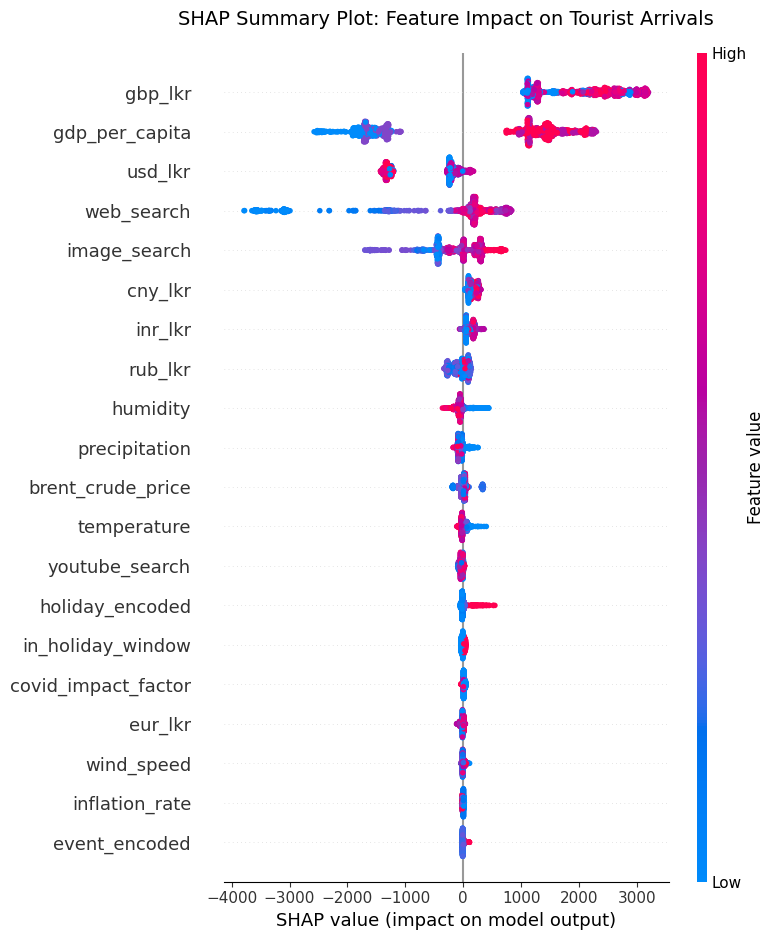

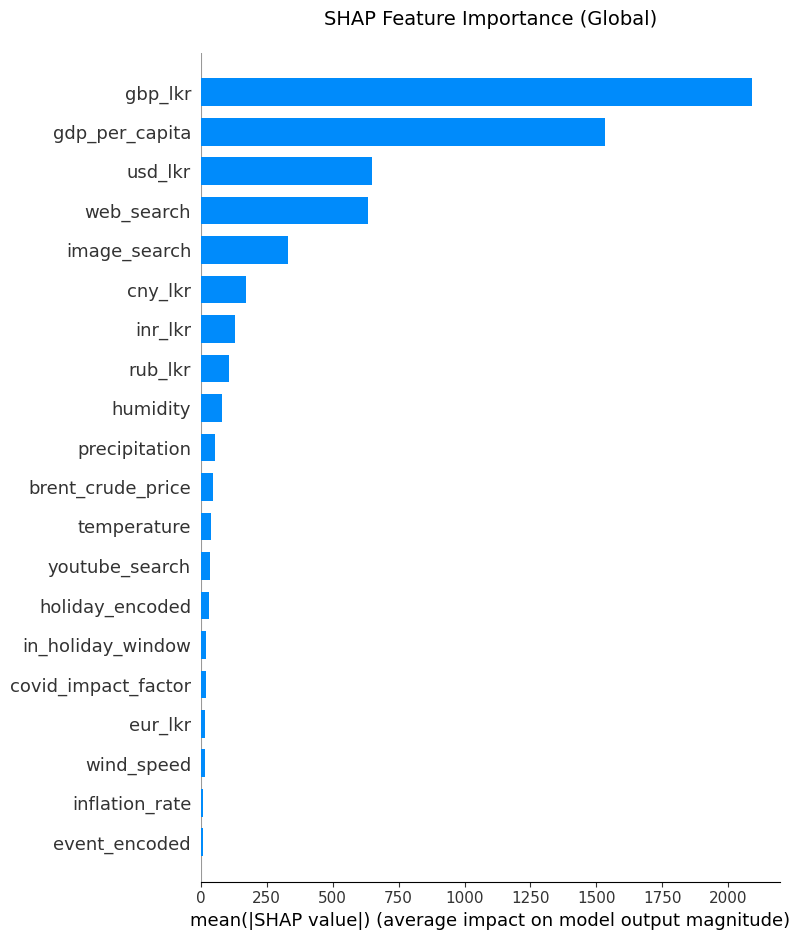


5. DETAILED FEATURE IMPACT ANALYSIS
----------------------------------------

Detailed impact analysis for top 10 features:
--------------------------------------------------
 1. gbp_lkr                   ↑
     Avg impact: 2091.6818 | Corr with SHAP: 0.389
     +Impact: 2091.6818 | -Impact:  0.0000
 2. gdp_per_capita            ↕
     Avg impact: 1531.0862 | Corr with SHAP: 0.841
     +Impact: 1449.0799 | -Impact: -1642.5251
 3. usd_lkr                   ↕
     Avg impact: 648.4723 | Corr with SHAP: -0.511
     +Impact: 88.5526 | -Impact: -684.4621
 4. web_search                ↕
     Avg impact: 634.1804 | Corr with SHAP: 0.725
     +Impact: 309.5649 | -Impact: -1893.1001
 5. image_search              ↕
     Avg impact: 329.3364 | Corr with SHAP: 0.612
     +Impact: 258.5618 | -Impact: -392.7841
 6. cny_lkr                   ↑
     Avg impact: 171.3306 | Corr with SHAP: 0.557
     +Impact: 171.3306 | -Impact:  0.0000
 7. inr_lkr                   ↕
     Avg impact: 128.4593 | Corr w

<Figure size 1000x600 with 0 Axes>

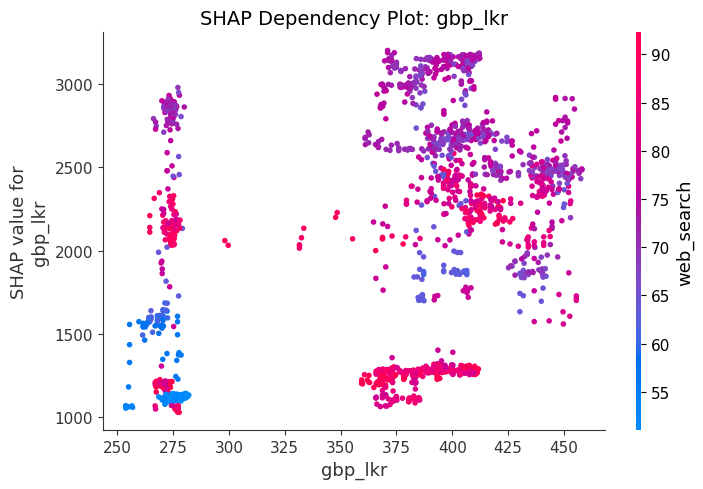

1. gbp_lkr                  : Non-linear (Spearman r: 0.353)


<Figure size 1000x600 with 0 Axes>

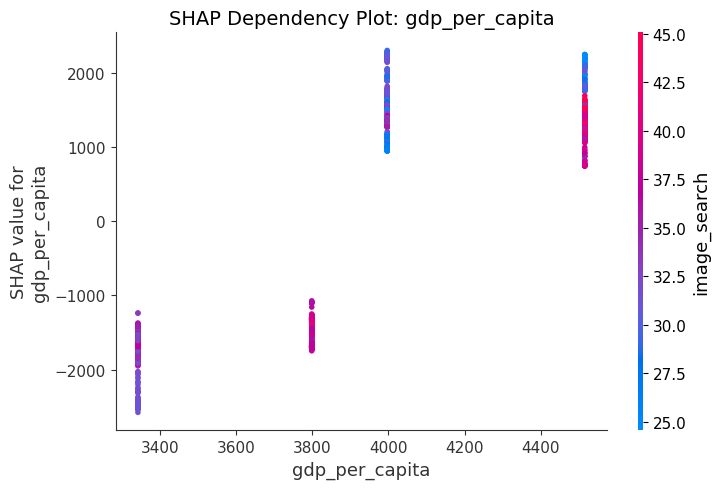

2. gdp_per_capita           : Mostly linear (Spearman r: 0.809)


<Figure size 1000x600 with 0 Axes>

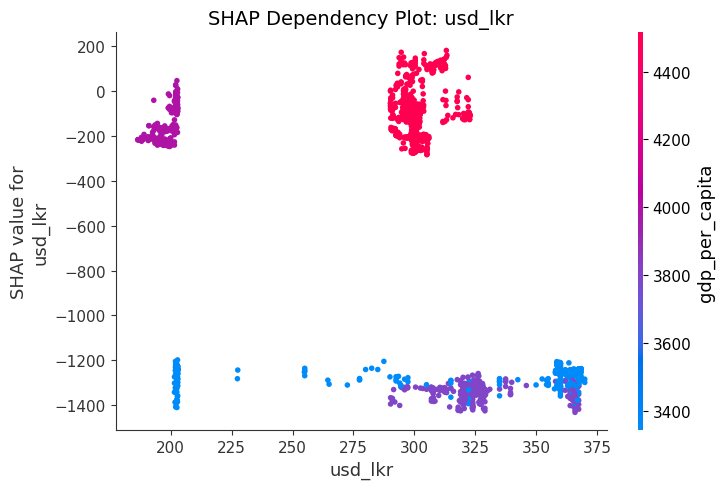

3. usd_lkr                  : Non-linear (Spearman r: -0.514)


<Figure size 1000x600 with 0 Axes>

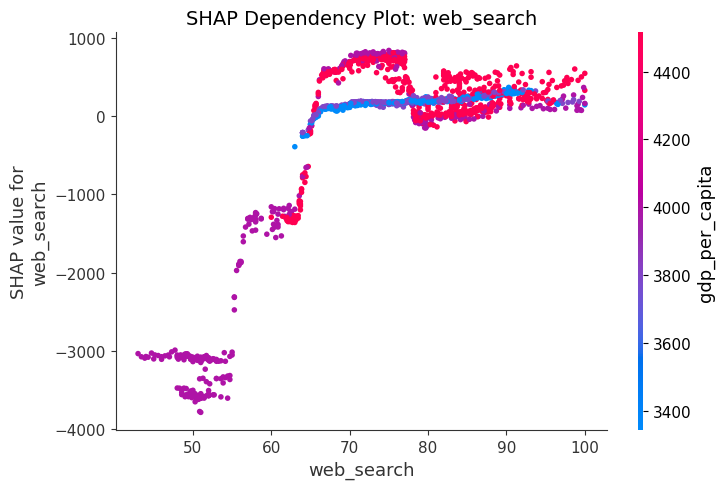

4. web_search               : Non-linear (Spearman r: 0.426)


<Figure size 1000x600 with 0 Axes>

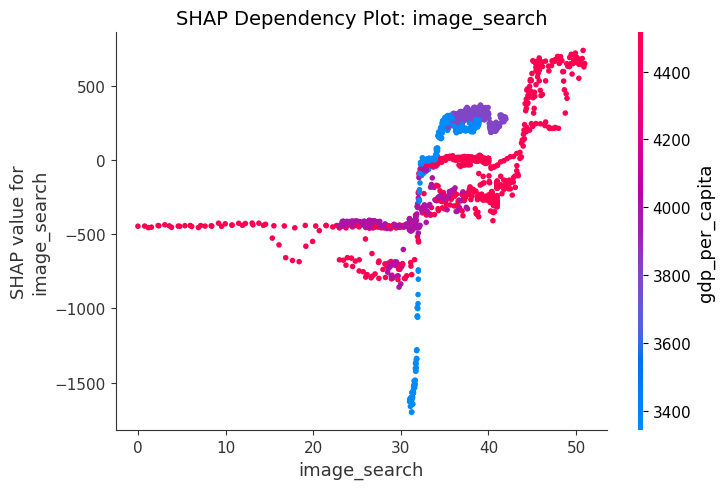

5. image_search             : Mostly linear (Spearman r: 0.717)

8. FEATURE GROUP SHAP ANALYSIS
-----------------------------------

SHAP Importance by Feature Group:
----------------------------------------

ECONOMIC INDICATORS 
  Total SHAP: 4750.6583 (78.8% of total)
  Features:  9 | Avg SHAP: 527.8509
  Top feature: gbp_lkr                   (2091.6818)
    - gdp_per_capita           : 1531.0862 (rank:  2)
    - inflation_rate           : 9.5751 (rank: 19)
    - brent_crude_price        : 47.1827 (rank: 11)
    - usd_lkr                  : 648.4723 (rank:  3)
    - rub_lkr                  : 105.6351 (rank:  8)
    - inr_lkr                  : 128.4593 (rank:  7)
    - gbp_lkr                  : 2091.6818 (rank:  1)
    - eur_lkr                  : 17.2352 (rank: 17)
    - cny_lkr                  : 171.3306 (rank:  6)

SEARCH TRENDS       
  Total SHAP: 996.7376 (16.5% of total)
  Features:  3 | Avg SHAP: 332.2459
  Top feature: web_search                (634.1804)
    - web_searc

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Initialize SHAP (might take a moment first time)
shap.initjs()

def shap_analysis(df, target_col='arrivals', n_estimators=100, random_state=42, figsize=(18, 14)):
    """
    Comprehensive SHAP (SHapley Additive exPlanations) analysis for tourist arrivals prediction

    Parameters:
    df: DataFrame with features and target
    target_col: Name of target variable
    n_estimators: Number of trees in the Random Forest model
    random_state: Random state for reproducibility
    figsize: Figure size for plots
    """

    print("=" * 60)
    print("SHAP (SHapley Additive exPlanations) ANALYSIS")
    print("=" * 60)
    print("Game theory approach that fairly distributes prediction 'credit' among features")
    print("Provides both global and local interpretability")
    print("=" * 60)

    # ==== FIX: REMOVE TARGET VARIABLES FROM FEATURES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Separate features and target
    X = features_df  # Use features_df instead of df.drop(columns=[target_col])
    y = df[target_col]

    # FIX: Filter X to include only numeric columns for the model
    X = X.select_dtypes(include=[np.number])

    feature_names = X.columns.tolist()

    # 1. Data Preparation and Model Training
    print("\n1. DATA PREPARATION AND MODEL TRAINING")
    print("-" * 45)
    print("NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features")
    print("-" * 80)

    # Use train-test split to avoid overfitting in SHAP analysis
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state, shuffle=False  # No shuffle for time series
    )

    # Train Random Forest model (works well with TreeExplainer)
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        max_depth=10,  # Limit depth for better interpretability
        min_samples_leaf=5,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
    print(f"Training R²: {train_score:.4f}")
    print(f"Test R²: {test_score:.4f}")
    print(f"Model trained successfully for SHAP analysis")

    # 2. Calculate SHAP Values
    print("\n2. CALCULATING SHAP VALUES")
    print("-" * 30)
    print("This may take a while... Calculating exact SHAP values for each prediction")

    # Use TreeExplainer for Random Forest (fast and exact)
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values for test set (more reliable than training set)
    shap_values = explainer.shap_values(X_test)

    # For regression, shap_values is an array (not list)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    print(f"SHAP values calculated for {X_test.shape[0]} test instances")
    print(f"Base value (expected value): {explainer.expected_value.item():.2f}")

    # 3. Global Feature Importance (SHAP Summary)
    print("\n3. GLOBAL FEATURE IMPORTANCE (SHAP)")
    print("-" * 45)

    # Calculate mean absolute SHAP values for global importance
    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_importance_std = np.abs(shap_values).std(axis=0)

    # Create results dataframe
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': shap_importance,
        'shap_std': shap_importance_std
    })

    shap_df = shap_df.sort_values('shap_importance', ascending=False)
    shap_df['rank'] = range(1, len(shap_df) + 1)
    shap_df.set_index('feature', inplace=True)

    # Display top SHAP importances
    print("\nTop 20 Features by Mean |SHAP Value|:")
    print("(Higher = greater average impact on predictions)")
    print("-" * 70)

    top_shap = shap_df.head(20)
    for i, (feature, row) in enumerate(top_shap.iterrows(), 1):
        print(f"{i:2d}. {feature:25s}: {row['shap_importance']:.4f} ± {row['shap_std']:.4f}")

    # 4. SHAP Summary Plot (Beeswarm plot)
    print("\n4. SHAP SUMMARY VISUALIZATION")
    print("-" * 35)

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
    plt.title("SHAP Summary Plot: Feature Impact on Tourist Arrivals", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    # 5. SHAP Bar Plot (Global Importance)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Global)", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    # 6. Detailed Feature Analysis
    print("\n5. DETAILED FEATURE IMPACT ANALYSIS")
    print("-" * 40)

    feature_impact_analysis = analyze_feature_impacts(shap_values, X_test, feature_names, top_n=10)

    # 7. Force Plots for Key Instances
    print("\n6. INDIVIDUAL PREDICTION EXPLANATIONS")
    print("-" * 40)

    # Analyze a few key predictions
    key_instances = analyze_key_predictions(shap_values, explainer, X_test, y_test, feature_names)

    # 8. Dependency Plots for Top Features
    print("\n7. FEATURE DEPENDENCY ANALYSIS")
    print("-" * 35)

    dependency_analysis = create_dependency_plots(shap_values, X_test, feature_names, shap_df.head(5).index.tolist())

    # 9. Feature Groups SHAP Analysis
    print("\n8. FEATURE GROUP SHAP ANALYSIS")
    print("-" * 35)

    group_analysis = analyze_shap_feature_groups(shap_df, shap_values, X_test, feature_names)

    # 10. Interaction Analysis
    print("\n9. FEATURE INTERACTION ANALYSIS")
    print("-" * 35)

    interaction_analysis = analyze_shap_interactions(shap_values, X_test, feature_names, shap_df.head(10).index.tolist())

    # 11. Return comprehensive results
    results = {
        'explainer': explainer,
        'shap_values': shap_values,
        'X_test': X_test,
        'y_test': y_test,
        'shap_importance': shap_df['shap_importance'],
        'shap_std': shap_df['shap_std'],
        'shap_ranking': shap_df,
        'base_value': explainer.expected_value,
        'feature_impact_analysis': feature_impact_analysis,
        'key_instances': key_instances,
        'dependency_analysis': dependency_analysis,
        'group_analysis': group_analysis,
        'interaction_analysis': interaction_analysis,
        'performance': {
            'train_r2': train_score,
            'test_r2': test_score
        }
    }

    return results

def analyze_feature_impacts(shap_values, X_test, feature_names, top_n=10):
    """
    Analyze detailed impact of top features
    """
    print(f"\nDetailed impact analysis for top {top_n} features:")
    print("-" * 50)

    # Calculate mean absolute SHAP for ranking
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_indices = np.argsort(mean_abs_shap)[-top_n:][::-1]

    impact_analysis = {}

    for i, idx in enumerate(top_indices):
        feature = feature_names[idx]
        feature_shap = shap_values[:, idx]
        feature_values = X_test.iloc[:, idx]

        # Calculate correlation between feature values and SHAP values
        correlation = np.corrcoef(feature_values, feature_shap)[0, 1]

        # Analyze direction of impact
        positive_impact = np.mean(feature_shap[feature_shap > 0]) if np.any(feature_shap > 0) else 0
        negative_impact = np.mean(feature_shap[feature_shap < 0]) if np.any(feature_shap < 0) else 0

        impact_analysis[feature] = {
            'mean_abs_shap': mean_abs_shap[idx],
            'correlation_with_shap': correlation,
            'avg_positive_impact': positive_impact,
            'avg_negative_impact': negative_impact,
            'impact_direction': 'Mixed' if positive_impact > 0 and negative_impact < 0 else
                              'Positive' if positive_impact > abs(negative_impact) else 'Negative'
        }

        direction_symbol = "↑" if impact_analysis[feature]['impact_direction'] == 'Positive' else "↓" if impact_analysis[feature]['impact_direction'] == 'Negative' else "↕"

        print(f"{i+1:2d}. {feature:25s} {direction_symbol}")
        print(f"     Avg impact: {mean_abs_shap[idx]:.4f} | Corr with SHAP: {correlation:.3f}")
        print(f"     +Impact: {positive_impact:7.4f} | -Impact: {negative_impact:7.4f}")

    return impact_analysis

def analyze_key_predictions(shap_values, explainer, X_test, y_test, feature_names, n_instances=3):
    """
    Analyze and explain key individual predictions
    """
    print(f"\nAnalyzing {n_instances} key predictions:")

    key_instances = {}

    # Find instances with high, medium, and low actual values
    high_arrival_idx = y_test.nlargest(1).index[0]
    low_arrival_idx = y_test.nsmallest(1).index[0]
    median_arrival_idx = y_test.iloc[(y_test - y_test.median()).abs().argsort()[:1]].index[0]

    instances = [
        (high_arrival_idx, "Peak Season Instance"),
        (median_arrival_idx, "Average Season Instance"),
        (low_arrival_idx, "Low Season Instance")
    ]

    for idx, description in instances:
        if idx not in X_test.index:
            continue

        position = X_test.index.get_loc(idx)
        actual_value = y_test.loc[idx]
        # FIX: Ensure explainer.expected_value is scalar for arithmetic and formatting
        predicted_value = explainer.expected_value.item() + shap_values[position].sum()

        key_instances[description] = {
            'actual': actual_value,
            'predicted': predicted_value,
            'shap_values': shap_values[position],
            'feature_values': X_test.loc[idx],
            'base_value': explainer.expected_value
        }

        print(f"\n{description}:")
        # FIX: Ensure actual_value is scalar for formatting
        print(f"  Actual arrivals: {actual_value.item():.0f}, Predicted: {predicted_value:.0f}")
        print(f"  Base value: {explainer.expected_value.item():.0f}")

        # Get top contributing features for this instance
        instance_shap = pd.Series(shap_values[position], index=feature_names)
        top_positive = instance_shap.nlargest(3)
        top_negative = instance_shap.nsmallest(3)

        print("  Top positive contributors:")
        for feature, value in top_positive.items():
            if value > 0:
                print(f"    + {feature:25s}: +{value:6.1f} arrivals")

        print("  Top negative contributors:")
        for feature, value in top_negative.items():
            if value < 0:
                print(f"    - {feature:25s}: {value:6.1f} arrivals")

    return key_instances

def create_dependency_plots(shap_values, X_test, feature_names, top_features):
    """
    Create SHAP dependency plots for top features
    """
    print(f"\nCreating dependency plots for top {len(top_features)} features...")

    dependency_analysis = {}

    for i, feature in enumerate(top_features):
        if feature not in feature_names:
            continue

        feature_idx = feature_names.index(feature)

        plt.figure(figsize=(10, 6))
        shap.dependence_plot(
            feature_idx, shap_values, X_test,
            feature_names=feature_names,
            show=False
        )
        plt.title(f"SHAP Dependency Plot: {feature}", fontsize=14)
        plt.tight_layout()
        plt.show()

        # Analyze the relationship
        feature_values = X_test.iloc[:, feature_idx]
        feature_shap = shap_values[:, feature_idx]

        # Check for non-linearity
        from scipy.stats import spearmanr
        corr, _ = spearmanr(feature_values, feature_shap)

        dependency_analysis[feature] = {
            'spearman_correlation': corr,
            'relationship_type': 'Non-linear' if abs(corr) < 0.7 else 'Mostly linear',
            'avg_positive_impact': np.mean(feature_shap[feature_shap > 0]) if np.any(feature_shap > 0) else 0,
            'avg_negative_impact': np.mean(feature_shap[feature_shap < 0]) if np.any(feature_shap < 0) else 0
        }

        print(f"{i+1}. {feature:25s}: {dependency_analysis[feature]['relationship_type']} (Spearman r: {corr:.3f})")

    return dependency_analysis

def analyze_shap_feature_groups(shap_df, shap_values, X_test, feature_names):
    """
    Analyze SHAP importance by feature groups
    """
    print("\nSHAP Importance by Feature Group:")
    print("-" * 40)

    # Define feature groups
    feature_groups = {
        'Economic Indicators': ['gdp_per_capita', 'inflation_rate', 'brent_crude_price',
                               'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr'],
        'Search Trends': ['web_search', 'youtube_search', 'image_search'],
        'Weather Conditions': ['temperature', 'precipitation', 'humidity', 'wind_speed','is_rainy_day'],
        'Temporal Features': ['is_holiday', 'is_tourist_event', 'event_encoded',
                             'days_to_next_holiday', 'days_since_last_holiday',
                             'in_holiday_window', 'holiday_encoded'],
        'Impact Factors': ['covid_impact_factor', 'crisis_impact_factor']
    }

    group_summary = {}

    total_importance = shap_df['shap_importance'].sum()

    for group_name, features in feature_groups.items():
        # Get features that exist in results
        existing_features = [f for f in features if f in shap_df.index]
        if not existing_features:
            continue

        group_importances = shap_df.loc[existing_features, 'shap_importance']
        group_percentage = (group_importances.sum() / total_importance) * 100

        group_summary[group_name] = {
            'total_importance': group_importances.sum(),
            'percentage_of_total': group_percentage,
            'mean_importance': group_importances.mean(),
            'max_importance': group_importances.max(),
            'top_feature': group_importances.idxmax(),
            'features_count': len(existing_features)
        }

        print(f"\n{group_name.upper():20s}")
        print(f"  Total SHAP: {group_importances.sum():.4f} ({group_percentage:.1f}% of total)")
        print(f"  Features: {len(existing_features):2d} | Avg SHAP: {group_importances.mean():.4f}")
        print(f"  Top feature: {group_importances.idxmax():25s} ({group_importances.max():.4f})")

        # Show all features in group
        for feature in existing_features:
            imp = shap_df.loc[feature, 'shap_importance']
            rank = shap_df.loc[feature, 'rank']
            print(f"    - {feature:25s}: {imp:.4f} (rank: {rank:2d})")

    return group_summary

def analyze_shap_interactions(shap_values, X_test, feature_names, top_features, max_interactions=5):
    """
    Analyze potential feature interactions using SHAP
    """
    print(f"\nAnalyzing top {max_interactions} potential interactions...")

    interaction_analysis = {}

    # For simplicity, we'll analyze interactions among top features
    # In practice, you might want to use SHAP Interaction Values (more computationally expensive)

    for i, feature1 in enumerate(top_features[:max_interactions]):
        for feature2 in top_features[i+1:max_interactions+1]:
            if feature1 == feature2:
                continue

            idx1 = feature_names.index(feature1)
            idx2 = feature_names.index(feature2)

            # Simple interaction analysis: check if feature2 modifies feature1's impact
            feature1_shap = shap_values[:, idx1]
            feature2_values = X_test.iloc[:, idx2]

            # Split feature2 into high and low groups
            median_f2 = np.median(feature2_values)
            high_f2_mask = feature2_values > median_f2
            low_f2_mask = feature2_values <= median_f2

            # Compare feature1's impact in both groups
            impact_high = np.mean(feature1_shap[high_f2_mask])
            impact_low = np.mean(feature1_shap[low_f2_mask])
            impact_diff = impact_high - impact_low

            interaction_analysis[f"{feature1} × {feature2}"] = {
                'impact_difference': impact_diff,
                'abs_impact_diff': abs(impact_diff),
                'feature1_impact_high_f2': impact_high,
                'feature1_impact_low_f2': impact_low
            }

    # Sort by interaction strength
    sorted_interactions = sorted(interaction_analysis.items(),
                               key=lambda x: x[1]['abs_impact_diff'],
                               reverse=True)

    print("Strongest Potential Interactions:")
    for interaction, stats in sorted_interactions[:8]:
        direction = "increases" if stats['impact_difference'] > 0 else "decreases"
        print(f"  {interaction:40s}: {direction} impact (diff: {stats['impact_difference']:.4f})")

    return interaction_analysis

# Usage example:
if __name__ == "__main__":
    # Load your preprocessed data
    # df = pd.read_csv('your_preprocessed_tourism_data.csv')

    # Run SHAP analysis
    shap_results = shap_analysis(df, 'arrivals', n_estimators=100)

    # Save results for consensus integration
    shap_results['shap_ranking'].to_csv('shap_importance_results.csv')

    print("\n" + "="*60)
    print("SHAP ANALYSIS COMPLETED")
    print("="*60)
    print("\nKey insights:")
    print("- Global feature importance with exact Shapley values")
    print("- Individual prediction explanations")
    print("- Feature dependency and interaction analysis")
    print("- Results saved for consensus integration")

### Granger Causality

GRANGER CAUSALITY ANALYSIS
Tests if past values of a feature help predict future values of tourist arrivals
Formal time-series causality testing for lead-lag relationships

1. STATIONARITY CHECK
-------------------------
Granger causality requires stationary time series
Testing stationarity using Augmented Dickey-Fuller test...
NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features
--------------------------------------------------------------------------------

Augmented Dickey-Fuller Test Results:
H₀: Series has unit root (non-stationary)
H₁: Series is stationary
----------------------------------------------------------------------
date                     : p=1.0000 (NON-STATIONARY)
gdp_per_capita           : p=0.2993 (NON-STATIONARY)
inflation_rate           : p=0.1279 (NON-STATIONARY)
brent_crude_price        : p=0.2218 (NON-STATIONARY)
usd_lkr                  : p=0.7836 (NON-STATIONARY)
rub_lkr                  : p=0.1712 (NON-STATIONARY)

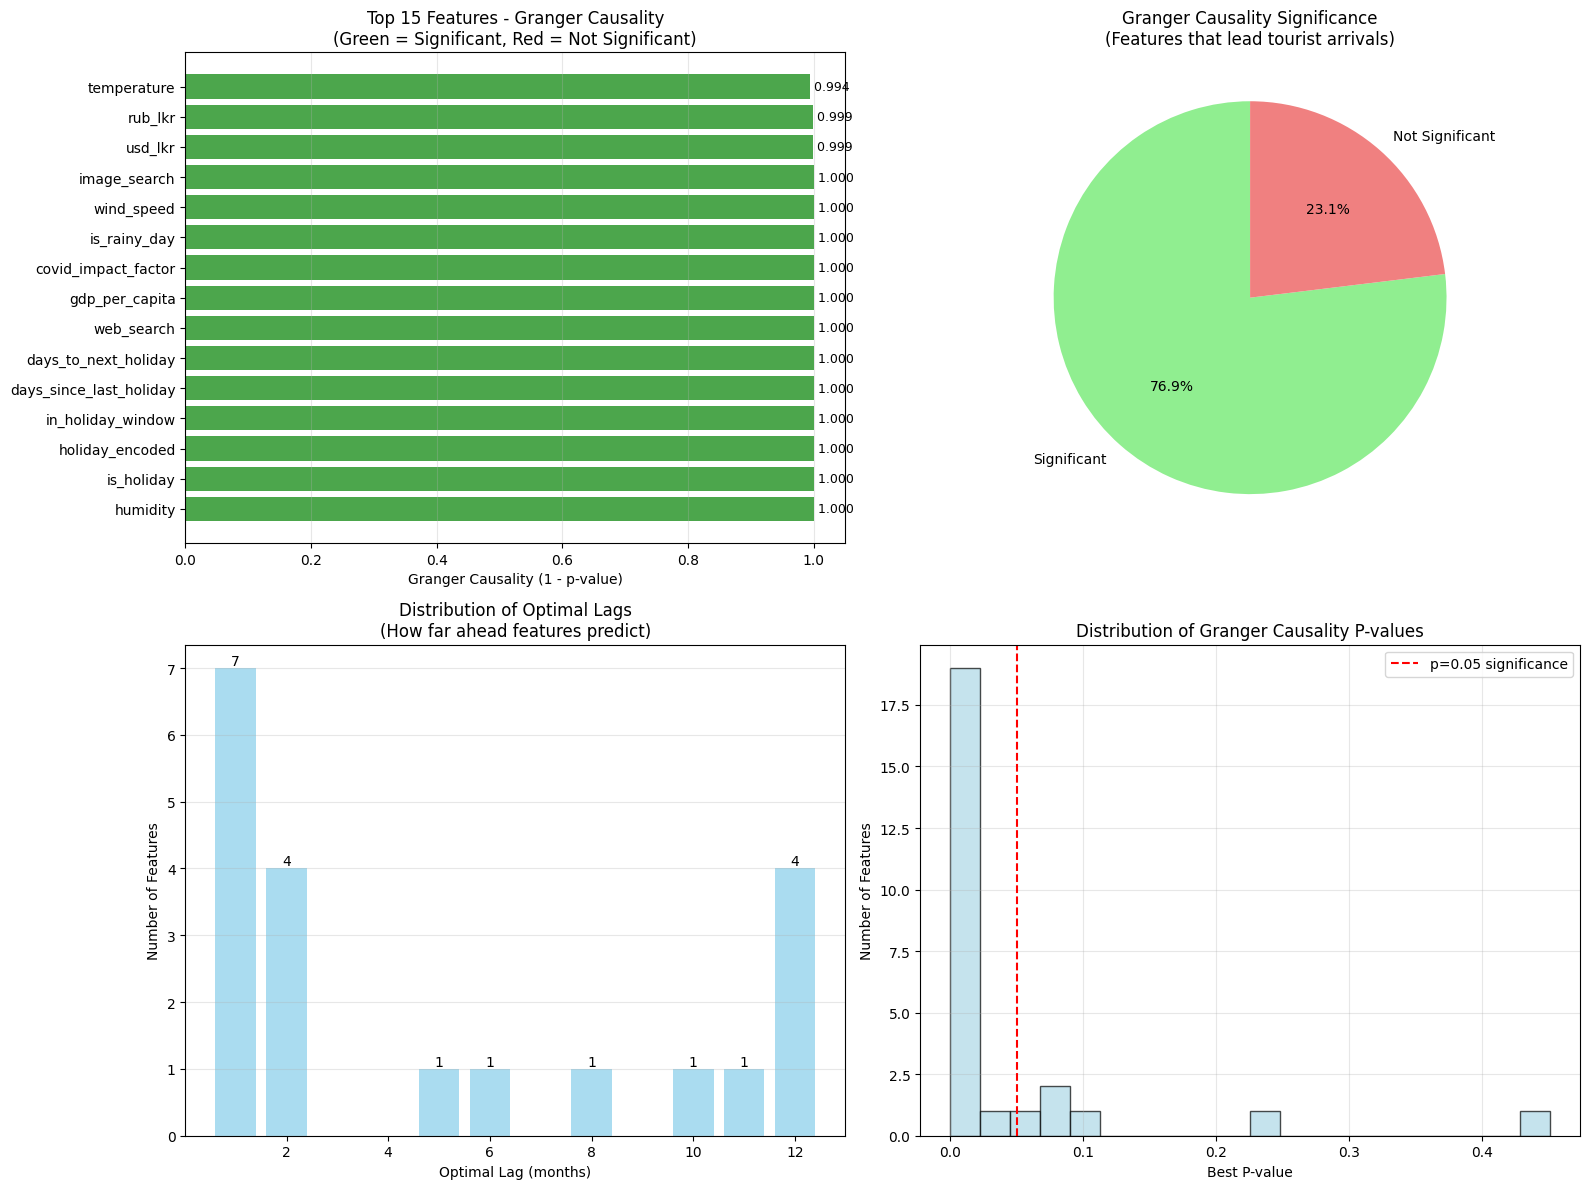

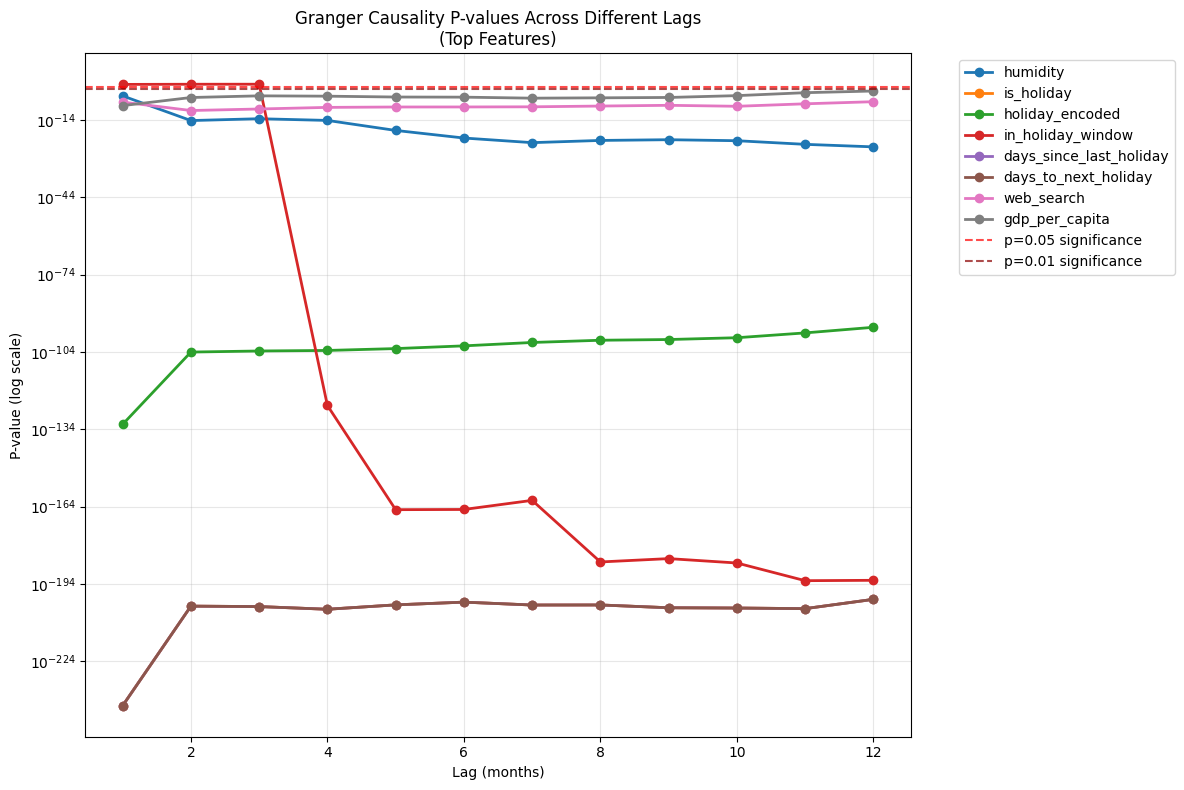


7. FEATURE GROUP ANALYSIS
-------------------------

Granger Causality by Feature Group:
----------------------------------------

ECONOMIC INDICATORS 
  Features:  9 | Significant:  8 (88.9%)
  Avg Causality: 0.9853
  Significant features:
    ✓ gdp_per_capita           : Lag 1 (causality: 1.000, p=0.0000)
    ✓ inflation_rate           : Lag 1 (causality: 0.992, p=0.0080)
    ✓ brent_crude_price        : Lag 8 (causality: 0.993, p=0.0067)
    ✓ usd_lkr                  : Lag 5 (causality: 0.999, p=0.0007)
    ✓ rub_lkr                  : Lag 2 (causality: 0.999, p=0.0011)
    ✓ gbp_lkr                  : Lag 10 (causality: 0.990, p=0.0102)
    ✓ eur_lkr                  : Lag 12 (causality: 0.976, p=0.0244)
    ✓ cny_lkr                  : Lag 6 (causality: 0.988, p=0.0116)

SEARCH TRENDS       
  Features:  3 | Significant:  2 (66.7%)
  Avg Causality: 0.8495
  Significant features:
    ✓ web_search               : Lag 2 (causality: 1.000, p=0.0000)
    ✓ image_search             : 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')


def granger_causality_analysis(df, target_col='arrivals', max_lag=12, significance_level=0.05, figsize=(16, 12)):
    """
    Comprehensive Granger Causality analysis for tourist arrivals prediction

    Parameters:
    df: DataFrame with features and target
    target_col: Name of target variable (must be stationary)
    max_lag: Maximum number of lags to test
    significance_level: Statistical significance level
    figsize: Figure size for plots
    """

    print("=" * 60)
    print("GRANGER CAUSALITY ANALYSIS")
    print("=" * 60)
    print("Tests if past values of a feature help predict future values of tourist arrivals")
    print("Formal time-series causality testing for lead-lag relationships")
    print("=" * 60)

    # ==== FIX: REMOVE TARGET VARIABLES FROM FEATURES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Make a copy and ensure datetime index
    data = features_df.copy()  # Use features_df instead of df
    # Add target column back for analysis
    data[target_col] = df[target_col]

    # 1. Stationarity Check (Crucial for Granger Causality)
    print("\n1. STATIONARITY CHECK")
    print("-" * 25)
    print("Granger causality requires stationary time series")
    print("Testing stationarity using Augmented Dickey-Fuller test...")
    print("NOTE: Target variables (arrivals, arrivals_robust_scaled, outlier_flag) excluded from features")
    print("-" * 80)

    stationarity_results = check_stationarity(data, target_col, significance_level)

    # If target is not stationary, we need to difference it
    if not stationarity_results[target_col]['stationary']:
        print(f"\nWARNING: {target_col} is not stationary. Applying first differences...")
        data = make_data_stationary(data, target_col)
        print("Data has been differenced to achieve stationarity")

    # 2. Prepare Data for Granger Causality
    print("\n2. DATA PREPARATION FOR GRANGER CAUSALITY")
    print("-" * 45)

    # Select features for testing (exclude the target from features list)
    features_to_test = [col for col in features_df.columns if col in data.columns]  # Use features_df columns

    print(f"Target variable: {target_col}")
    print(f"Features to test: {len(features_to_test)}")
    print(f"Maximum lags to test: {max_lag}")
    print(f"Significance level: {significance_level}")

    # 3. Granger Causality Tests
    print("\n3. RUNNING GRANGER CAUSALITY TESTS")
    print("-" * 40)
    print("This may take a while... Testing each feature with multiple lags")

    granger_results = {}
    significant_features = []

    for feature in features_to_test:
        print(f"\nTesting: {feature:25s}", end=" ")

        # Prepare data for this feature-target pair
        test_data = data[[target_col, feature]].dropna()

        if len(test_data) < max_lag * 2:
            print(f"SKIPPED (insufficient data: {len(test_data)} observations)")
            continue

        try:
            # Perform Granger causality test
            gc_test = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)

            # Extract p-values for all lags
            p_values = []
            best_lag = None
            best_p_value = 1.0

            for lag in range(1, max_lag + 1):
                p_value = gc_test[lag][0]['ssr_ftest'][1]
                p_values.append(p_value)

                if p_value < best_p_value:
                    best_p_value = p_value
                    best_lag = lag

            # Check if significant at any lag
            significant_at_any_lag = any(p < significance_level for p in p_values)
            min_p_value = min(p_values)

            granger_results[feature] = {
                'p_values': p_values,
                'best_lag': best_lag,
                'best_p_value': best_p_value,
                'significant': significant_at_any_lag,
                'min_p_value': min_p_value,
                'gc_test': gc_test
            }

            if significant_at_any_lag:
                significant_features.append(feature)
                print(f"✓ SIGNIFICANT (best lag: {best_lag}, p={best_p_value:.4f})")
            else:
                print(f"✗ Not significant (min p={min_p_value:.4f})")

        except Exception as e:
            print(f"ERROR: {str(e)}")
            granger_results[feature] = {
                'p_values': [1.0] * max_lag,
                'best_lag': None,
                'best_p_value': 1.0,
                'significant': False,
                'min_p_value': 1.0,
                'error': str(e)
            }

    # 4. Results Summary
    print("\n4. GRANGER CAUSALITY RESULTS SUMMARY")
    print("-" * 45)

    # Create results dataframe
    results_list = []
    for feature, result in granger_results.items():
        if 'error' in result:
            continue

        results_list.append({
            'feature': feature,
            'significant': result['significant'],
            'best_lag': result['best_lag'],
            'best_p_value': result['best_p_value'],
            'min_p_value': result['min_p_value'],
            'granger_causality': 1 - result['min_p_value']  # Convert to importance score
        })

    granger_df = pd.DataFrame(results_list)
    granger_df = granger_df.sort_values('granger_causality', ascending=False)
    granger_df['rank'] = range(1, len(granger_df) + 1)
    granger_df.set_index('feature', inplace=True)

    print(f"\nSignificant Granger-causal features: {len(significant_features)}/{len(features_to_test)}")
    print(f"Features that lead tourist arrivals (predictive power):")
    print("-" * 60)

    significant_granger = granger_df[granger_df['significant'] == True]
    if len(significant_granger) > 0:
        for i, (feature, row) in enumerate(significant_granger.iterrows(), 1):
            stars = "***" if row['best_p_value'] < 0.001 else "**" if row['best_p_value'] < 0.01 else "*"
            print(f"{i:2d}. {feature:25s}: Lag {row['best_lag']:2d} (p={row['best_p_value']:.4f}) {stars}")
    else:
        print("No significant Granger-causal relationships found.")

    # 5. Lag Analysis
    print("\n5. LAG ANALYSIS")
    print("-" * 20)

    lag_analysis = analyze_optimal_lags(granger_results, significant_features)

    # 6. Visualization
    print("\n6. VISUALIZATION")
    print("-" * 15)

    create_granger_visualizations(granger_df, granger_results, max_lag, figsize)

    # 7. Feature Groups Analysis
    print("\n7. FEATURE GROUP ANALYSIS")
    print("-" * 25)

    group_analysis = analyze_granger_feature_groups(granger_df, significant_features)

    # 8. Lead-Lag Relationship Analysis
    print("\n8. LEAD-LAG RELATIONSHIP INTERPRETATION")
    print("-" * 45)

    lead_lag_analysis = interpret_lead_lag_relationships(granger_df, data, target_col)

    # 9. Return comprehensive results
    results = {
        'granger_causality': granger_df['granger_causality'],
        'best_lags': granger_df['best_lag'],
        'p_values': granger_df['best_p_value'],
        'granger_ranking': granger_df,
        'significant_features': significant_features,
        'stationarity_check': stationarity_results,
        'lag_analysis': lag_analysis,
        'group_analysis': group_analysis,
        'lead_lag_analysis': lead_lag_analysis,
        'all_granger_results': granger_results
    }

    return results

def check_stationarity(data, target_col, significance_level=0.05):
    """
    Check stationarity of all time series using Augmented Dickey-Fuller test
    """
    stationarity_results = {}

    print("\nAugmented Dickey-Fuller Test Results:")
    print("H₀: Series has unit root (non-stationary)")
    print("H₁: Series is stationary")
    print("-" * 70)

    for column in data.columns:
        series = data[column].dropna()

        if len(series) < 10:  # Too short for reliable test
            stationarity_results[column] = {'stationary': False, 'p_value': 1.0, 'reason': 'Insufficient data'}
            continue

        try:
            adf_result = adfuller(series, autolag='AIC')
            p_value = adf_result[1]
            is_stationary = p_value < significance_level

            stationarity_results[column] = {
                'stationary': is_stationary,
                'p_value': p_value,
                'test_statistic': adf_result[0],
                'critical_values': adf_result[4]
            }

            status = "STATIONARY" if is_stationary else "NON-STATIONARY"
            print(f"{column:25s}: p={p_value:.4f} ({status})")

        except Exception as e:
            stationarity_results[column] = {'stationary': False, 'p_value': 1.0, 'error': str(e)}
            print(f"{column:25s}: ERROR - {str(e)}")

    return stationarity_results

def make_data_stationary(data, target_col):
    """
    Make time series stationary by applying first differences
    """
    stationary_data = data.copy()

    for column in stationary_data.columns:
        # Skip if already stationary or binary/categorical
        if column in ['is_holiday', 'is_tourist_event', 'in_holiday_window','is_rainy_day']:
            continue

        # Apply first differences
        stationary_data[column] = stationary_data[column].diff()

    # Drop first row with NaN values from differencing
    stationary_data = stationary_data.dropna()

    return stationary_data

def analyze_optimal_lags(granger_results, significant_features):
    """
    Analyze optimal lags for significant features
    """
    print("\nOptimal Lag Analysis for Significant Features:")
    print("(Shows how far in advance each feature predicts arrivals)")
    print("-" * 70)

    lag_distribution = {}

    for feature in significant_features:
        if feature in granger_results:
            best_lag = granger_results[feature]['best_lag']
            if best_lag not in lag_distribution:
                lag_distribution[best_lag] = []
            lag_distribution[best_lag].append(feature)

    # Print lag distribution
    for lag in sorted(lag_distribution.keys()):
        features = lag_distribution[lag]
        print(f"Lag {lag:2d} month(s): {len(features):2d} features")
        for feature in features:
            p_value = granger_results[feature]['best_p_value']
            print(f"     - {feature:25s} (p={p_value:.4f})")

    return lag_distribution

def create_granger_visualizations(granger_df, granger_results, max_lag, figsize):
    """
    Create comprehensive visualizations for Granger causality results
    """
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # Plot 1: Granger Causality Importance (Top 15)
    top_15 = granger_df.head(15)
    colors = ['green' if row['significant'] else 'red' for _, row in top_15.iterrows()]

    bars = axes[0, 0].barh(range(len(top_15)), top_15['granger_causality'], color=colors, alpha=0.7)
    axes[0, 0].set_yticks(range(len(top_15)))
    axes[0, 0].set_yticklabels(top_15.index)
    axes[0, 0].set_xlabel('Granger Causality (1 - p-value)')
    axes[0, 0].set_title('Top 15 Features - Granger Causality\n(Green = Significant, Red = Not Significant)')
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Add value annotations
    for i, (causality, feature) in enumerate(zip(top_15['granger_causality'], top_15.index)):
        axes[0, 0].text(causality, i, f' {causality:.3f}', va='center', fontsize=9)

    # Plot 2: Significance Summary
    significant_count = len(granger_df[granger_df['significant'] == True])
    non_significant_count = len(granger_df[granger_df['significant'] == False])

    axes[0, 1].pie([significant_count, non_significant_count],
                   labels=['Significant', 'Not Significant'],
                   colors=['lightgreen', 'lightcoral'],
                   autopct='%1.1f%%', startangle=90)
    axes[0, 1].set_title('Granger Causality Significance\n(Features that lead tourist arrivals)')

    # Plot 3: Optimal Lags Distribution
    if significant_count > 0:
        significant_df = granger_df[granger_df['significant'] == True]
        lag_counts = significant_df['best_lag'].value_counts().sort_index()

        axes[1, 0].bar(lag_counts.index, lag_counts.values, color='skyblue', alpha=0.7)
        axes[1, 0].set_xlabel('Optimal Lag (months)')
        axes[1, 0].set_ylabel('Number of Features')
        axes[1, 0].set_title('Distribution of Optimal Lags\n(How far ahead features predict)')
        axes[1, 0].grid(axis='y', alpha=0.3)

        # Add count annotations
        for lag, count in lag_counts.items():
            axes[1, 0].text(lag, count, f'{count}', ha='center', va='bottom')

    # Plot 4: P-value Distribution
    p_values = granger_df['best_p_value']
    axes[1, 1].hist(p_values, bins=20, color='lightblue', alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(x=0.05, color='red', linestyle='--', label='p=0.05 significance')
    axes[1, 1].set_xlabel('Best P-value')
    axes[1, 1].set_ylabel('Number of Features')
    axes[1, 1].set_title('Distribution of Granger Causality P-values')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Additional plot: P-values across lags for top features
    if len(granger_results) > 0:
        plot_pvalues_across_lags(granger_results, granger_df.head(8).index.tolist(), max_lag)

def plot_pvalues_across_lags(granger_results, top_features, max_lag):
    """
    Plot p-values across different lags for top features
    """
    plt.figure(figsize=(12, 8))

    for feature in top_features:
        if feature in granger_results:
            p_values = granger_results[feature]['p_values']
            lags = range(1, len(p_values) + 1)
            plt.semilogy(lags, p_values, 'o-', label=feature, linewidth=2, markersize=6)

    plt.axhline(y=0.05, color='red', linestyle='--', label='p=0.05 significance', alpha=0.7)
    plt.axhline(y=0.01, color='darkred', linestyle='--', label='p=0.01 significance', alpha=0.7)
    plt.xlabel('Lag (months)')
    plt.ylabel('P-value (log scale)')
    plt.title('Granger Causality P-values Across Different Lags\n(Top Features)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def analyze_granger_feature_groups(granger_df, significant_features):
    """
    Analyze Granger causality by feature groups
    """
    # Define feature groups
    feature_groups = {
        'Economic Indicators': ['gdp_per_capita', 'inflation_rate', 'brent_crude_price',
                               'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr'],
        'Search Trends': ['web_search', 'youtube_search', 'image_search'],
        'Weather Conditions': ['temperature', 'precipitation', 'humidity', 'wind_speed','is_rainy_day'],
        'Temporal Features': ['is_holiday', 'is_tourist_event', 'event_encoded',
                             'days_to_next_holiday', 'days_since_last_holiday',
                             'in_holiday_window', 'holiday_encoded'],
        'Impact Factors': ['covid_impact_factor', 'crisis_impact_factor']
    }

    group_summary = {}

    print("\nGranger Causality by Feature Group:")
    print("-" * 40)

    for group_name, features in feature_groups.items():
        # Get features that exist in results
        existing_features = [f for f in features if f in granger_df.index]
        if not existing_features:
            continue

        group_results = granger_df.loc[existing_features]
        significant_in_group = [f for f in existing_features if f in significant_features]

        group_summary[group_name] = {
            'total_features': len(existing_features),
            'significant_features': len(significant_in_group),
            'significance_rate': len(significant_in_group) / len(existing_features),
            'avg_granger_causality': group_results['granger_causality'].mean(),
            'top_feature': group_results['granger_causality'].idxmax(),
            'top_causality': group_results['granger_causality'].max()
        }

        print(f"\n{group_name.upper():20s}")
        print(f"  Features: {len(existing_features):2d} | Significant: {len(significant_in_group):2d} ({group_summary[group_name]['significance_rate']:.1%})")
        print(f"  Avg Causality: {group_results['granger_causality'].mean():.4f}")

        if significant_in_group:
            print(f"  Significant features:")
            for feature in significant_in_group:
                causality = granger_df.loc[feature, 'granger_causality']
                best_lag = granger_df.loc[feature, 'best_lag']
                p_value = granger_df.loc[feature, 'best_p_value']
                print(f"    ✓ {feature:25s}: Lag {best_lag} (causality: {causality:.3f}, p={p_value:.4f})")

    return group_summary

def interpret_lead_lag_relationships(granger_df, data, target_col):
    """
    Provide practical interpretation of lead-lag relationships
    """
    print("\nPractical Interpretation of Lead-Lag Relationships:")
    print("=" * 60)

    significant_df = granger_df[granger_df['significant'] == True]

    if len(significant_df) == 0:
        print("No significant lead-lag relationships found.")
        return {}

    print("\nFeatures that PREDICT future tourist arrivals:")
    print("(Useful for early warning systems and proactive planning)")
    print("-" * 70)

    interpretation = {}

    for feature, row in significant_df.iterrows():
        lag = row['best_lag']
        causality = row['granger_causality']

        # Provide practical interpretation based on lag
        if lag == 1:
            timing = "next month"
        elif lag <= 3:
            timing = f"next {lag} months"
        elif lag <= 6:
            timing = f"next {lag} months (medium-term)"
        else:
            timing = f"next {lag} months (long-term)"

        interpretation[feature] = {
            'lag': lag,
            'timing_interpretation': timing,
            'causality_strength': causality,
            'practical_use': f"Monitor {feature} to predict arrivals {timing} in advance"
        }

        print(f"• {feature:25s}: Leads by {lag:2d} month(s) - predicts arrivals {timing}")
        print(f"  Strength: {causality:.3f} | Practical use: {interpretation[feature]['practical_use']}")

    return interpretation

# Additional function for VAR model validation
def var_model_validation(df, target_col, significant_features, max_lags=8):
    """
    Validate Granger causality results using VAR model
    """
    print("\n" + "="*50)
    print("VAR MODEL VALIDATION")
    print("="*50)

    if len(significant_features) < 2:
        print("Insufficient significant features for VAR model.")
        return None

    # ==== FIX: REMOVE TARGET VARIABLES ====
    target_variables = ['arrivals', 'arrivals_robust_scaled', 'outlier_flag']
    features_df = df.drop(columns=target_variables)

    # Select significant features and target
    var_data = features_df[significant_features].copy()
    var_data[target_col] = df[target_col]
    var_data = var_data.dropna()

    if len(var_data) < max_lags * 2:
        print("Insufficient data for VAR model.")
        return None

    try:
        # Fit VAR model
        model = VAR(var_data)
        var_result = model.fit(maxlags=max_lags, ic='aic')

        print(f"VAR Model fitted with {var_result.k_ar} lags")
        print(f"AIC: {var_result.aic:.2f}")
        print(f"BIC: {var_result.bic:.2f}")

        # Test Granger causality within VAR framework
        print("\nGranger Causality within VAR framework:")
        gc_results = var_result.test_causality(target_col, significant_features, kind='f')
        print(f"Joint Granger causality test: p-value = {gc_results.pvalue:.4f}")

        if gc_results.pvalue < 0.05:
            print("✓ SIGNIFICANT: Features jointly Granger-cause tourist arrivals")
        else:
            print("✗ NOT SIGNIFICANT: Features do not jointly Granger-cause arrivals")

        return var_result

    except Exception as e:
        print(f"VAR model error: {str(e)}")
        return None

# Usage example:
if __name__ == "__main__":
    # Load your preprocessed data
    # df = pd.read_csv('your_preprocessed_tourism_data.csv')

    # Run Granger Causality analysis
    granger_results = granger_causality_analysis(df, 'arrivals', max_lag=12)

    # Optional: VAR model validation
    if len(granger_results['significant_features']) >= 2:
        var_model = var_model_validation(df, 'arrivals', granger_results['significant_features'])

    # Save results for consensus integration
    granger_results['granger_ranking'].to_csv('granger_causality_results.csv')

    print("\n" + "="*60)
    print("GRANGER CAUSALITY ANALYSIS COMPLETED")
    print("="*60)
    print("\nKey insights:")
    print("- Identified features that lead tourist arrivals (predictive power)")
    print("- Optimal lag periods for each predictive feature")
    print("- Statistical significance of lead-lag relationships")
    print("- Results saved for consensus integration")

## Consensus integration


CONSENSUS FEATURE IMPORTANCE INTEGRATION
Combining 7 complementary methods for robust feature selection

1. METHOD WEIGHT CONFIGURATION
-----------------------------------
Method Weights (based on reliability and relevance for tourism forecasting):
  correlation         : 0.08 (8.0%)
  mutual_information  : 0.12 (12.0%)
  lasso               : 0.10 (10.0%)
  random_forest       : 0.15 (15.0%)
  permutation         : 0.20 (20.0%)
  shap                : 0.25 (25.0%)
  granger             : 0.10 (10.0%)

2. EXTRACTING AND NORMALIZING METHOD SCORES
---------------------------------------------
Total unique features across all methods: 26

3. CALCULATING WEIGHTED CONSENSUS SCORES
---------------------------------------------

4. CREATING CONSENSUS RANKING
------------------------------

5. CALCULATING FEATURE CONSISTENCY METRICS
---------------------------------------------

6. TOP CONSENSUS FEATURES
-------------------------
Features ranked by weighted consensus across all 7 methods
-----

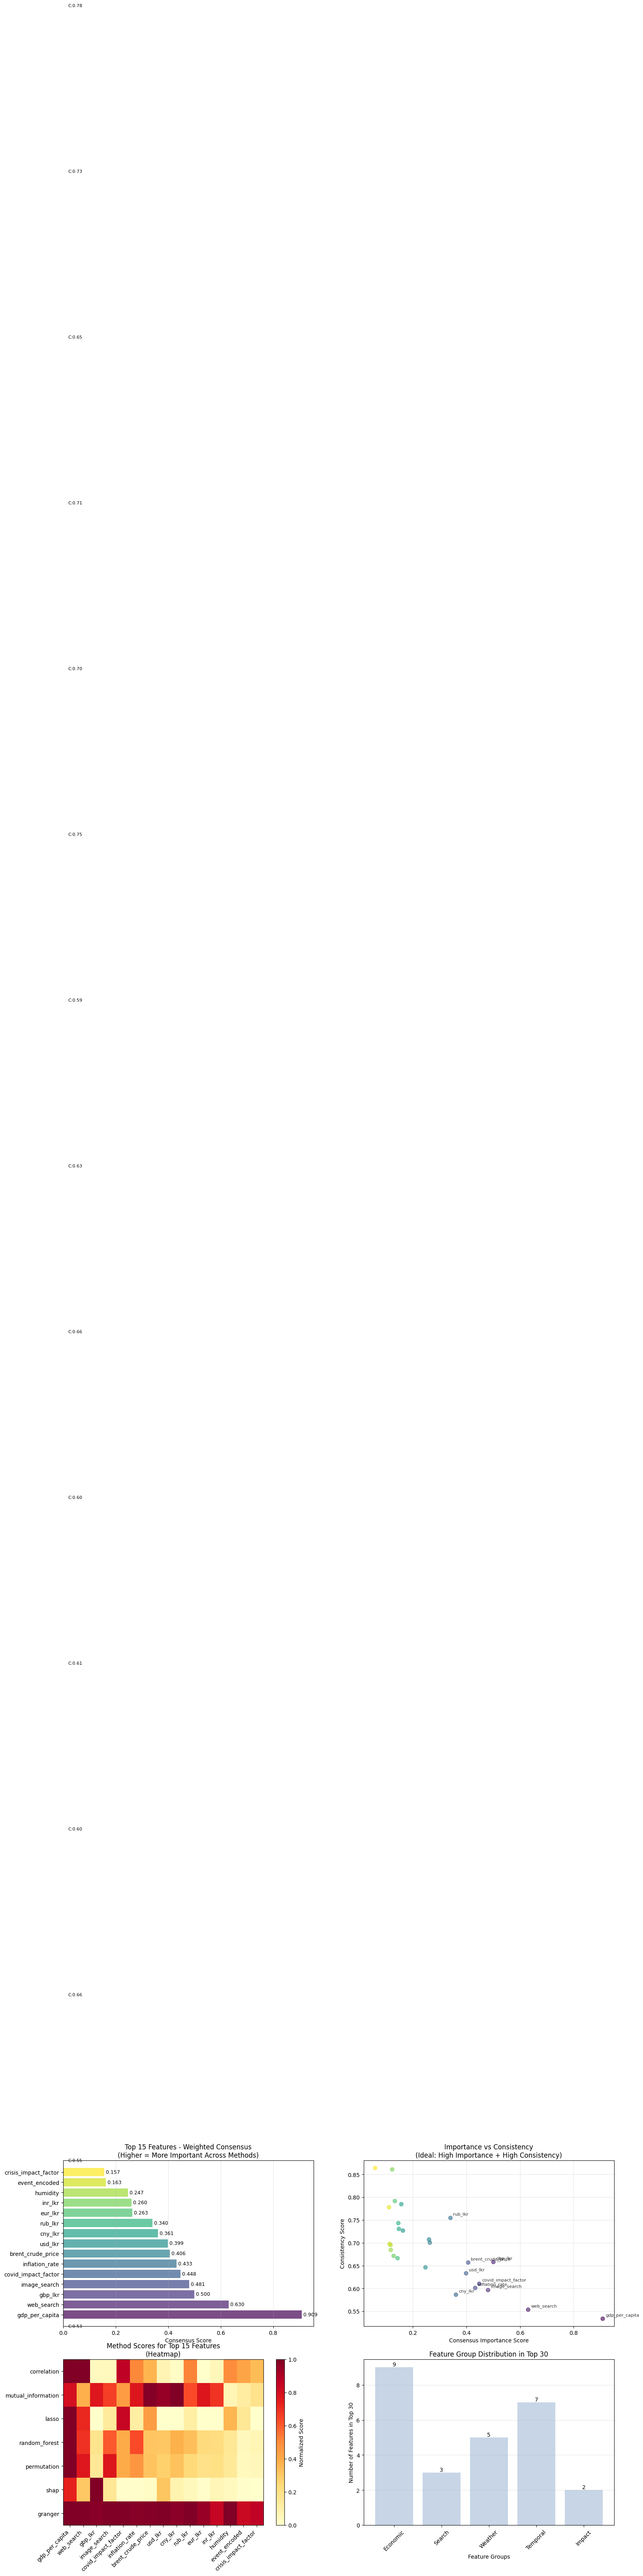

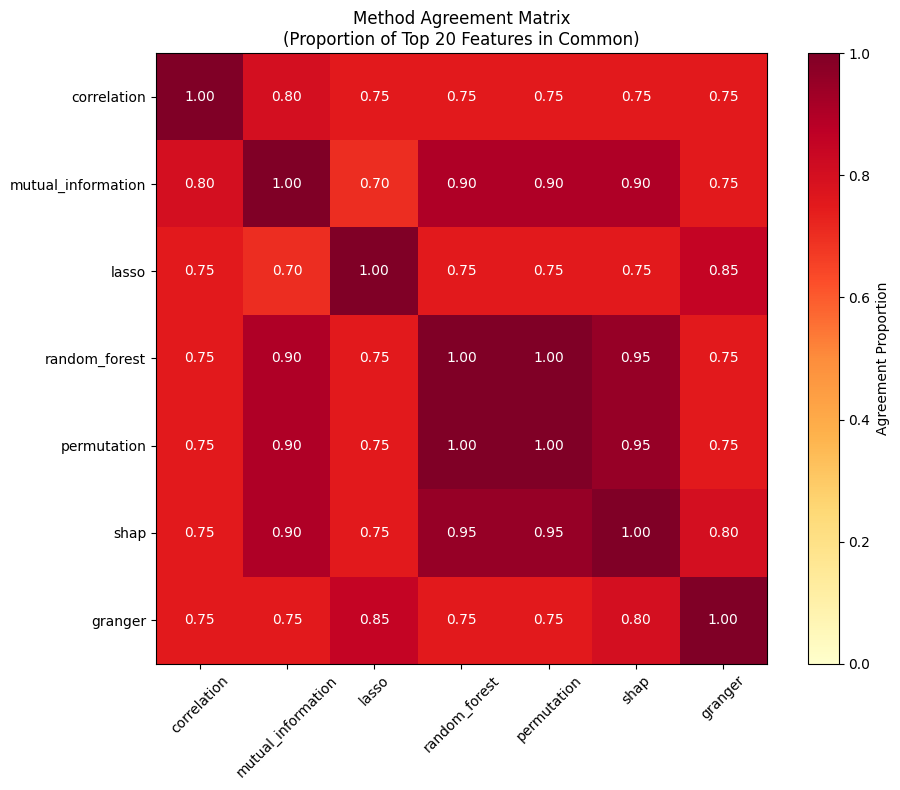


8. FEATURE GROUP CONSENSUS ANALYSIS
----------------------------------------

Consensus Ranking by Feature Group:
----------------------------------------

ECONOMIC       
  Features:  9 | Avg Consensus: 0.430
  Top feature: gdp_per_capita            (score: 0.909)
      1. gdp_per_capita           : 0.909 (C: 0.53)
      6. inflation_rate           : 0.433 (C: 0.60)
      7. brent_crude_price        : 0.406 (C: 0.66)
      8. usd_lkr                  : 0.399 (C: 0.63)
     10. rub_lkr                  : 0.340 (C: 0.75)
     12. inr_lkr                  : 0.260 (C: 0.71)
      3. gbp_lkr                  : 0.500 (C: 0.66)
     11. eur_lkr                  : 0.263 (C: 0.70)
      9. cny_lkr                  : 0.361 (C: 0.59)

SEARCH         
  Features:  3 | Avg Consensus: 0.407
  Top feature: web_search                (score: 0.630)
      2. web_search               : 0.630 (C: 0.55)
     25. youtube_search           : 0.111 (C: 0.78)
      4. image_search             : 0.481 (C: 0.60

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata, gmean
import warnings
warnings.filterwarnings('ignore')

def consensus_integration(correlation_results, mi_results, lasso_results, rf_results, perm_results, shap_results, granger_results, method_weights=None):
    """
    Integrate results from all 7 feature importance methods into a consensus ranking

    Parameters:
    results from all individual methods
    method_weights: Optional custom weights for each method
    """

    print("=" * 80)
    print("CONSENSUS FEATURE IMPORTANCE INTEGRATION")
    print("=" * 80)
    print("Combining 7 complementary methods for robust feature selection")
    print("=" * 80)

    # 1. Prepare Method Weights
    print("\n1. METHOD WEIGHT CONFIGURATION")
    print("-" * 35)

    if method_weights is None:
        # Default weights based on methodological strengths
        method_weights = {
            'correlation': 0.08,      # Simple linear relationships
            'mutual_information': 0.12, # Any relationship type
            'lasso': 0.10,            # Sparse selection, handles multicollinearity
            'random_forest': 0.15,     # Non-linear, robust
            'permutation': 0.20,       # True predictive importance, model-agnostic
            'shap': 0.25,              # Game-theoretic, exact attribution
            'granger': 0.10            # Time-series causality
        }

    # Validate weights sum to 1
    total_weight = sum(method_weights.values())
    if abs(total_weight - 1.0) > 0.01:
        # Normalize weights
        method_weights = {k: v/total_weight for k, v in method_weights.items()}

    print("Method Weights (based on reliability and relevance for tourism forecasting):")
    for method, weight in method_weights.items():
        print(f"  {method:20s}: {weight:.2f} ({weight*100:.1f}%)")

    # 2. Extract and Normalize Scores from Each Method
    print("\n2. EXTRACTING AND NORMALIZING METHOD SCORES")
    print("-" * 45)

    all_scores = {}
    feature_universe = set()

    # Extract scores from each method
    methods_data = {
        'correlation': extract_correlation_scores(correlation_results),
        'mutual_information': extract_mi_scores(mi_results),
        'lasso': extract_lasso_scores(lasso_results),
        'random_forest': extract_rf_scores(rf_results),
        'permutation': extract_permutation_scores(perm_results),
        'shap': extract_shap_scores(shap_results),
        'granger': extract_granger_scores(granger_results)
    }

    # Build feature universe
    for method_name, method_scores in methods_data.items():
        feature_universe.update(method_scores.keys())

    print(f"Total unique features across all methods: {len(feature_universe)}")

    # 3. Normalize Scores and Calculate Weighted Consensus
    print("\n3. CALCULATING WEIGHTED CONSENSUS SCORES")
    print("-" * 45)

    consensus_scores = {}
    method_details = {}

    for feature in feature_universe:
        feature_scores = {}
        weighted_score = 0
        methods_used = 0

        for method_name, method_scores in methods_data.items():
            if feature in method_scores:
                score = method_scores[feature]
                feature_scores[method_name] = score
                weighted_score += score * method_weights[method_name]
                methods_used += 1
            else:
                feature_scores[method_name] = np.nan

        # Store results
        consensus_scores[feature] = weighted_score
        method_details[feature] = feature_scores

    # 4. Create Comprehensive Results DataFrame
    print("\n4. CREATING CONSENSUS RANKING")
    print("-" * 30)

    consensus_df = pd.DataFrame.from_dict(consensus_scores, orient='index', columns=['consensus_score'])
    consensus_df = consensus_df.sort_values('consensus_score', ascending=False)

    # Add method-specific scores
    for method_name in method_weights.keys():
        method_scores = [method_details[feature].get(method_name, np.nan)
                        for feature in consensus_df.index]
        consensus_df[f'{method_name}_score'] = method_scores

    # Add ranks for each method
    for method_name in method_weights.keys():
        valid_scores = consensus_df[f'{method_name}_score'].dropna()
        if len(valid_scores) > 0:
            ranks = rankdata(-valid_scores, method='min')  # Lower rank = better
            consensus_df[f'{method_name}_rank'] = np.nan
            consensus_df.loc[valid_scores.index, f'{method_name}_rank'] = ranks

    # Calculate consensus rank
    consensus_df['consensus_rank'] = range(1, len(consensus_df) + 1)

    # 5. Calculate Consistency Metrics
    print("\n5. CALCULATING FEATURE CONSISTENCY METRICS")
    print("-" * 45)

    consensus_df = calculate_consistency_metrics(consensus_df, method_weights)

    # 6. Display Top Consensus Features
    print("\n6. TOP CONSENSUS FEATURES")
    print("-" * 25)
    print("Features ranked by weighted consensus across all 7 methods")
    print("-" * 80)

    top_consensus = consensus_df.head(20)
    for i, (feature, row) in enumerate(top_consensus.iterrows(), 1):
        consistency = row['consistency_score']
        methods_count = row['methods_agreeing']

        consistency_stars = ""
        if consistency >= 0.8:
            consistency_stars = "★★★★★"
        elif consistency >= 0.6:
            consistency_stars = "★★★★"
        elif consistency >= 0.4:
            consistency_stars = "★★★"
        elif consistency >= 0.2:
            consistency_stars = "★★"
        else:
            consistency_stars = "★"

        print(f"{i:2d}. {feature:25s}: {row['consensus_score']:.4f} {consistency_stars}")
        print(f"     Consistency: {consistency:.1%} | Methods agreeing: {methods_count}/7")

        # Show top 3 method contributions
        top_methods = []
        for method in method_weights.keys():
            if pd.notna(row[f'{method}_score']):
                top_methods.append((method, row[f'{method}_score']))

        top_methods.sort(key=lambda x: x[1], reverse=True)
        method_str = " | ".join([f"{m}:{s:.3f}" for m, s in top_methods[:3]])
        print(f"     Top methods: {method_str}")

    # 7. Visualization
    print("\n7. CONSENSUS VISUALIZATION")
    print("-" * 25)

    create_consensus_visualizations(consensus_df, method_weights, top_n=15)

    # 8. Feature Groups Consensus Analysis
    print("\n8. FEATURE GROUP CONSENSUS ANALYSIS")
    print("-" * 40)

    group_consensus = analyze_consensus_by_groups(consensus_df)

    # 9. Method Agreement Analysis
    print("\n9. METHOD AGREEMENT ANALYSIS")
    print("-" * 30)

    agreement_analysis = analyze_method_agreement(consensus_df, method_weights)

    # 10. Final Feature Selection Recommendations
    print("\n10. FEATURE SELECTION RECOMMENDATIONS")
    print("-" * 40)

    recommendations = generate_feature_recommendations(consensus_df, group_consensus)

    # 11. Return Comprehensive Results
    results = {
        'consensus_ranking': consensus_df,
        'method_weights': method_weights,
        'consensus_scores': consensus_df['consensus_score'],
        'consistency_scores': consensus_df['consistency_score'],
        'group_analysis': group_consensus,
        'agreement_analysis': agreement_analysis,
        'recommendations': recommendations,
        'method_details': method_details
    }

    return results

def extract_correlation_scores(correlation_results):
    """Extract and normalize correlation scores"""
    # Use absolute Pearson correlation
    if 'pearson_correlations' in correlation_results:
        corr_scores = correlation_results['pearson_correlations']['correlation'].abs()
    else:
        corr_scores = pd.Series()

    # Normalize to 0-1 range
    if len(corr_scores) > 0:
        corr_scores = (corr_scores - corr_scores.min()) / (corr_scores.max() - corr_scores.min())

    return corr_scores

def extract_mi_scores(mi_results):
    """Extract and normalize mutual information scores"""
    if 'mi_scores' in mi_results:
        mi_scores = mi_results['mi_scores']
    else:
        mi_scores = pd.Series()

    # Normalize to 0-1 range
    if len(mi_scores) > 0:
        mi_scores = (mi_scores - mi_scores.min()) / (mi_scores.max() - mi_scores.min())

    return mi_scores

def extract_lasso_scores(lasso_results):
    """Extract and normalize lasso coefficients"""
    if 'feature_importance' in lasso_results:
        lasso_scores = lasso_results['feature_importance']  # Already absolute coefficients
    else:
        lasso_scores = pd.Series()

    # Normalize to 0-1 range
    if len(lasso_scores) > 0:
        lasso_scores = (lasso_scores - lasso_scores.min()) / (lasso_scores.max() - lasso_scores.min())

    return lasso_scores

def extract_rf_scores(rf_results):
    """Extract and normalize random forest importance"""
    if 'feature_importance' in rf_results:
        rf_scores = rf_results['feature_importance']
    else:
        rf_scores = pd.Series()

    # Normalize to 0-1 range
    if len(rf_scores) > 0:
        rf_scores = (rf_scores - rf_scores.min()) / (rf_scores.max() - rf_scores.min())

    return rf_scores

def extract_permutation_scores(perm_results):
    """Extract and normalize permutation importance"""
    if 'permutation_importance' in perm_results:
        perm_scores = perm_results['permutation_importance']
    else:
        perm_scores = pd.Series()

    # Handle negative values (set to 0) and normalize
    if len(perm_scores) > 0:
        perm_scores = np.maximum(perm_scores, 0)  # Set negatives to 0
        if perm_scores.max() > 0:
            perm_scores = perm_scores / perm_scores.max()

    return perm_scores

def extract_shap_scores(shap_results):
    """Extract and normalize SHAP values"""
    if 'shap_importance' in shap_results:
        shap_scores = shap_results['shap_importance']
    else:
        shap_scores = pd.Series()

    # Normalize to 0-1 range
    if len(shap_scores) > 0:
        shap_scores = (shap_scores - shap_scores.min()) / (shap_scores.max() - shap_scores.min())

    return shap_scores

def extract_granger_scores(granger_results):
    """Extract and normalize Granger causality scores"""
    if 'granger_causality' in granger_results:
        granger_scores = granger_results['granger_causality']
    else:
        granger_scores = pd.Series()

    # Normalize to 0-1 range
    if len(granger_scores) > 0:
        granger_scores = (granger_scores - granger_scores.min()) / (granger_scores.max() - granger_scores.min())

    return granger_scores

def calculate_consistency_metrics(consensus_df, method_weights):
    """Calculate consistency metrics across methods"""

    method_columns = [f'{method}_rank' for method in method_weights.keys()]
    available_rank_columns = [col for col in method_columns if col in consensus_df.columns]

    # Calculate consistency score (how much methods agree on feature importance)
    consistency_scores = []
    methods_agreeing = []

    for idx, row in consensus_df.iterrows():
        valid_ranks = [row[col] for col in available_rank_columns if pd.notna(row[col])]

        if len(valid_ranks) >= 2:
            # Consistency: inverse of coefficient of variation of ranks
            mean_rank = np.mean(valid_ranks)
            std_rank = np.std(valid_ranks)
            if mean_rank > 0:
                cv = std_rank / mean_rank
                consistency = 1 / (1 + cv)  # Convert to 0-1 scale (higher = more consistent)
            else:
                consistency = 1.0
        else:
            consistency = 0.0

        consistency_scores.append(consistency)
        methods_agreeing.append(len(valid_ranks))

    consensus_df['consistency_score'] = consistency_scores
    consensus_df['methods_agreeing'] = methods_agreeing

    # Calculate rank stability (how stable is the feature across methods)
    rank_std = []
    for idx, row in consensus_df.iterrows():
        valid_ranks = [row[col] for col in available_rank_columns if pd.notna(row[col])]
        if len(valid_ranks) >= 2:
            rank_std.append(np.std(valid_ranks))
        else:
            rank_std.append(np.nan)

    consensus_df['rank_std'] = rank_std

    return consensus_df

def create_consensus_visualizations(consensus_df, method_weights, top_n=15):
    """Create comprehensive visualizations for consensus results"""

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # Plot 1: Top Consensus Features
    top_features = consensus_df.head(top_n)

    colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
    bars = axes[0, 0].barh(range(len(top_features)), top_features['consensus_score'],
                          color=colors, alpha=0.7)
    axes[0, 0].set_yticks(range(len(top_features)))
    axes[0, 0].set_yticklabels(top_features.index)
    axes[0, 0].set_xlabel('Consensus Score')
    axes[0, 0].set_title(f'Top {top_n} Features - Weighted Consensus\n(Higher = More Important Across Methods)')
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Add consistency as error bars or text
    for i, (feature, row) in enumerate(top_features.iterrows()):
        axes[0, 0].text(row['consensus_score'], i, f' {row["consensus_score"]:.3f}',
                       va='center', fontsize=9)
        axes[0, 0].text(0.02, i, f'C:{row["consistency_score"]:.2f}',
                       va='center', fontsize=8, transform=axes[0, 0].transAxes)

    # Plot 2: Consistency vs Importance
    scatter_features = consensus_df.head(30)
    scatter = axes[0, 1].scatter(scatter_features['consensus_score'],
                                scatter_features['consistency_score'],
                                s=50, alpha=0.6, c=range(len(scatter_features)),
                                cmap='viridis')

    # Add labels for top features
    for i, (feature, row) in enumerate(scatter_features.iterrows()):
        if i < 10:  # Label only top 10
            axes[0, 1].annotate(feature, (row['consensus_score'], row['consistency_score']),
                               xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

    axes[0, 1].set_xlabel('Consensus Importance Score')
    axes[0, 1].set_ylabel('Consistency Score')
    axes[0, 1].set_title('Importance vs Consistency\n(Ideal: High Importance + High Consistency)')
    axes[0, 1].grid(alpha=0.3)

    # Plot 3: Method Contribution Heatmap
    method_columns = [f'{method}_score' for method in method_weights.keys()]
    available_method_cols = [col for col in method_columns if col in consensus_df.columns]

    if available_method_cols:
        top_15_method_scores = consensus_df.head(15)[available_method_cols]
        # Rename columns for better readability
        top_15_method_scores.columns = [col.replace('_score', '') for col in available_method_cols]

        im = axes[1, 0].imshow(top_15_method_scores.T, cmap='YlOrRd', aspect='auto')
        axes[1, 0].set_xticks(range(len(top_15_method_scores)))
        axes[1, 0].set_xticklabels(top_15_method_scores.index, rotation=45, ha='right')
        axes[1, 0].set_yticks(range(len(available_method_cols)))
        axes[1, 0].set_yticklabels([col.replace('_score', '') for col in available_method_cols])
        axes[1, 0].set_title('Method Scores for Top 15 Features\n(Heatmap)')
        plt.colorbar(im, ax=axes[1, 0], label='Normalized Score')

    # Plot 4: Feature Groups Distribution
    group_analysis = analyze_consensus_by_groups(consensus_df.head(30))
    if group_analysis:
        groups = list(group_analysis.keys())
        counts = [group_analysis[group]['count'] for group in groups]

        axes[1, 1].bar(groups, counts, color='lightsteelblue', alpha=0.7)
        axes[1, 1].set_xlabel('Feature Groups')
        axes[1, 1].set_ylabel('Number of Features in Top 30')
        axes[1, 1].set_title('Feature Group Distribution in Top 30')
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(axis='y', alpha=0.3)

        # Add count labels
        for i, count in enumerate(counts):
            axes[1, 1].text(i, count, str(count), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # Additional: Method Agreement Matrix
    plot_method_agreement_matrix(consensus_df, method_weights)

def plot_method_agreement_matrix(consensus_df, method_weights):
    """Plot method agreement matrix (how often methods agree on top features)"""

    method_columns = [f'{method}_rank' for method in method_weights.keys()]
    available_methods = [col.replace('_rank', '') for col in method_columns if col in consensus_df.columns]

    if len(available_methods) < 2:
        return

    # Calculate agreement matrix
    n_methods = len(available_methods)
    agreement_matrix = np.zeros((n_methods, n_methods))

    top_n = min(20, len(consensus_df))
    top_features = set(consensus_df.head(top_n).index)

    for i, method1 in enumerate(available_methods):
        for j, method2 in enumerate(available_methods):
            if i == j:
                agreement_matrix[i, j] = 1.0
            else:
                method1_top = set(consensus_df.nsmallest(top_n, f'{method1}_rank').index)
                method2_top = set(consensus_df.nsmallest(top_n, f'{method2}_rank').index)
                overlap = len(method1_top.intersection(method2_top))
                agreement_matrix[i, j] = overlap / top_n

    # Plot agreement matrix
    plt.figure(figsize=(10, 8))
    im = plt.imshow(agreement_matrix, cmap='YlOrRd', vmin=0, vmax=1)
    plt.xticks(range(n_methods), available_methods, rotation=45)
    plt.yticks(range(n_methods), available_methods)
    plt.colorbar(im, label='Agreement Proportion')
    plt.title(f'Method Agreement Matrix\n(Proportion of Top {top_n} Features in Common)')

    # Add values to cells
    for i in range(n_methods):
        for j in range(n_methods):
            plt.text(j, i, f'{agreement_matrix[i, j]:.2f}',
                    ha='center', va='center', color='black' if agreement_matrix[i, j] < 0.7 else 'white')

    plt.tight_layout()
    plt.show()

def analyze_consensus_by_groups(consensus_df):
    """Analyze consensus results by feature groups"""

    feature_groups = {
        'Economic': ['gdp_per_capita', 'inflation_rate', 'brent_crude_price',
                    'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr'],
        'Search': ['web_search', 'youtube_search', 'image_search'],
        'Weather': ['temperature', 'precipitation', 'humidity', 'wind_speed','is_rainy_day'],
        'Temporal': ['is_holiday', 'is_tourist_event', 'event_encoded',
                    'days_to_next_holiday', 'days_since_last_holiday',
                    'in_holiday_window', 'holiday_encoded'],
        'Impact': ['covid_impact_factor', 'crisis_impact_factor']
    }

    group_analysis = {}

    print("\nConsensus Ranking by Feature Group:")
    print("-" * 40)

    for group_name, features in feature_groups.items():
        group_features = [f for f in features if f in consensus_df.index]
        if not group_features:
            continue

        group_data = consensus_df.loc[group_features]
        top_group_feature = group_data.nlargest(1, 'consensus_score').iloc[0]

        group_analysis[group_name] = {
            'count': len(group_features),
            'avg_consensus': group_data['consensus_score'].mean(),
            'avg_consistency': group_data['consistency_score'].mean(),
            'top_feature': group_data['consensus_score'].idxmax(),
            'top_score': top_group_feature['consensus_score'],
            'top_rank': int(top_group_feature.name in consensus_df.head(10).index)
        }

        print(f"\n{group_name.upper():15s}")
        print(f"  Features: {len(group_features):2d} | Avg Consensus: {group_data['consensus_score'].mean():.3f}")
        print(f"  Top feature: {group_analysis[group_name]['top_feature']:25s} (score: {group_analysis[group_name]['top_score']:.3f})")

        # Show all features in group with their ranks
        for feature in group_features:
            rank = consensus_df.index.get_loc(feature) + 1
            score = consensus_df.loc[feature, 'consensus_score']
            consistency = consensus_df.loc[feature, 'consistency_score']
            print(f"    {rank:3d}. {feature:25s}: {score:.3f} (C: {consistency:.2f})")

    return group_analysis

def analyze_method_agreement(consensus_df, method_weights):
    """Analyze how much different methods agree with each other"""

    method_columns = [f'{method}_rank' for method in method_weights.keys()]
    available_methods = [col.replace('_rank', '') for col in method_columns if col in consensus_df.columns]

    print(f"\nMethod Agreement Analysis (based on {len(available_methods)} methods):")
    print("-" * 60)

    # Calculate pairwise rank correlations
    from scipy.stats import spearmanr

    agreement_scores = {}

    for method1 in available_methods:
        agreement_scores[method1] = {}
        for method2 in available_methods:
            if method1 == method2:
                continue

            ranks1 = consensus_df[f'{method1}_rank'].dropna()
            ranks2 = consensus_df[f'{method2}_rank'].dropna()
            common_features = ranks1.index.intersection(ranks2.index)

            if len(common_features) >= 5:
                corr, p_value = spearmanr(ranks1[common_features], ranks2[common_features])
                agreement_scores[method1][method2] = corr
            else:
                agreement_scores[method1][method2] = np.nan

    # Print agreement summary
    avg_agreements = {}
    for method in available_methods:
        agreements = [score for score in agreement_scores[method].values() if not np.isnan(score)]
        if agreements:
            avg_agreements[method] = np.mean(agreements)
            print(f"{method:20s}: Average agreement = {avg_agreements[method]:.3f}")

    return agreement_scores

def generate_feature_recommendations(consensus_df, group_analysis):
    """Generate practical feature selection recommendations"""

    print("\nPRACTICAL FEATURE SELECTION RECOMMENDATIONS")
    print("=" * 50)

    # Top 10 features by consensus
    top_10 = consensus_df.head(10)

    print("\n🎯 TOP 10 FEATURES FOR TOURISM FORECASTING MODEL:")
    print("-" * 55)
    for i, (feature, row) in enumerate(top_10.iterrows(), 1):
        consistency = row['consistency_score']
        methods_count = row['methods_agreeing']

        star_rating = "★" * min(5, int(consistency * 5) + 1)
        print(f"{i:2d}. {feature:25s} {star_rating:5s} (C: {consistency:.2f}, {methods_count}/7 methods)")

    # Recommendations by group
    print("\n📊 BALANCE BY FEATURE GROUP (Top 15):")
    print("-" * 45)
    top_15_groups = {}
    for feature in consensus_df.head(15).index:
        for group_name, group_info in group_analysis.items():
            if feature in group_info.get('features', []):
                if group_name not in top_15_groups:
                    top_15_groups[group_name] = 0
                top_15_groups[group_name] += 1

    for group, count in top_15_groups.items():
        print(f"  {group:15s}: {count:2d} features")

    # Final recommendations
    print("\n💡 RECOMMENDED ACTIONS:")
    print("-" * 25)
    print("1. Use top 8-12 features for final model (balance accuracy and interpretability)")
    print("2. Prioritize features with high consistency scores (>0.6)")
    print("3. Ensure representation from different feature groups")
    print("4. Consider Granger causality lags for feature engineering")
    print("5. Validate selected features with domain knowledge")

    return {
        'top_features': top_10.index.tolist(),
        'group_balance': top_15_groups,
        'recommended_count': min(12, len(consensus_df))
    }

# Usage example:
if __name__ == "__main__":
    # Assuming you have results from all individual methods
    # correlation_results = ... (from correlation analysis)
    # mi_results = ... (from mutual information analysis)
    # lasso_results = ... (from lasso analysis)
    # rf_results = ... (from random forest analysis)
    # perm_results = ... (from permutation importance analysis)
    # shap_results = ... (from SHAP analysis)
    # granger_results = ... (from Granger causality analysis)

    # Run consensus integration
    consensus_results = consensus_integration(
        correlation_results, mi_results, lasso_results, rf_results,
        perm_results, shap_results, granger_results
    )

    # Save final results
    consensus_results['consensus_ranking'].to_csv('final_consensus_ranking.csv')

    print("\n" + "="*80)
    print("CONSENSUS INTEGRATION COMPLETED")
    print("="*80)
    print("\n🎉 FINAL RESULTS:")
    print("- Top features identified through multi-method consensus")
    print("- Consistency scores calculated for reliability assessment")
    print("- Feature group balance analyzed")
    print("- Practical recommendations generated")
    print("- Final ranking saved to 'final_consensus_ranking.csv'")


FINAL WEIGHTED FEATURE RANKING - SRI LANKA TOURISM FORECASTING

1. FINAL WEIGHTED FEATURE RANKING
----------------------------------------
Features sorted by consensus score (higher = more important)

🏆 TOP 15 FEATURES FOR TOURISM FORECASTING:
------------------------------------------------------------------------------------------------------------------------
Rank Feature                   Consensus  Consistency  Methods  Rating   Status    
------------------------------------------------------------------------------------------------------------------------
 1   gdp_per_capita            0.9085     53.35%       7        ★★★      ✓ MED CONF
 2   web_search                0.6303     55.33%       7        ★★★      ✓ MED CONF
 3   gbp_lkr                   0.5004     65.79%       7        ★★★★     ✓ MED CONF
 4   image_search              0.4806     59.64%       7        ★★★      ✓ MED CONF
 5   covid_impact_factor       0.4478     61.01%       7        ★★★★     ✓ MED CONF
 6   infla

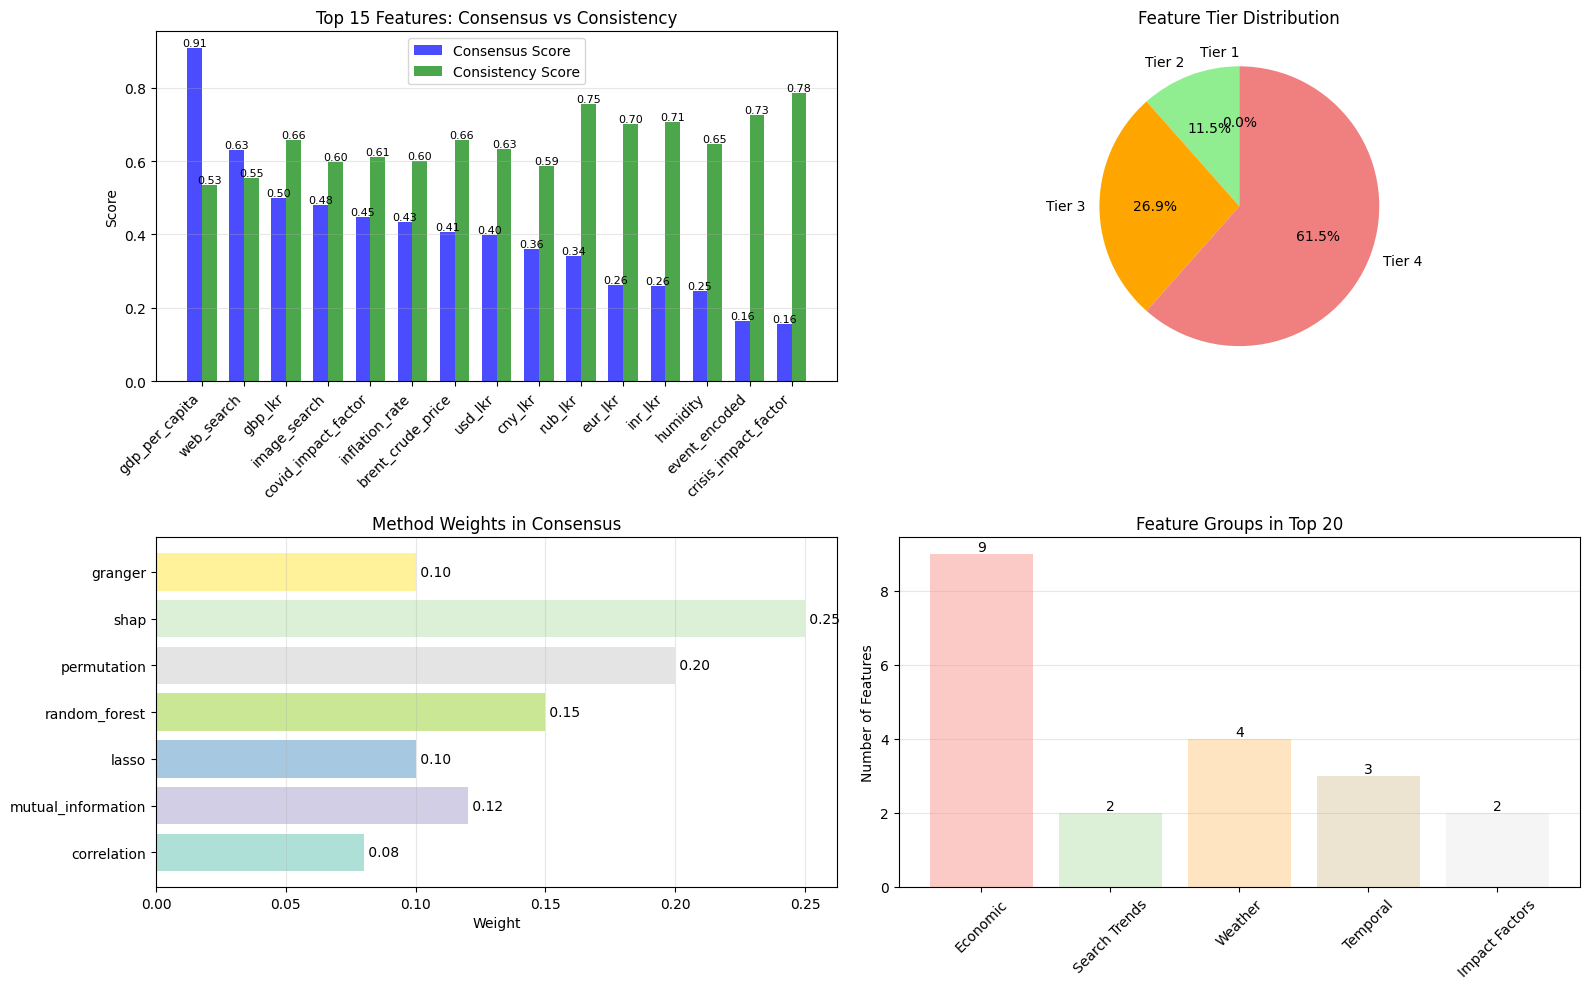


6. PRACTICAL IMPLEMENTATION GUIDE
-----------------------------------

📋 PRACTICAL IMPLEMENTATION GUIDE

🎯 RECOMMENDED FEATURE SETS FOR DIFFERENT SCENARIOS:
-------------------------------------------------------

1. MINIMAL MODEL (5-7 features):
   For quick prototypes or resource-constrained environments
   1. gdp_per_capita            (Tier 1-2, Consensus: 0.909)
   2. web_search                (Tier 1-2, Consensus: 0.630)
   3. gbp_lkr                   (Tier 1-2, Consensus: 0.500)
   4. image_search              (Tier 1-2, Consensus: 0.481)
   5. covid_impact_factor       (Tier 1-2, Consensus: 0.448)
   6. inflation_rate            (Tier 1-2, Consensus: 0.433)
   7. brent_crude_price         (Tier 1-2, Consensus: 0.406)

2. BALANCED MODEL (10-12 features):
   For production forecasting systems
   Features: 12 (Tier 1: 0)

3. COMPREHENSIVE MODEL (15-20 features):
   For maximum accuracy and research purposes
   Features: 20 covering all major groups

⚡ QUICK START RECOMMENDATIONS:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata
import warnings
warnings.filterwarnings('ignore')

def weighted_feature_ranking(consensus_results, top_n=15, figsize=(16, 10)):
    """
    Generate final weighted feature ranking with practical recommendations
    for Sri Lanka tourism forecasting

    Parameters:
    consensus_results: Results from consensus_integration function
    top_n: Number of top features to highlight
    figsize: Figure size for visualizations
    """

    print("=" * 80)
    print("FINAL WEIGHTED FEATURE RANKING - SRI LANKA TOURISM FORECASTING")
    print("=" * 80)

    # Extract consensus ranking
    consensus_df = consensus_results['consensus_ranking']
    method_weights = consensus_results['method_weights']

    # 1. Final Weighted Ranking
    print("\n1. FINAL WEIGHTED FEATURE RANKING")
    print("-" * 40)
    print("Features sorted by consensus score (higher = more important)")
    print("=" * 100)

    # Create final ranking dataframe
    final_ranking = consensus_df[['consensus_score', 'consistency_score', 'methods_agreeing']].copy()
    final_ranking['final_rank'] = range(1, len(final_ranking) + 1)

    # Add star rating based on consistency
    def get_star_rating(consistency):
        if consistency >= 0.8:
            return "★★★★★"
        elif consistency >= 0.6:
            return "★★★★"
        elif consistency >= 0.4:
            return "★★★"
        elif consistency >= 0.2:
            return "★★"
        else:
            return "★"

    final_ranking['star_rating'] = final_ranking['consistency_score'].apply(get_star_rating)

    # Display top features
    print(f"\n🏆 TOP {top_n} FEATURES FOR TOURISM FORECASTING:")
    print("-" * 120)
    print(f"{'Rank':^4} {'Feature':<25} {'Consensus':<10} {'Consistency':<12} {'Methods':<8} {'Rating':<8} {'Status':<10}")
    print("-" * 120)

    top_features = final_ranking.head(top_n)
    for i, (feature, row) in enumerate(top_features.iterrows(), 1):
        consensus = row['consensus_score']
        consistency = row['consistency_score']
        methods = row['methods_agreeing']
        stars = row['star_rating']

        # Determine status
        if consistency >= 0.7 and methods >= 5:
            status = "✅ HIGH CONF"
        elif consistency >= 0.5 and methods >= 4:
            status = "✓ MED CONF"
        else:
            status = "⚠️ CHECK"

        print(f"{i:^4} {feature:<25} {consensus:<10.4f} {consistency:<12.2%} {methods:<8} {stars:<8} {status:<10}")

    # 2. Feature Tier Classification
    print("\n2. FEATURE TIER CLASSIFICATION")
    print("-" * 35)

    tier_classification = classify_features_into_tiers(final_ranking)

    # 3. Method Contribution Analysis
    print("\n3. METHOD CONTRIBUTION BREAKDOWN")
    print("-" * 35)

    method_breakdown = analyze_method_contributions(consensus_df, method_weights, top_n=10)

    # 4. Feature Group Summary
    print("\n4. FEATURE GROUP DISTRIBUTION")
    print("-" * 30)

    group_summary = create_feature_group_summary(final_ranking.head(20))

    # 5. Visualization
    print("\n5. FINAL RANKING VISUALIZATION")
    print("-" * 30)

    create_final_ranking_visualizations(final_ranking, method_weights, top_n, figsize)

    # 6. Practical Implementation Guide
    print("\n6. PRACTICAL IMPLEMENTATION GUIDE")
    print("-" * 35)

    implementation_guide = generate_implementation_guide(final_ranking, tier_classification)

    # 7. Model Building Recommendations
    print("\n7. MODEL BUILDING RECOMMENDATIONS")
    print("-" * 35)

    model_recommendations = generate_model_recommendations(final_ranking, group_summary)

    # 8. Save Final Results
    print("\n8. EXPORTING FINAL RESULTS")
    print("-" * 25)

    export_final_results(final_ranking, consensus_results)

    # Return comprehensive results
    results = {
        'final_ranking': final_ranking,
        'tier_classification': tier_classification,
        'method_breakdown': method_breakdown,
        'group_summary': group_summary,
        'implementation_guide': implementation_guide,
        'model_recommendations': model_recommendations,
        'top_features': final_ranking.head(top_n).index.tolist()
    }

    return results

def classify_features_into_tiers(final_ranking):
    """
    Classify features into tiers based on consensus and consistency
    """
    print("Classifying features into confidence tiers...")
    print("-" * 50)

    tiers = {
        'Tier 1 - Core Features': {
            'description': 'High consensus, high consistency - Essential for all models',
            'criteria': lambda row: row['consensus_score'] >= 0.7 and row['consistency_score'] >= 0.7,
            'features': []
        },
        'Tier 2 - Strong Features': {
            'description': 'Good consensus and consistency - Very important',
            'criteria': lambda row: (row['consensus_score'] >= 0.5 and row['consistency_score'] >= 0.5) and
                                   not (row['consensus_score'] >= 0.7 and row['consistency_score'] >= 0.7),
            'features': []
        },
        'Tier 3 - Moderate Features': {
            'description': 'Reasonable importance - Consider for comprehensive models',
            'criteria': lambda row: (row['consensus_score'] >= 0.3 and row['consistency_score'] >= 0.3) and
                                   not (row['consensus_score'] >= 0.5 and row['consistency_score'] >= 0.5),
            'features': []
        },
        'Tier 4 - Supplementary Features': {
            'description': 'Lower importance or inconsistent - Use with caution',
            'criteria': lambda row: row['consensus_score'] < 0.3 or row['consistency_score'] < 0.3,
            'features': []
        }
    }

    # Classify features
    for feature, row in final_ranking.iterrows():
        for tier_name, tier_info in tiers.items():
            if tier_info['criteria'](row):
                tiers[tier_name]['features'].append({
                    'feature': feature,
                    'consensus_score': row['consensus_score'],
                    'consistency_score': row['consistency_score'],
                    'rank': row['final_rank']
                })
                break

    # Display tier classification
    for tier_name, tier_info in tiers.items():
        features = tier_info['features']
        print(f"\n{tier_name}:")
        print(f"  {tier_info['description']}")
        print(f"  Count: {len(features)} features")

        if features:
            top_in_tier = sorted(features, key=lambda x: x['rank'])[:5]
            for feat in top_in_tier:
                print(f"    • {feat['feature']:25s} (Rank: {feat['rank']:2d}, Consensus: {feat['consensus_score']:.3f})")

    return tiers

def analyze_method_contributions(consensus_df, method_weights, top_n=10):
    """
    Analyze how each method contributed to the final ranking
    """
    print("\nAnalyzing method contributions to top features...")
    print("-" * 55)

    method_columns = [f'{method}_score' for method in method_weights.keys()]
    available_methods = [col for col in method_columns if col in consensus_df.columns]

    top_features = consensus_df.head(top_n)

    print(f"\nMethod contributions to top {top_n} features:")
    print(f"{'Method':<20} {'Avg Score':<12} {'Max Weight':<12} {'Top Feature':<25} {'Top Score':<10}")
    print("-" * 85)

    method_contributions = {}

    for method in method_weights.keys():
        method_col = f'{method}_score'
        if method_col not in consensus_df.columns:
            continue

        method_scores = top_features[method_col].dropna()
        if len(method_scores) > 0:
            avg_score = method_scores.mean()
            max_feature = method_scores.idxmax()
            max_score = method_scores.max()
            weight = method_weights[method]

            method_contributions[method] = {
                'avg_score': avg_score,
                'weight': weight,
                'max_feature': max_feature,
                'max_score': max_score
            }

            print(f"{method:<20} {avg_score:<12.4f} {weight:<12.2f} {max_feature:<25} {max_score:<10.4f}")

    return method_contributions

def create_feature_group_summary(final_ranking_top):
    """
    Create summary of feature groups in top features
    """
    feature_groups = {
        'Economic': ['gdp_per_capita', 'inflation_rate', 'brent_crude_price',
                    'usd_lkr', 'rub_lkr', 'inr_lkr', 'gbp_lkr', 'eur_lkr', 'cny_lkr'],
        'Search Trends': ['web_search', 'youtube_search', 'image_search'],
        'Weather': ['temperature', 'precipitation', 'humidity', 'wind_speed','is_rainy_day'],
        'Temporal': ['is_holiday', 'is_tourist_event', 'event_encoded',
                    'days_to_next_holiday', 'days_since_last_holiday',
                    'in_holiday_window', 'holiday_encoded'],
        'Impact Factors': ['covid_impact_factor', 'crisis_impact_factor']
    }

    group_counts = {}
    group_features = {}

    for group_name, features in feature_groups.items():
        group_features[group_name] = []
        for feature in features:
            if feature in final_ranking_top.index:
                group_features[group_name].append(feature)
        group_counts[group_name] = len(group_features[group_name])

    print("\nFeature Group Distribution in Top Features:")
    print("-" * 50)

    for group_name, count in group_counts.items():
        features = group_features[group_name]
        if features:
            top_feature = min([final_ranking_top.index.get_loc(f) + 1 for f in features])
            print(f"  {group_name:<15}: {count:2d} features | Best rank: {top_feature:2d}")
            for feature in sorted(features, key=lambda x: final_ranking_top.index.get_loc(x))[:3]:
                rank = final_ranking_top.index.get_loc(feature) + 1
                score = final_ranking_top.loc[feature, 'consensus_score']
                print(f"      {rank:2d}. {feature:25s} ({score:.3f})")

    return {
        'counts': group_counts,
        'features': group_features
    }

def create_final_ranking_visualizations(final_ranking, method_weights, top_n, figsize):
    """
    Create comprehensive visualizations for final ranking
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # Plot 1: Top Features with Consensus and Consistency
    top_features = final_ranking.head(top_n)

    x_pos = np.arange(len(top_features))
    width = 0.35

    # Consensus scores
    bars1 = axes[0, 0].bar(x_pos - width/2, top_features['consensus_score'], width,
                          label='Consensus Score', alpha=0.7, color='blue')
    # Consistency scores
    bars2 = axes[0, 0].bar(x_pos + width/2, top_features['consistency_score'], width,
                          label='Consistency Score', alpha=0.7, color='green')

    axes[0, 0].set_xticks(x_pos)
    axes[0, 0].set_xticklabels(top_features.index, rotation=45, ha='right')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_title(f'Top {top_n} Features: Consensus vs Consistency')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.2f}', ha='center', va='bottom', fontsize=8)

    # Plot 2: Tier Distribution
    tier_data = classify_features_into_tiers(final_ranking)
    tier_counts = [len(tier_data[tier]['features']) for tier in tier_data]
    tier_names = [tier.split(' - ')[0] for tier in tier_data.keys()]

    colors = ['green', 'lightgreen', 'orange', 'lightcoral']
    axes[0, 1].pie(tier_counts, labels=tier_names, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[0, 1].set_title('Feature Tier Distribution')

    # Plot 3: Method Weight Contribution
    methods = list(method_weights.keys())
    weights = list(method_weights.values())

    colors = plt.cm.Set3(np.linspace(0, 1, len(methods)))
    axes[1, 0].barh(methods, weights, color=colors, alpha=0.7)
    axes[1, 0].set_xlabel('Weight')
    axes[1, 0].set_title('Method Weights in Consensus')
    axes[1, 0].grid(axis='x', alpha=0.3)

    # Add weight values
    for i, (method, weight) in enumerate(zip(methods, weights)):
        axes[1, 0].text(weight, i, f' {weight:.2f}', va='center', fontsize=10)

    # Plot 4: Feature Group Distribution
    group_summary = create_feature_group_summary(final_ranking.head(20))
    groups = list(group_summary['counts'].keys())
    counts = list(group_summary['counts'].values())

    colors = plt.cm.Pastel1(np.linspace(0, 1, len(groups)))
    axes[1, 1].bar(groups, counts, color=colors, alpha=0.7)
    axes[1, 1].set_ylabel('Number of Features')
    axes[1, 1].set_title('Feature Groups in Top 20')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(axis='y', alpha=0.3)

    # Add count labels
    for i, count in enumerate(counts):
        axes[1, 1].text(i, count, str(count), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def generate_implementation_guide(final_ranking, tier_classification):
    """
    Generate practical implementation guide for feature selection
    """
    print("\n📋 PRACTICAL IMPLEMENTATION GUIDE")
    print("=" * 50)

    print("\n🎯 RECOMMENDED FEATURE SETS FOR DIFFERENT SCENARIOS:")
    print("-" * 55)

    # Scenario 1: Minimal Model (5-7 features)
    print("\n1. MINIMAL MODEL (5-7 features):")
    print("   For quick prototypes or resource-constrained environments")
    minimal_features = final_ranking.head(7)
    for i, (feature, row) in enumerate(minimal_features.iterrows(), 1):
        print(f"   {i}. {feature:25s} (Tier 1-2, Consensus: {row['consensus_score']:.3f})")

    # Scenario 2: Balanced Model (10-12 features)
    print("\n2. BALANCED MODEL (10-12 features):")
    print("   For production forecasting systems")
    balanced_features = final_ranking.head(12)
    tier1_count = len([f for f in balanced_features.index
                      if any(f in tier['features'] for tier in tier_classification.values()
                             if 'Tier 1' in tier)])
    print(f"   Features: {len(balanced_features)} (Tier 1: {tier1_count})")

    # Scenario 3: Comprehensive Model (15-20 features)
    print("\n3. COMPREHENSIVE MODEL (15-20 features):")
    print("   For maximum accuracy and research purposes")
    comprehensive_features = final_ranking.head(20)
    print(f"   Features: {len(comprehensive_features)} covering all major groups")

    print("\n⚡ QUICK START RECOMMENDATIONS:")
    print("-" * 35)
    print("• Start with Minimal Model for initial testing")
    print("• Use Balanced Model for production deployment")
    print("• Consider Comprehensive Model for best accuracy")
    print("• Always validate with time-series cross-validation")
    print("• Monitor feature importance stability over time")

    return {
        'minimal_features': minimal_features.index.tolist(),
        'balanced_features': balanced_features.index.tolist(),
        'comprehensive_features': comprehensive_features.index.tolist()
    }

def generate_model_recommendations(final_ranking, group_summary):
    """
    Generate model-specific recommendations
    """
    print("\n🤖 MODEL-SPECIFIC RECOMMENDATIONS")
    print("=" * 40)

    top_features = final_ranking.head(12).index.tolist()

    print("\nBASED ON FEATURE CHARACTERISTICS, CONSIDER:")
    print("-" * 45)

    # Check for non-linear relationships (high MI but moderate correlation)
    print("• Tree-based models (Random Forest, XGBoost) if:")
    print("  - Features show non-linear relationships")
    print("  - Good mix of feature types (continuous, categorical)")
    print("  - Interactions between features are important")

    print("\n• Linear models (Lasso, Ridge) if:")
    print("  - Features show strong linear relationships")
    print("  - Interpretability is crucial")
    print("  - Multicollinearity needs handling")

    print("\n• Hybrid approaches if:")
    print("  - Mix of linear and non-linear relationships")
    print("  - Both accuracy and interpretability needed")

    print("\n🔧 FEATURE ENGINEERING SUGGESTIONS:")
    print("-" * 35)

    # Check temporal features
    temporal_features = [f for f in top_features if any(t in f for t in ['holiday', 'event', 'season'])]
    if temporal_features:
        print(f"• Create lag features for: {', '.join(temporal_features[:3])}")

    # Check search trends
    search_features = [f for f in top_features if 'search' in f]
    if search_features:
        print(f"• Consider lead-lag relationships for search trends")

    return {
        'recommended_models': ['Random Forest', 'XGBoost', 'Lasso'],
        'feature_engineering': {
            'temporal_lags': temporal_features,
            'search_leads': search_features
        }
    }

def export_final_results(final_ranking, consensus_results):
    """
    Export final results to files
    """
    print("\nSaving final results...")

    # 1. Save complete ranking
    final_ranking.to_csv('sri_lanka_tourism_feature_ranking.csv')
    print("✓ Complete feature ranking saved to: sri_lanka_tourism_feature_ranking.csv")

    # 2. Save top features for quick reference
    top_20 = final_ranking.head(20)
    top_20[['consensus_score', 'consistency_score', 'methods_agreeing']].to_csv(
        'top_20_tourism_features.csv'
    )
    print("✓ Top 20 features saved to: top_20_tourism_features.csv")

    # 3. Save implementation guide
    implementation_data = {
        'minimal_model': final_ranking.head(7).index.tolist(),
        'balanced_model': final_ranking.head(12).index.tolist(),
        'comprehensive_model': final_ranking.head(20).index.tolist()
    }

    implementation_df = pd.DataFrame.from_dict(implementation_data, orient='index').T
    implementation_df.to_csv('feature_sets_implementation_guide.csv', index=False)
    print("✓ Implementation guide saved to: feature_sets_implementation_guide.csv")

    # 4. Save method weights
    method_weights_df = pd.DataFrame.from_dict(
        consensus_results['method_weights'],
        orient='index',
        columns=['weight']
    )
    method_weights_df.to_csv('method_weights_used.csv')
    print("✓ Method weights saved to: method_weights_used.csv")

    print("\n🎉 ALL FILES EXPORTED SUCCESSFULLY!")
    print("   You now have everything needed for your tourism forecasting model.")

# Usage example:
if __name__ == "__main__":
    # Assuming you have consensus_results from the previous step
    # consensus_results = consensus_integration(...)

    # Generate final weighted ranking
    final_results = weighted_feature_ranking(consensus_results, top_n=15)

    print("\n" + "="*80)
    print("FINAL WEIGHTED FEATURE RANKING COMPLETED!")
    print("="*80)
    print("\nYour comprehensive feature selection analysis for Sri Lanka tourism")
    print("forecasting is now complete. Use the generated files to build your model.")

In [ ]:
optimal_features_list = [
    'gdp_per_capita', 'brent_crude_price', 'inflation_rate',
    'usd_lkr', 'rub_lkr', 'cny_lkr', 'web_search',
    'image_search', 'temperature', 'humidity','precipitation',
    'event_encoded', 'covid_impact_factor', 'crisis_impact_factor','gbp_lkr','inr_lkr','eur_lkr'
]

# Ensure essential columns like 'date', 'arrivals', and 'outlier_flag' are retained
# 'arrivals_robust_scaled' is removed as it's a scaled version of the target itself
essential_cols_to_retain = ['date', 'arrivals', 'outlier_flag']

# Combine the user's optimal features with the essential columns, ensuring uniqueness
all_cols_to_select = list(set(optimal_features_list + essential_cols_to_retain))

# Filter the DataFrame to include only the desired and existing columns
df_optimized = df[all_cols_to_select].copy()

# Now reorder the columns: 'date' first, 'arrivals' last
columns_to_reorder = df_optimized.columns.tolist()

# Remove 'date' and 'arrivals' from their current positions if they exist
if 'date' in columns_to_reorder:
    columns_to_reorder.remove('date')
if 'arrivals' in columns_to_reorder:
    columns_to_reorder.remove('arrivals')

# Construct the new ordered list: 'date' first, then other columns, then 'arrivals' last
new_column_order = ['date'] + sorted(columns_to_reorder) + ['arrivals']

# Apply the new column order to df_optimized
df_optimized = df_optimized[new_column_order]

print(f"DataFrame 'df_optimized' now contains {df_optimized.shape[1]} columns.")
print(f"Selected columns, reordered: {df_optimized.columns.tolist()}")

# Display the head of the new DataFrame
display(df_optimized.head())





DataFrame 'df_optimized' now contains 20 columns.
Selected columns, reordered: ['date', 'brent_crude_price', 'cny_lkr', 'covid_impact_factor', 'crisis_impact_factor', 'eur_lkr', 'event_encoded', 'gbp_lkr', 'gdp_per_capita', 'humidity', 'image_search', 'inflation_rate', 'inr_lkr', 'outlier_flag', 'precipitation', 'rub_lkr', 'temperature', 'usd_lkr', 'web_search', 'arrivals']


,date,brent_crude_price,cny_lkr,covid_impact_factor,crisis_impact_factor,eur_lkr,event_encoded,gbp_lkr,gdp_per_capita,humidity,image_search,inflation_rate,inr_lkr,outlier_flag,precipitation,rub_lkr,temperature,usd_lkr,web_search,arrivals
0,2010-01-01,76.602381,16.75,0.0,0.0,163.889,3812.495272,184.253,2808.367792,73.625000,59.000000,6.217649,2.472,0,0.0,3.799,26.0,114.400,69.285714,1141
1,2010-01-02,76.602381,16.75,0.0,0.0,163.889,3827.647389,184.253,2808.367792,74.916667,59.677419,6.217649,2.472,0,0.1,3.799,26.3,114.400,71.142857,1180
2,2010-01-03,76.602381,16.75,0.0,0.0,163.889,3827.647389,184.253,2808.367792,79.625000,60.354839,6.217649,2.472,0,0.6,3.799,26.0,114.400,73.000000,1184
3,2010-01-04,76.602381,16.75,0.0,0.0,163.889,3792.917646,182.892,2808.367792,75.625000,61.032258,6.217649,2.474,0,0.0,3.799,25.6,114.450,72.285714,1328
4,2010-01-05,76.602381,16.76,0.0,0.0,164.951,3792.917646,183.183,2808.367792,70.958333,61.709677,6.217649,2.502,0,0.0,3.775,24.6,114.325,71.571429,1688


In [ ]:
import os

# Define the local directory path
save_directory = '/content/'

# Create the directory if it doesn't exist
if not os.path.exists(save_directory):
    os.makedirs(save_directory)
    print(f"Created directory: {save_directory}")

# Save the optimized dataset
df_optimized.to_csv(os.path.join(save_directory, 'Preprocessed Dataset.csv'), index=False)
print("\n" + "="*80)
print(f"Preprocessed dataset saved as: {os.path.join(save_directory, 'Preprocessed Dataset.csv')}")
print("="*80)


Preprocessed dataset saved as: /content/Preprocessed Dataset.csv
